# Visualization gallery

Synthetic tables only — no `.h5ad`. Scores are planted so the plots are
legible; they are not biology.

`comet_plot`, `volcano_plot`, enrichment dots / bars / UpSet / Venn /
network map, `gseaplot`, group comparisons (`compare_de_across_groups`,
`de_summary_barplot`, `group_stat_plot`, `composition_barplot`), `ax=`
composition, export helpers (including the vector-friendly toggle).

Color: `scat.pl.palette` / `get_cmap`, plus per-plot `cmap=`, `fills=` /
`colors=`, and UpSet `set_color` / `intersection_color` / `dot_color`.

Real-data plots: {doc}`t_gse226488_partition_mechanism`,
{doc}`t_gse96583_standalone_de_enrichment`. Kwargs:
{doc}`../user_guide/plotting`.

In [1]:
%matplotlib inline
# Crisp inline figures (2× pixel density on HiDPI; pairs well with dpi=150)
%config InlineBackend.figure_format = "retina"

## 0. Setup

**Style API** (cnsplots-inspired journal look):

| Helper | Role |
|--------|------|
| `scat.pl.set_style` | Global rc: fine black spines, compact ticks, PDF/SVG editable text |
| `scat.pl.style_context` | Temporary style block (restores rcParams on exit) |
| `scat.pl.palette` / `list_palettes` | Qualitative sets: `nature`, `cell`, `science`, `okabe_ito`, … |
| `scat.pl.get_cmap` | Continuous maps: `scat_BuRd`, `scat_YlGnBu`, … |
| `scat.pl.setup_ax` | Polish axes; **default spines flush** (no lower-left gap) |
| `scat.pl.add_panel_label` | Bold multipanel letters (A, B, C, …) |

Pass `palette_name=` to `set_style` (e.g. `"nature"`) for a journal color cycle.
Spines sit **flush** with the data box by default. For a floating-axis gap,
call `setup_ax(ax, outward=4)` after plotting.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import scatrans as scat

print(f"scATrans {scat.__version__}")
print("palettes:", ", ".join(scat.pl.list_palettes()[:10]), "…")

# Journal-first defaults (Nature-inspired cycle + fine spines / compact ticks)
# Inspired by cnsplots (https://github.com/faridrashidi/cnsplots) aesthetics.
scat.pl.set_style(
    palette_name="nature",
    labelsize=9,
    titlesize=10,
    ticksize=8,
    legendsize=8,
    linewidth=0.5,
    dpi_preview=150,
)

# Optional gallery knobs (package defaults already modest)
FS = {"label_fontsize": 7}  # slightly tighter gene labels in multipanels
FIG = {}  # rely on package notebook defaults (dpi=150, modest figsize)
VOLC = {
    "top_n": 5,
    "s": 10,  # fixed small points for dense cloud
    "alpha": 0.55,
    "logfc_cutoff": 0.35,
    "pval_cutoff": 0.05,
    "legend_position": "UR",
}
np.random.seed(7)

scATrans 0.10.16
palettes: cell, default, ecotyper1, jama, jco, lancet, mechanism, nature, nejm, okabe_ito …


## Color system

Qualitative sets (`palette`) and continuous maps (`get_cmap`). Pass the
hex list into `fills=` / `colors=` / `set_color=`, or the cmap name into
`cmap=`. Named accents: `scat.pl.RED`, `BLUE`, `TEAL`, `ORANGE`.


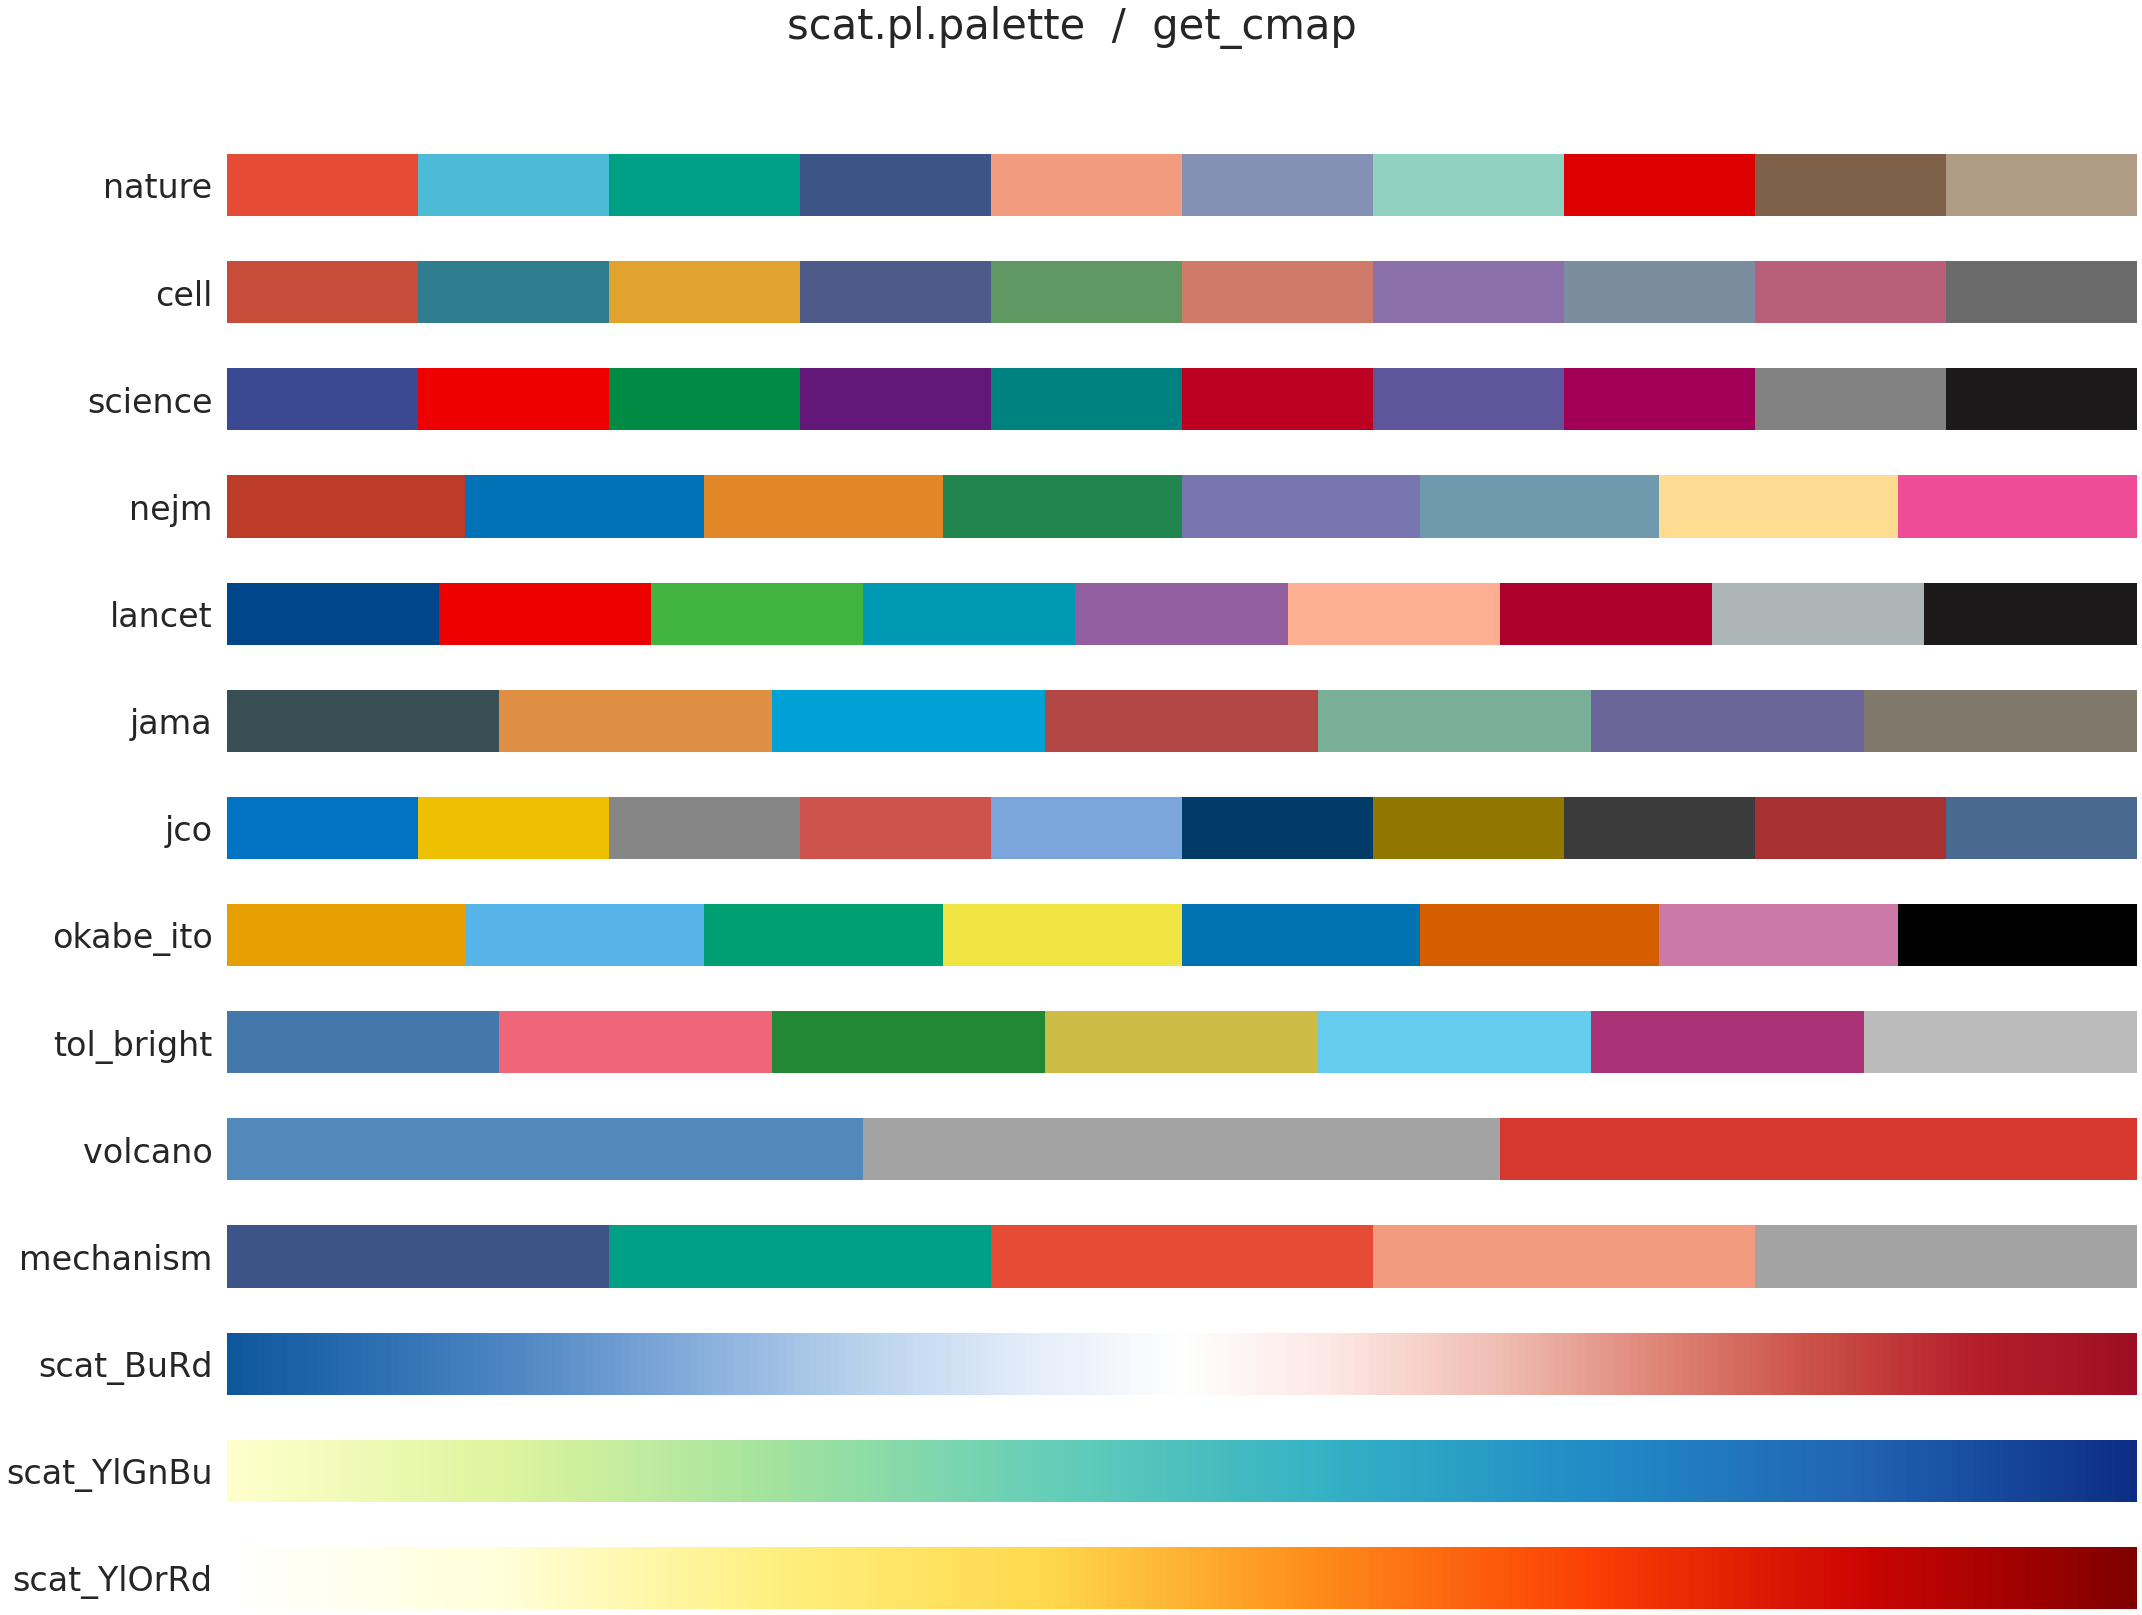

accents: RED #D6372E BLUE #5189BB TEAL #00A087 ORANGE #F08F35


In [3]:
from matplotlib.colors import ListedColormap

qual = [
    "nature",
    "cell",
    "science",
    "nejm",
    "lancet",
    "jama",
    "jco",
    "okabe_ito",
    "tol_bright",
    "volcano",
    "mechanism",
]
cmaps = ["scat_BuRd", "scat_YlGnBu", "scat_YlOrRd"]
nrows = len(qual) + len(cmaps)
fig, axes = plt.subplots(nrows, 1, figsize=(7.4, 0.36 * nrows + 0.4), dpi=150)
for ax, name in zip(axes[: len(qual)], qual):
    cols = scat.pl.palette(name)
    ax.imshow([list(range(len(cols)))], aspect="auto", cmap=ListedColormap(cols))
    ax.set_yticks([0])
    ax.set_yticklabels([name], fontsize=8)
    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
for ax, name in zip(axes[len(qual) :], cmaps):
    ax.imshow([np.linspace(0, 1, 256)], aspect="auto", cmap=scat.pl.get_cmap(name))
    ax.set_yticks([0])
    ax.set_yticklabels([name], fontsize=8)
    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle("scat.pl.palette  /  get_cmap", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()
print(
    "accents:",
    f"RED {scat.pl.RED}",
    f"BLUE {scat.pl.BLUE}",
    f"TEAL {scat.pl.TEAL}",
    f"ORANGE {scat.pl.ORANGE}",
)

### Dense two-sided synthetic data

~**1500 genes × 300 cells** with:

- continuous expression noise (fills the volcano cloud)  
- planted **up** and **down** blocks (two-sided DE)  
- planted **unspliced excess** in Disease  
- gene length / intron for bias plots  

Volcano / comet / rank always take the **full** `all_results` table.


In [4]:
n_genes, n_cells = 1500, 300
n_per = n_cells // 2
genes = [f"G{i:04d}" for i in range(n_genes)]

# Base NB counts + light structure so background genes scatter naturally
X = np.random.negative_binomial(6, 0.42, size=(n_cells, n_genes)).astype(float)
# mild random group shifts on many genes → dense two-sided cloud
shift = np.random.normal(0, 0.12, size=n_genes)  # mild background → NS cloud + DE wings
X[:n_per] *= np.clip(1.0 + shift, 0.7, 1.4)
X[n_per:] *= np.clip(1.0 - 0.3 * shift, 0.7, 1.4)

# Strong Disease UP (0..39)
for j in range(40):
    X[:n_per, j] = X[:n_per, j] * 2.8 + 12.0
# Strong Disease DOWN (40..79)
for j in range(40, 80):
    X[n_per:, j] = X[n_per:, j] * 2.8 + 12.0

S = X.copy()
U = np.maximum(
    X * np.random.uniform(0.35, 0.55, size=(1, n_genes))
    + np.random.negative_binomial(2, 0.55, size=X.shape),
    0,
).astype(float)
# Nascent excess in Disease for genes 20..90
for j in range(20, 90):
    U[:n_per, j] = U[:n_per, j] * 2.0 + 5.0

adata = sc.AnnData(X)
adata.obs_names = [f"c{i}" for i in range(n_cells)]
adata.var_names = genes
adata.obs["condition"] = ["Disease"] * n_per + ["Control"] * n_per
adata.obs["sample"] = [f"D{i // (n_per // 4)}" for i in range(n_per)] + [
    f"C{i // (n_per // 4)}" for i in range(n_per)
]
adata.layers["spliced"] = S
adata.layers["unspliced"] = U
adata.var["gene_length"] = np.random.randint(700, 7000, n_genes).astype(float)
adata.var["intron_number"] = np.random.randint(0, 16, n_genes).astype(float)
adata.var.loc[genes[:50], "gene_length"] = np.linspace(400, 10000, 50)

print(adata)
print("unspliced global:", round(float(scat.qc.unspliced_global(adata)), 4))

AnnData object with n_obs × n_vars = 300 × 1500
    obs: 'condition', 'sample'
    var: 'gene_length', 'intron_number'
    layers: 'spliced', 'unspliced'
unspliced global: 0.4004


### Score → full `all_results`

Do **not** pre-filter to “up genes” before volcano/comet. Filtering is for
candidate lists / enrichment only.

`use_permutation=True` fills `unspliced_excess_fdr` (Phipson–Smyth).
`n_perm=20` is tutorial speed (floor p ≈ 1/21). Use 200–500 in a paper.


In [5]:
# Residual FDR on; n_perm=20 is tutorial speed (floor p ≈ 1/21).
# Bias/gamma columns need EB gamma + features.
adata_res, significant, all_results = scat.active_score(
    adata,
    groupby="condition",
    target_group="Disease",
    reference_group="Control",
    mode="heuristic",
    use_permutation=True,
    n_perm=20,
    show_plot=False,
    min_total_counts=10,
    show_effective_gamma=True,
    gamma_method="empirical_bayes",
    copy_input=True,
)

n = len(all_results)
n_up = int(((all_results["logFC"] > 0.35) & (all_results["p_adj"] < 0.05)).sum())
n_down = int(((all_results["logFC"] < -0.35) & (all_results["p_adj"] < 0.05)).sum())
n_fdr = (
    int((all_results["unspliced_excess_fdr"] < 0.05).sum())
    if "unspliced_excess_fdr" in all_results.columns
    else 0
)
print(f"all_results: {n} genes | DE-like up={n_up} down={n_down}")
print(f"unspliced_excess_fdr<0.05: {n_fdr} | built-in significant: {len(significant)}")
print(f"logFC range: {all_results['logFC'].min():.2f} … {all_results['logFC'].max():.2f}")
top_genes = all_results.sort_values("active_score", ascending=False).head(6).index.tolist()
all_results.sort_values("active_score", ascending=False).head(5)

all_results: 1500 genes | DE-like up=112 down=153
unspliced_excess_fdr<0.05: 0 | built-in significant: 21
logFC range: -2.72 … 2.52


,active_score,unspliced_excess_delta,unspliced_excess_residual,logFC,p_val,p_adj,total_us_counts,total_us_counts_raw,total_us_counts_velocity_layer,valid_expr,...,intron_number,effective_gamma,active_score_pval,active_score_fdr,unspliced_excess_pval,unspliced_excess_fdr,gamma_shrinkage_weight,velocity_source,velocity_delta_raw,velocity_residual
G0036,99.998580,19.755627,19.657212,2.515978,1.392836e-89,1.044627e-87,15666.640125,15666.640125,15399.986975,True,...,7.0,0.707826,0.047619,0.127779,0.047619,0.338524,0.835516,heuristic_global_ratio,19.755627,19.657212
G0039,99.997832,18.059329,17.954946,2.410089,6.648860e-95,1.424756e-92,15409.064926,15409.064926,15149.069471,True,...,3.0,0.646524,0.047619,0.127779,0.047619,0.338524,0.836908,heuristic_global_ratio,18.059329,17.954946
G0033,99.997546,17.836755,17.745005,2.379153,1.774631e-92,2.218289e-90,13963.582106,13963.582106,13734.320870,True,...,14.0,0.665111,0.047619,0.127779,0.047619,0.338524,0.826400,heuristic_global_ratio,17.836755,17.745005
G0031,99.996954,18.910138,18.826158,2.325093,2.029660e-84,9.514029e-83,14268.967036,14268.967036,14032.452908,True,...,3.0,0.633912,0.047619,0.127779,0.047619,0.338524,0.831720,heuristic_global_ratio,18.910138,18.826158
G0024,99.996429,13.297049,13.233919,2.285381,1.771954e-80,5.424348e-79,12040.081006,12040.081006,11850.351781,True,...,9.0,0.556451,0.047619,0.127779,0.047619,0.338524,0.810168,heuristic_global_ratio,13.297049,13.233919


## 1. Active drivers (comet)

**What it answers:** logFC × unspliced-excess residual, sized by `active_score`.

**Function**: `scat.pl.comet_plot` — full `all_results`  
Key kwargs: `top_n`, `s` / `point_scale`, `label_fontsize`, `positive_logfc_only`
(default True keeps classic “drivers” view).

Default continuous map is **`scat_BuRd`**. Override with `cmap=`
(`"coolwarm"`, `"scat_BuRd_r"`, …). Soft point edges keep dense clouds clean.


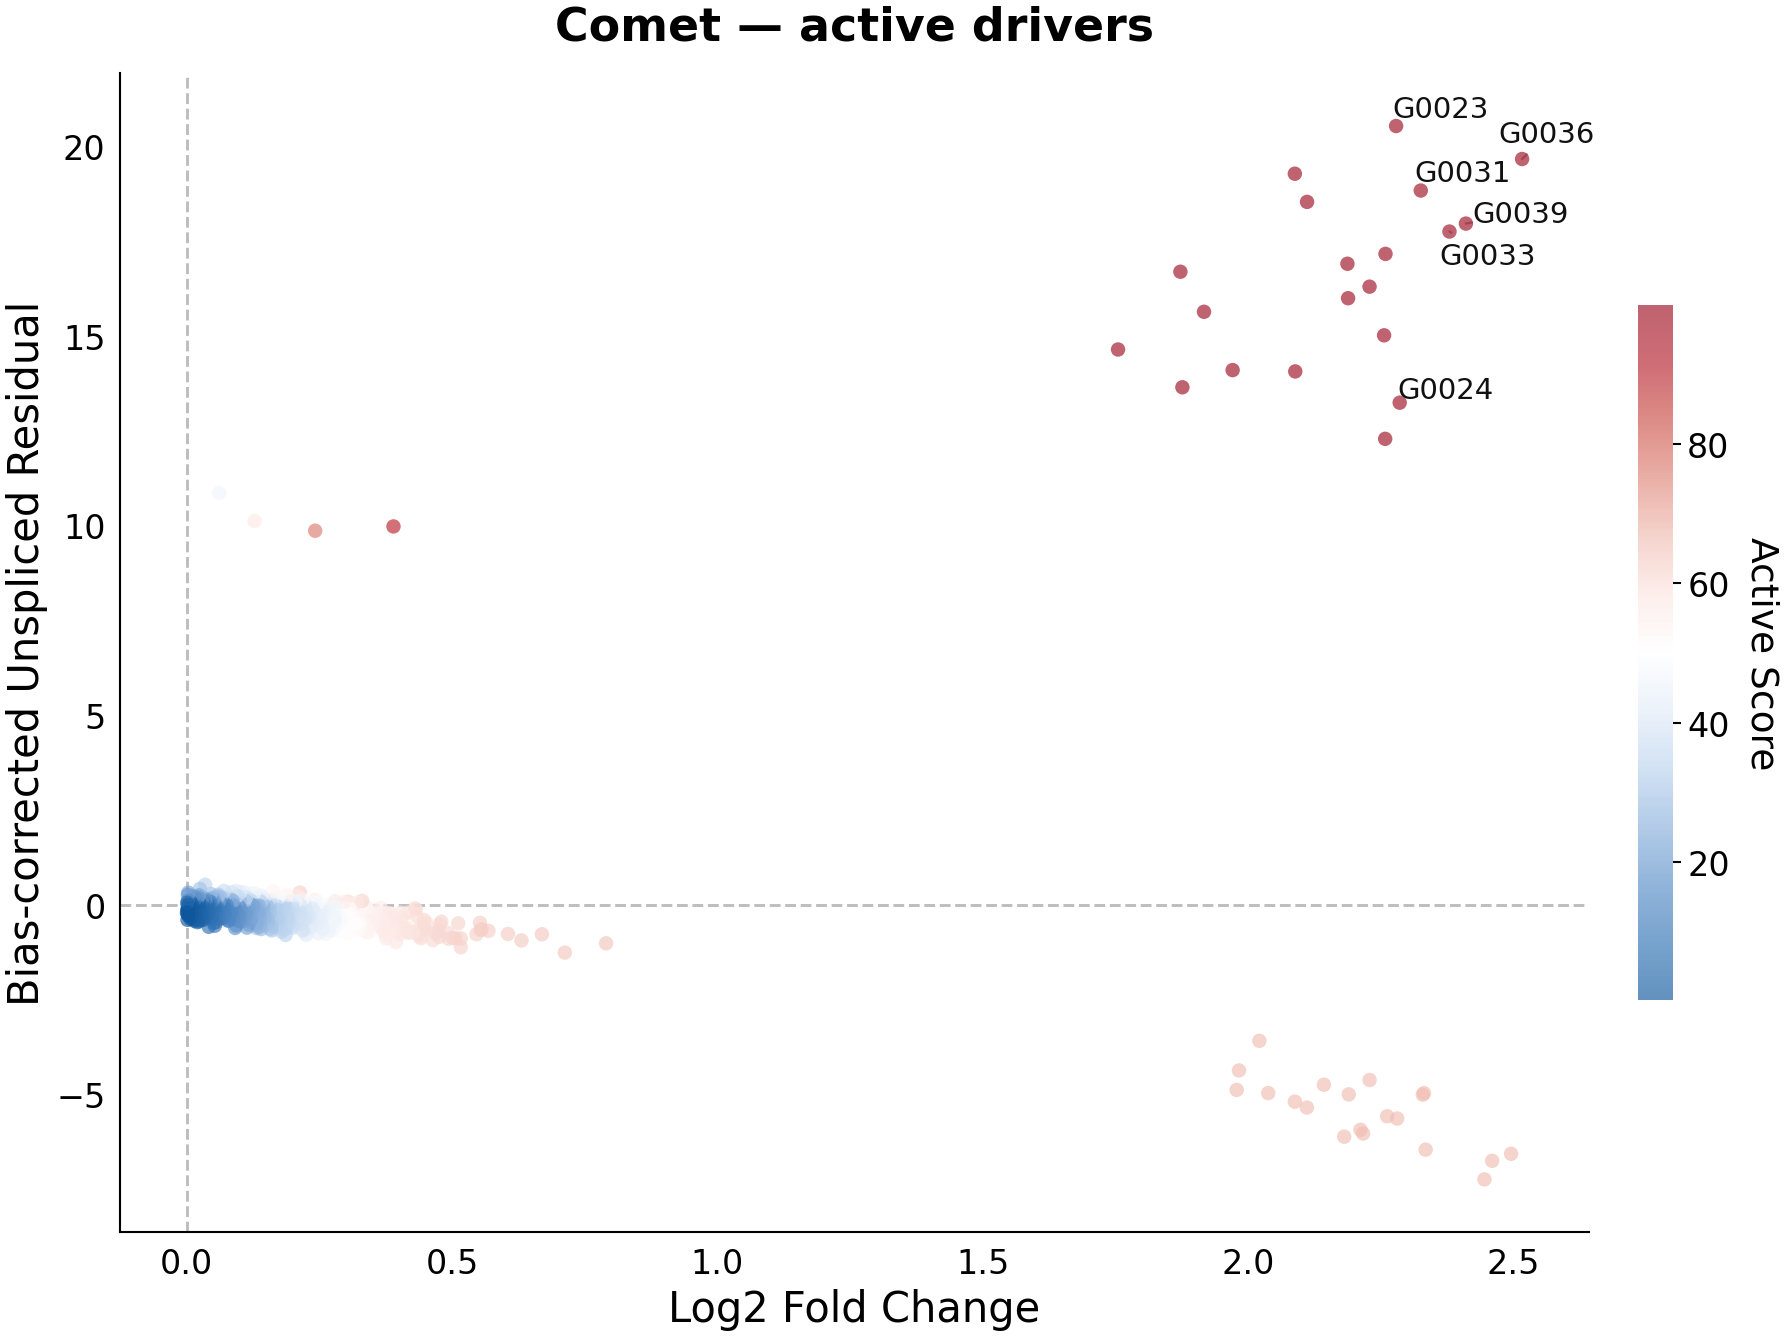

In [6]:
scat.pl.comet_plot(
    all_results,
    top_n=6,
    title="Comet — active drivers",
    s=12,
    alpha=0.65,
    **FS,
    **FIG,
    show=True,
);

**Variant — size and `cmap=`** (few labels).


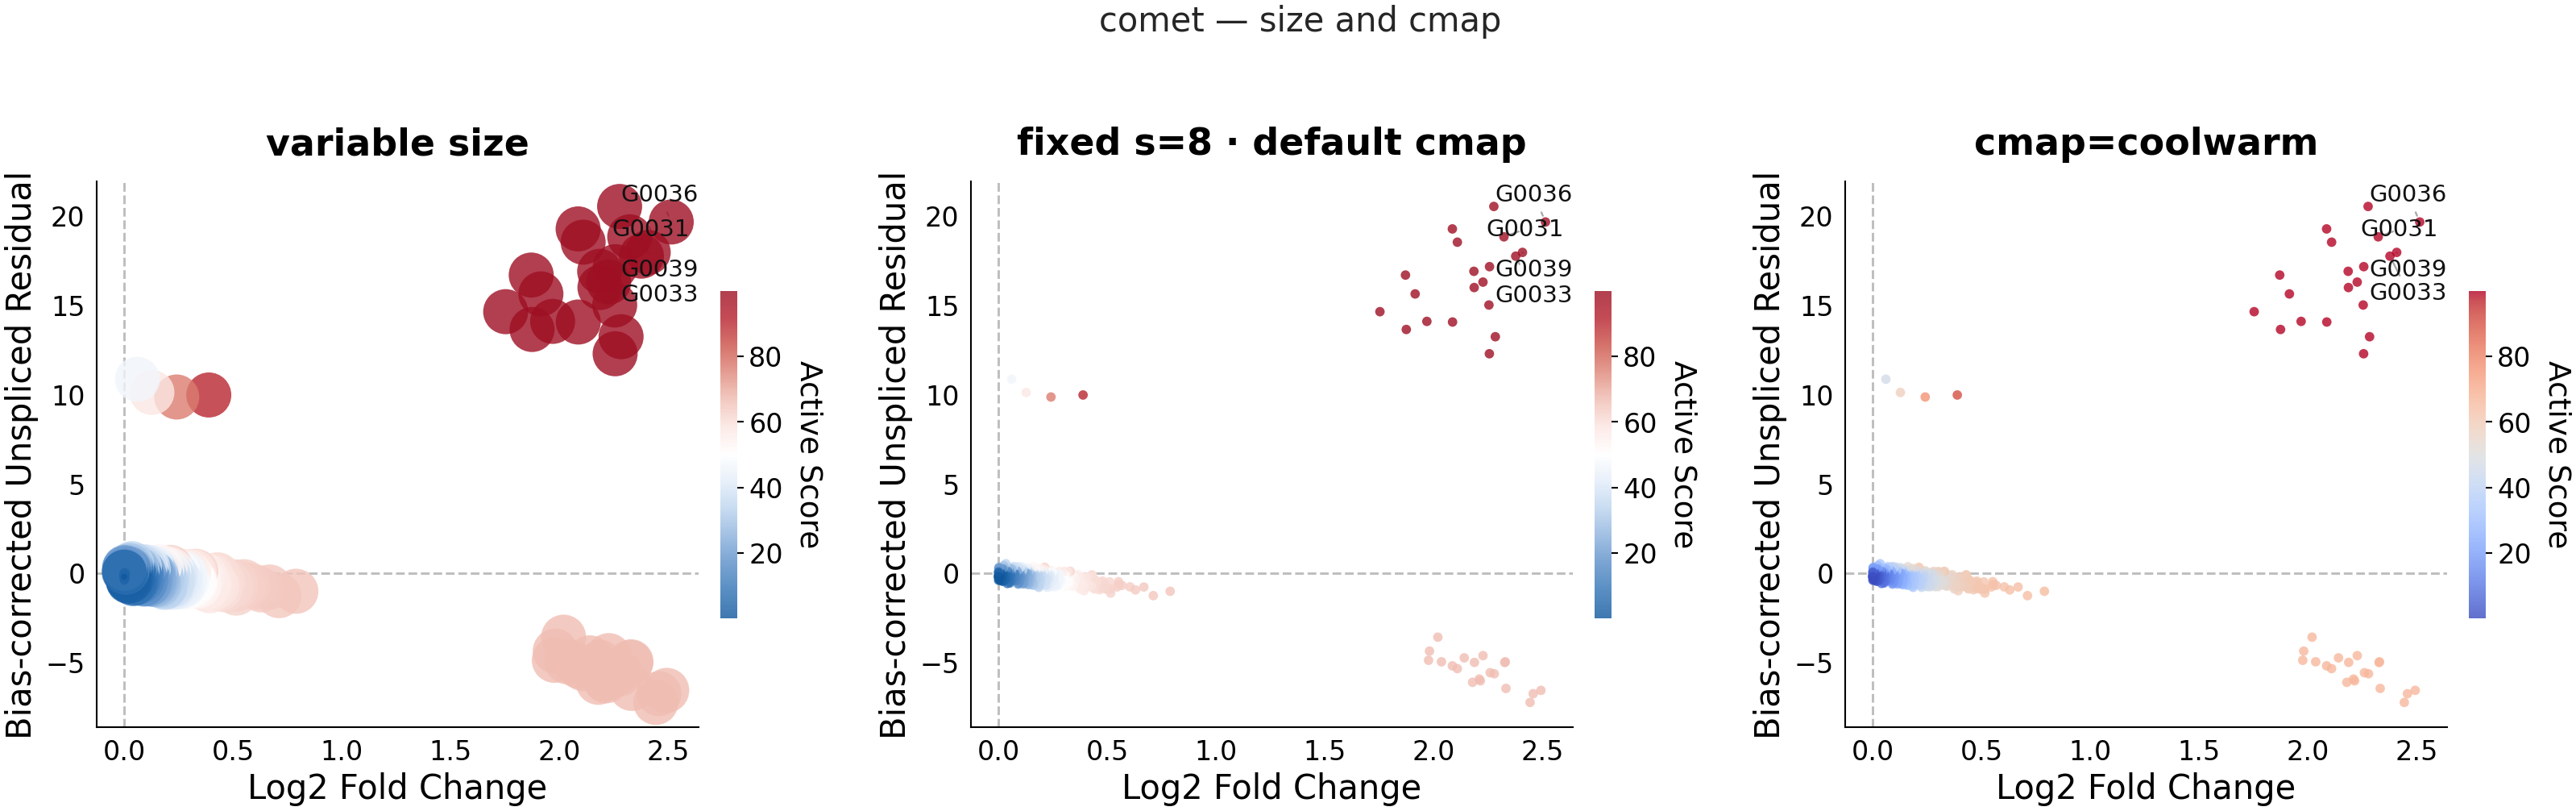

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.4), dpi=150)
scat.pl.comet_plot(
    all_results,
    top_n=4,
    point_scale=0.8,
    title="variable size",
    ax=axes[0],
    show=False,
    **FS,
)
scat.pl.comet_plot(
    all_results,
    top_n=4,
    s=8,
    title="fixed s=8 · default cmap",
    ax=axes[1],
    show=False,
    **FS,
)
scat.pl.comet_plot(
    all_results,
    top_n=4,
    s=8,
    cmap="coolwarm",
    title="cmap=coolwarm",
    ax=axes[2],
    show=False,
    **FS,
)
fig.suptitle("comet — size and cmap", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

## 2. Volcano on full `all_results` (two-sided, dense)

**What it answers:** Classical logFC vs −log10(padj) for **all** genes.

**Function**: `scat.pl.volcano_plot`

| Kwarg | Role |
|-------|------|
| `style` | `"ggvolcano"` (teal/orange two-sided), `"auto"`, `"gradual"` |
| `s`, `alpha` | Fixed small points + transparency for dense clouds |
| `cmap` | Continuous color when `style="auto"` (default `scat_BuRd`) |
| `top_n`, `label_fontsize` | Keep labels few and small |
| `legend_position` | `"UL"` / `"UR"` / `"DL"` / `"DR"` (ggvolcano) |
| `context` | `"notebook"` / `"paper"` / `"cns"` size/font packs |

:::{tip}
`style="auto"` colors by residual / score columns when present — down genes
can look muted. Use **`ggvolcano`** for a clear two-sided publication look.
:::


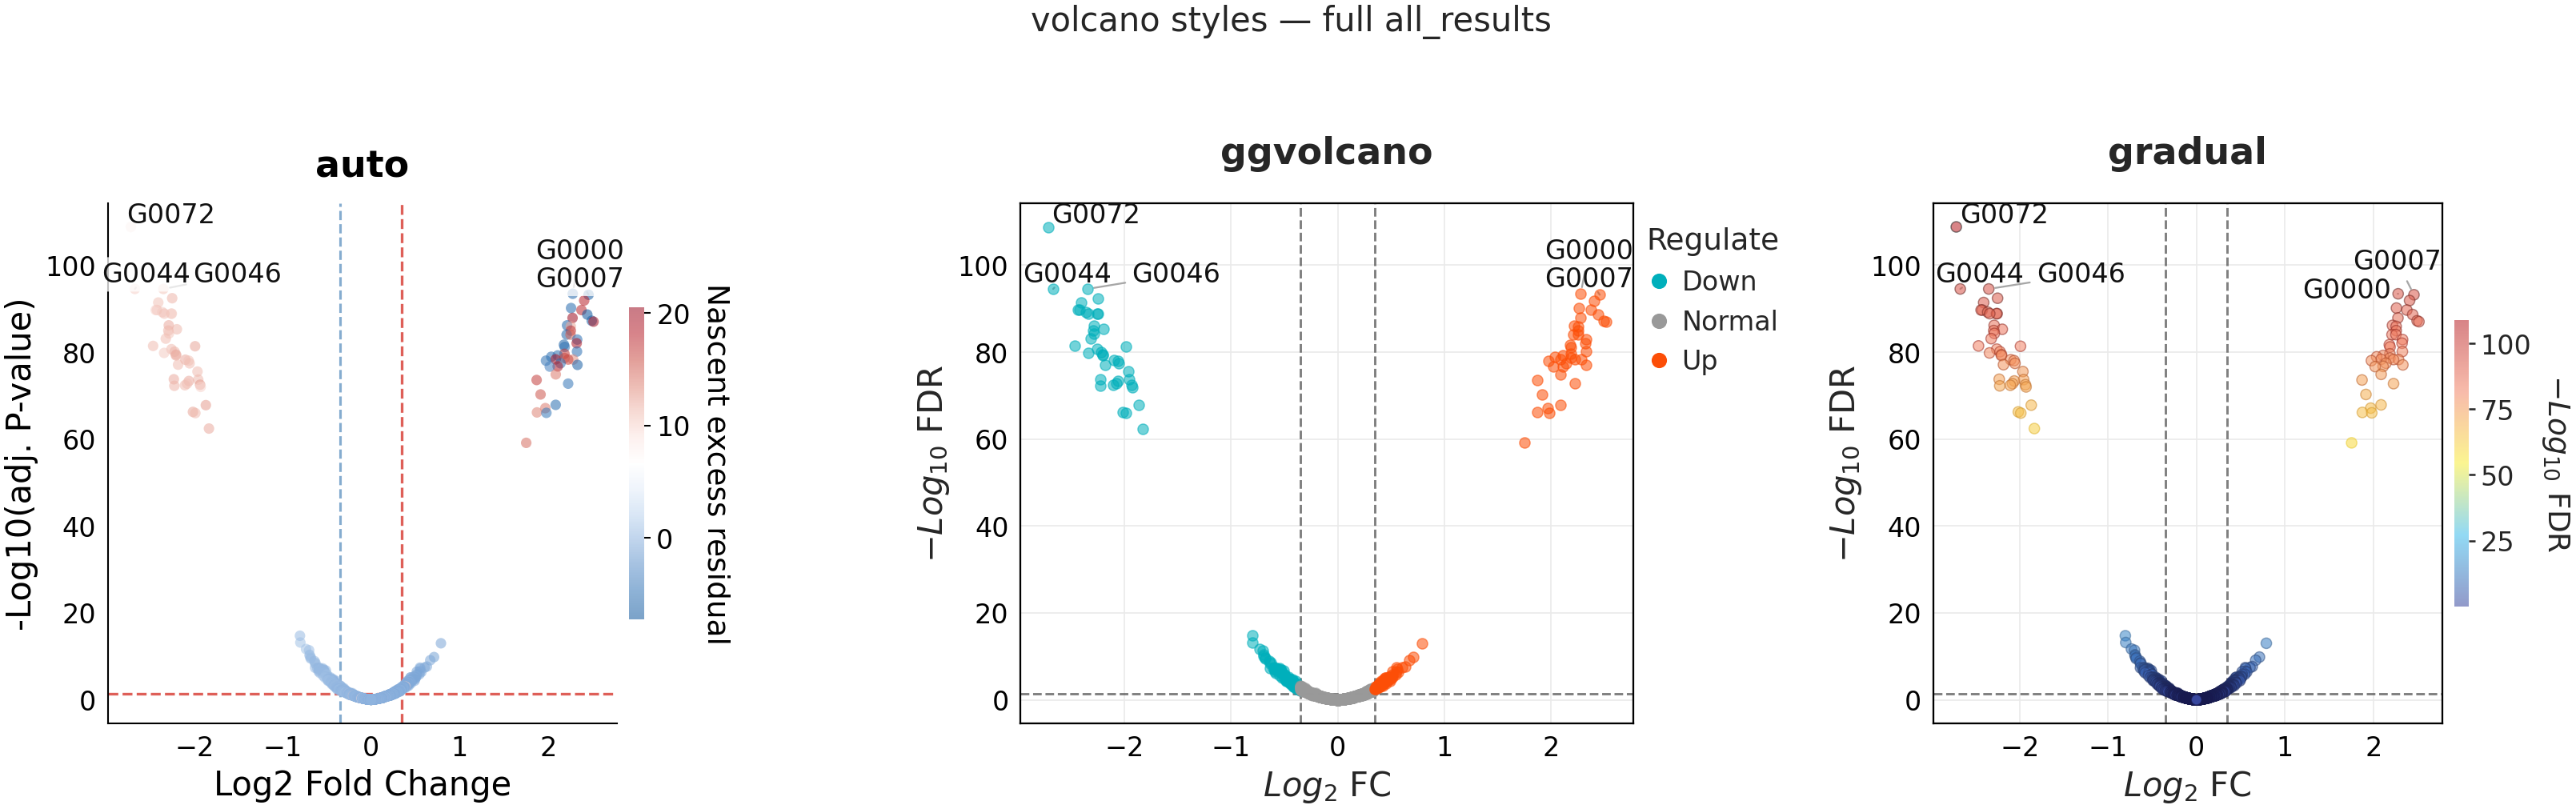

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.4), dpi=150)
for ax, style, title in zip(
    axes,
    ("auto", "ggvolcano", "gradual"),
    ("auto", "ggvolcano", "gradual"),
):
    scat.pl.volcano_plot(
        all_results,
        style=style,
        title=title,
        ax=ax,
        show=False,
        **VOLC,
    )
fig.suptitle("volcano styles — full all_results", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

**Variant — force-label a few genes** (still full table).


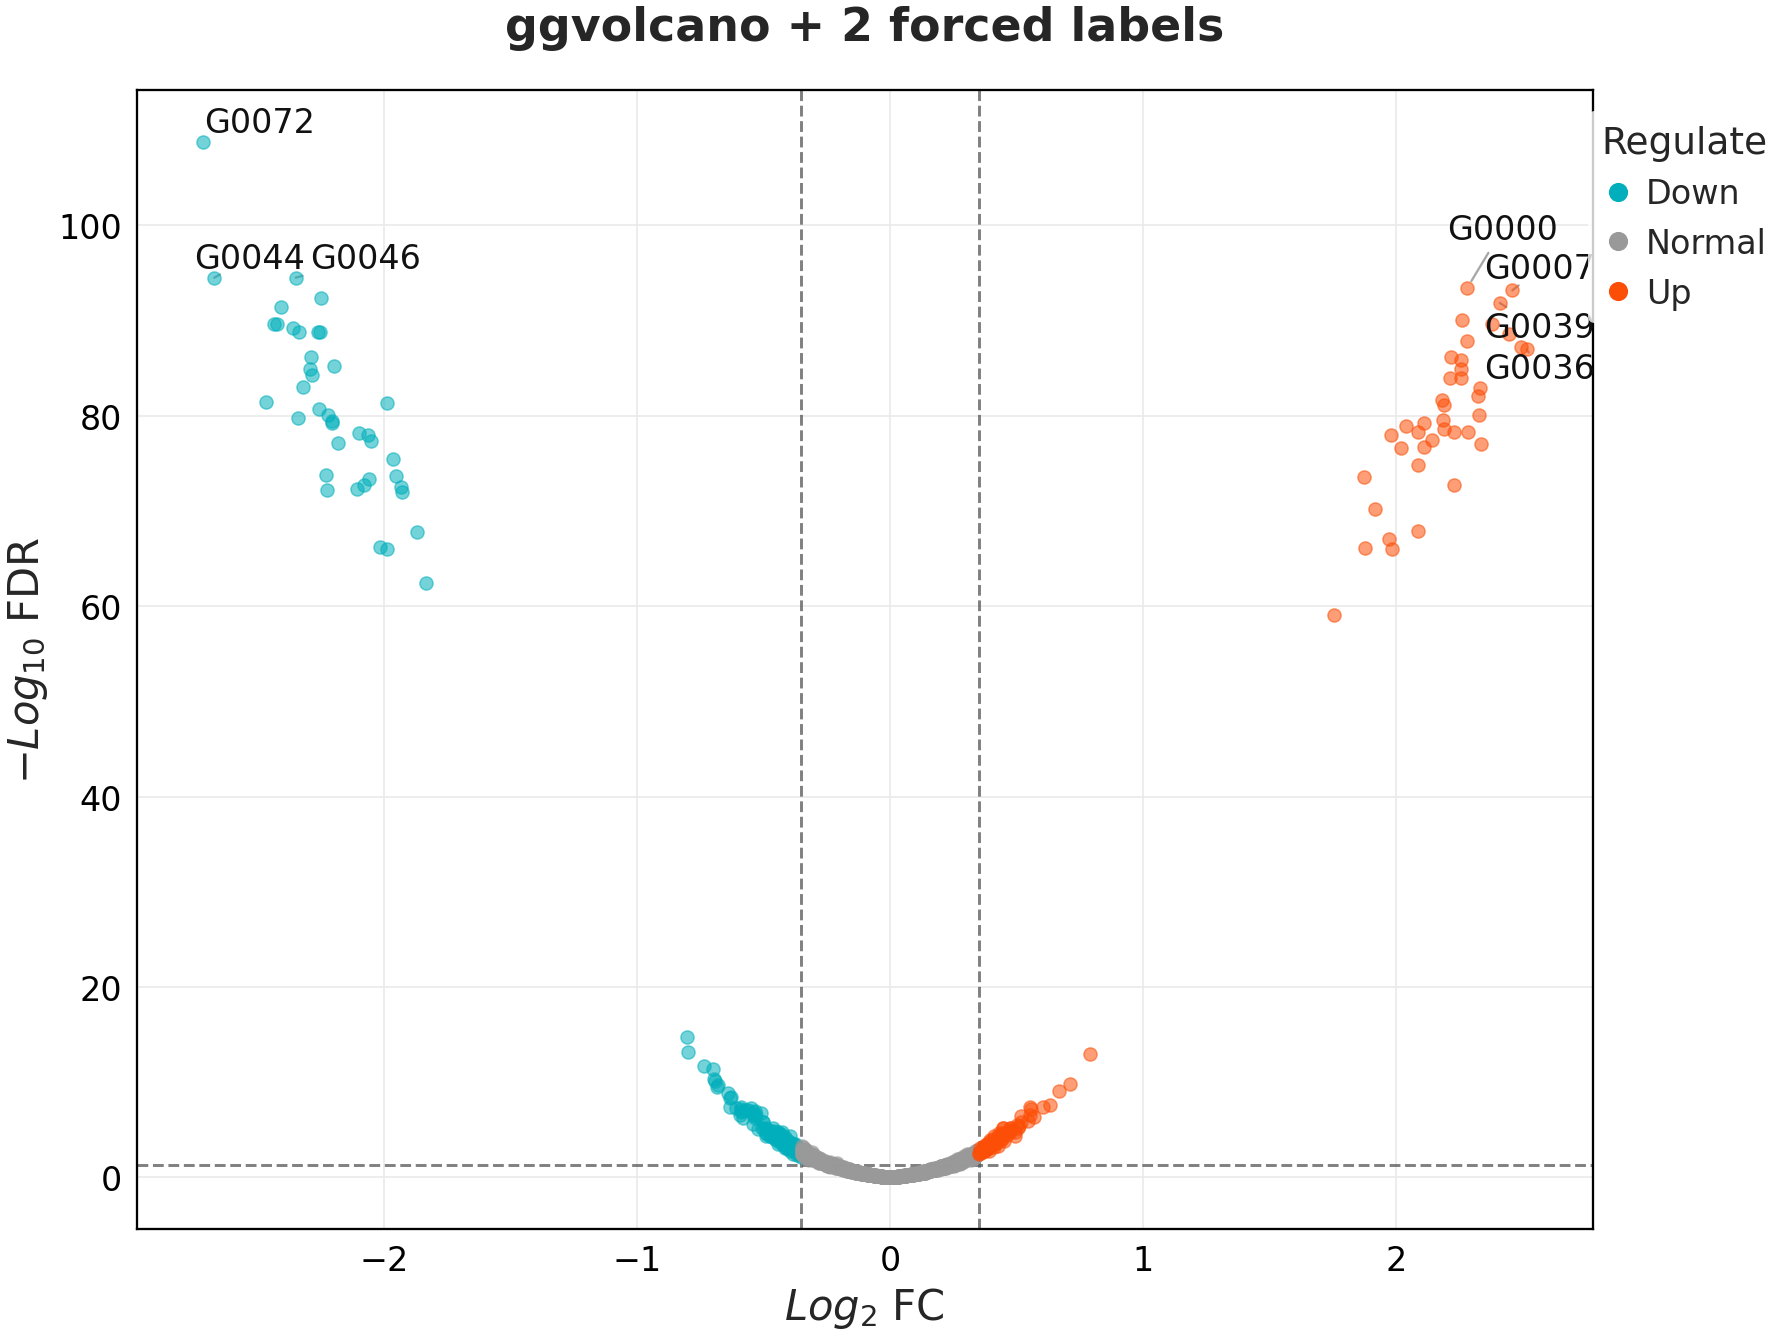

In [9]:
scat.pl.volcano_plot(
    all_results,
    style="ggvolcano",
    label_genes=list(top_genes[:2]),
    title="ggvolcano + 2 forced labels",
    show=True,
    **VOLC,
);

**Variant — point size and color**

Size:

| Kwarg | Effect |
|-------|--------|
| `s=` | Fixed size for every gene (simplest for dense clouds) |
| `point_scale` / `min_size` / `max_size` | Variable size (usually by score or −log10 padj when `s` is omitted) |
| `alpha` | Transparency |

Color:

| Kwarg | Effect |
|-------|--------|
| `style="auto"` + `color_by=` + `cmap=` | Continuous coloring (default `color_by="active_score"`) |
| `style="ggvolcano"` + `fills=` / `colors=` | Discrete Down / Normal / Up (use `palette("volcano")` or any journal set) |
| `style="gradual"` | Size and color track −log10(FDR) |


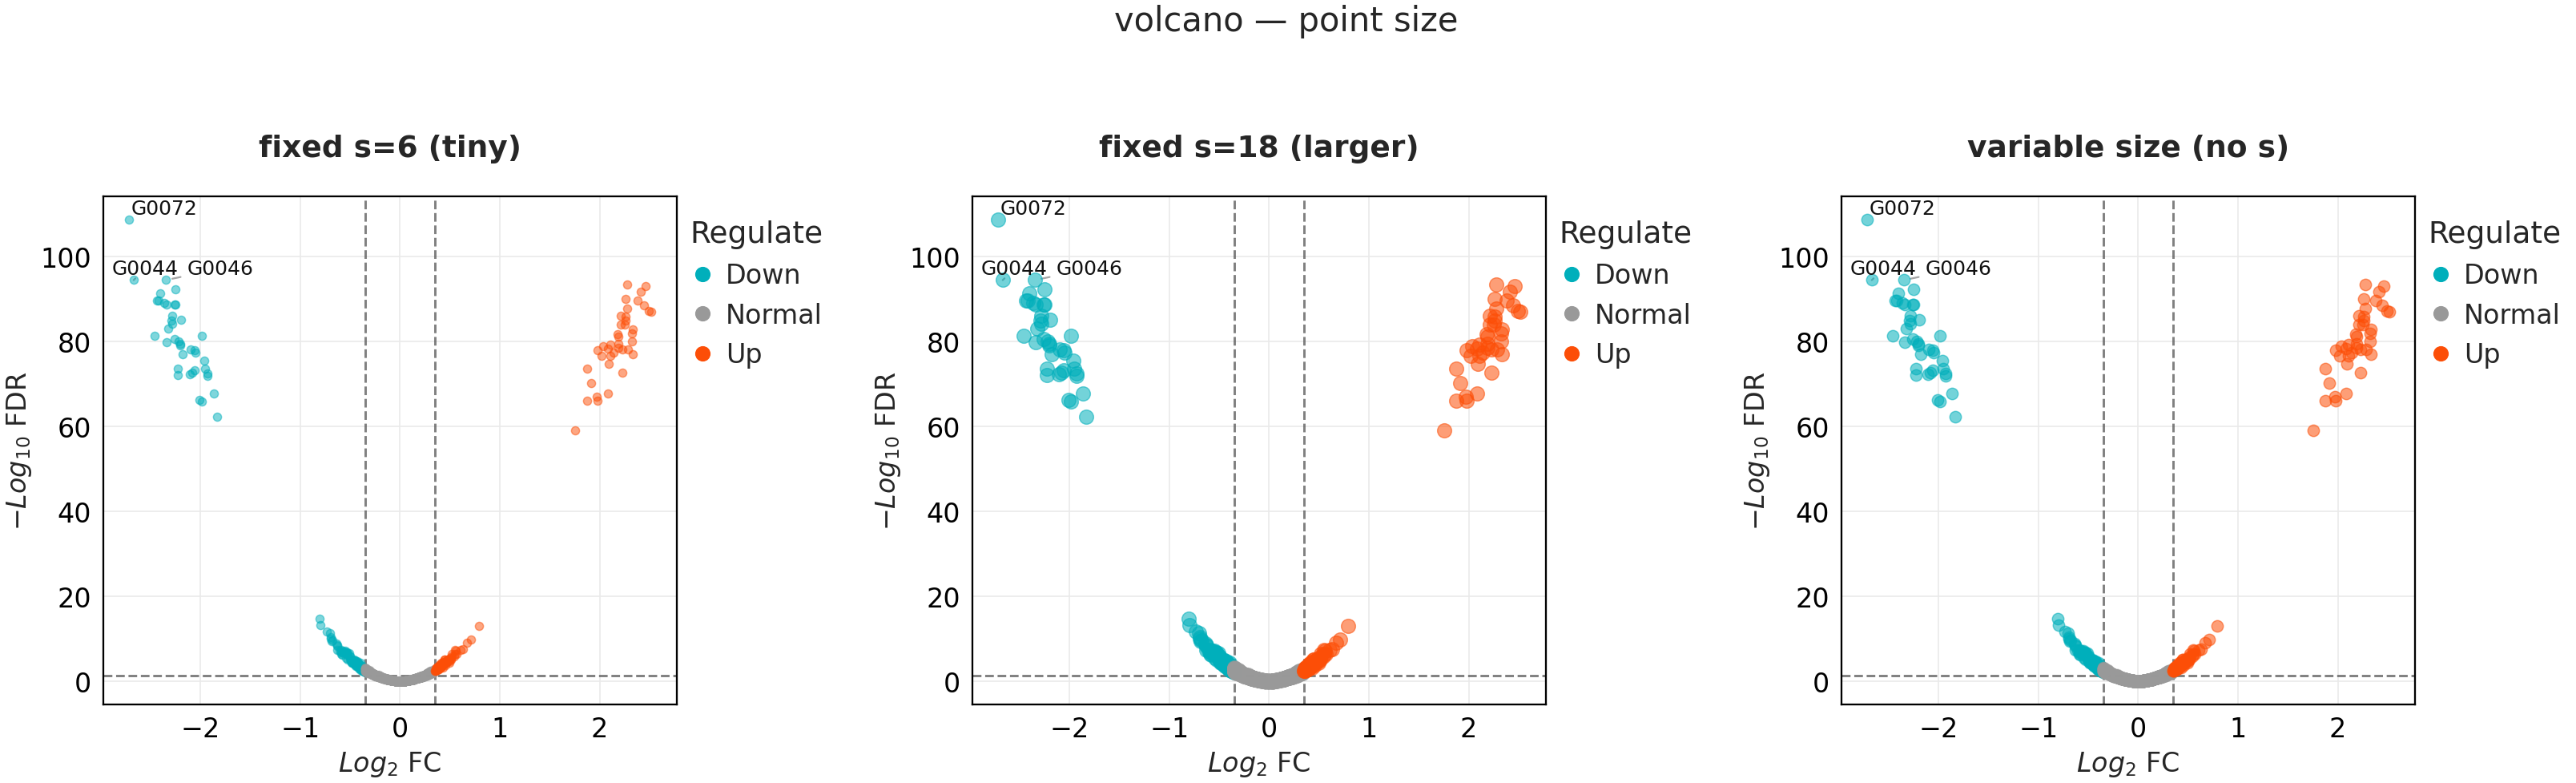

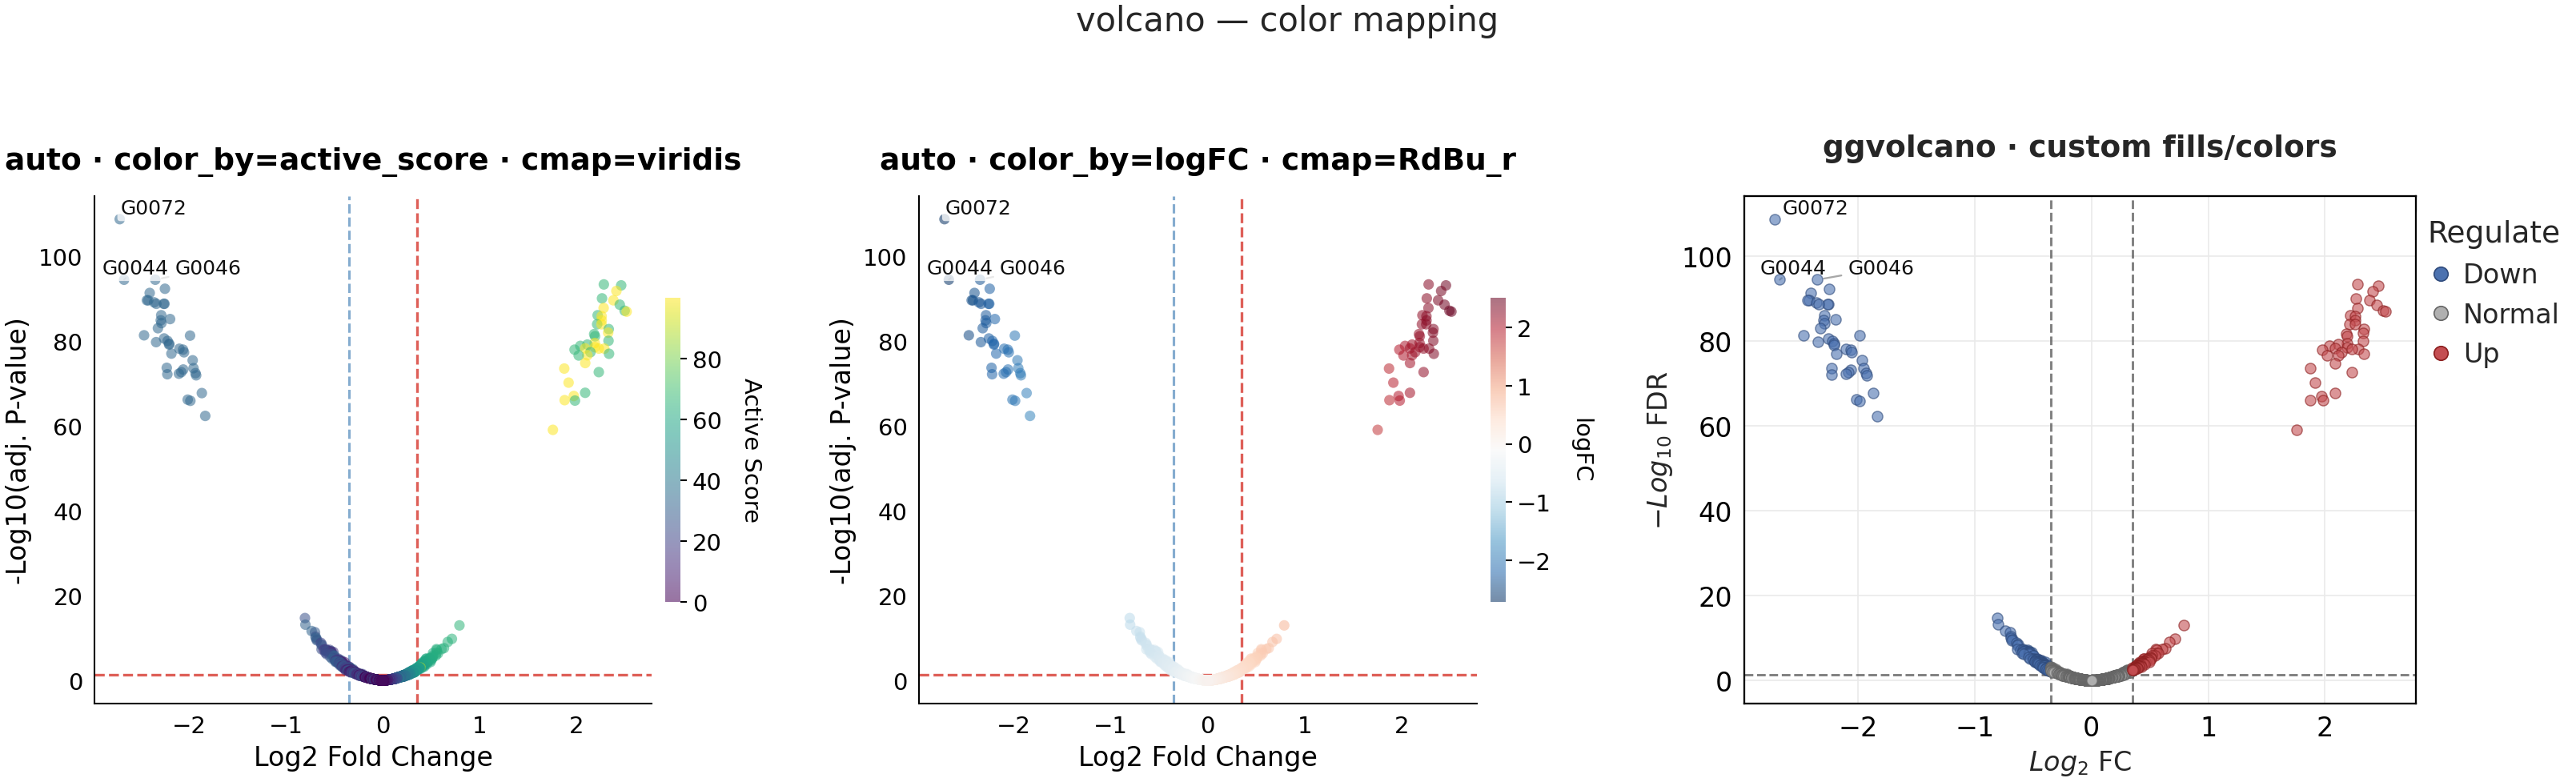

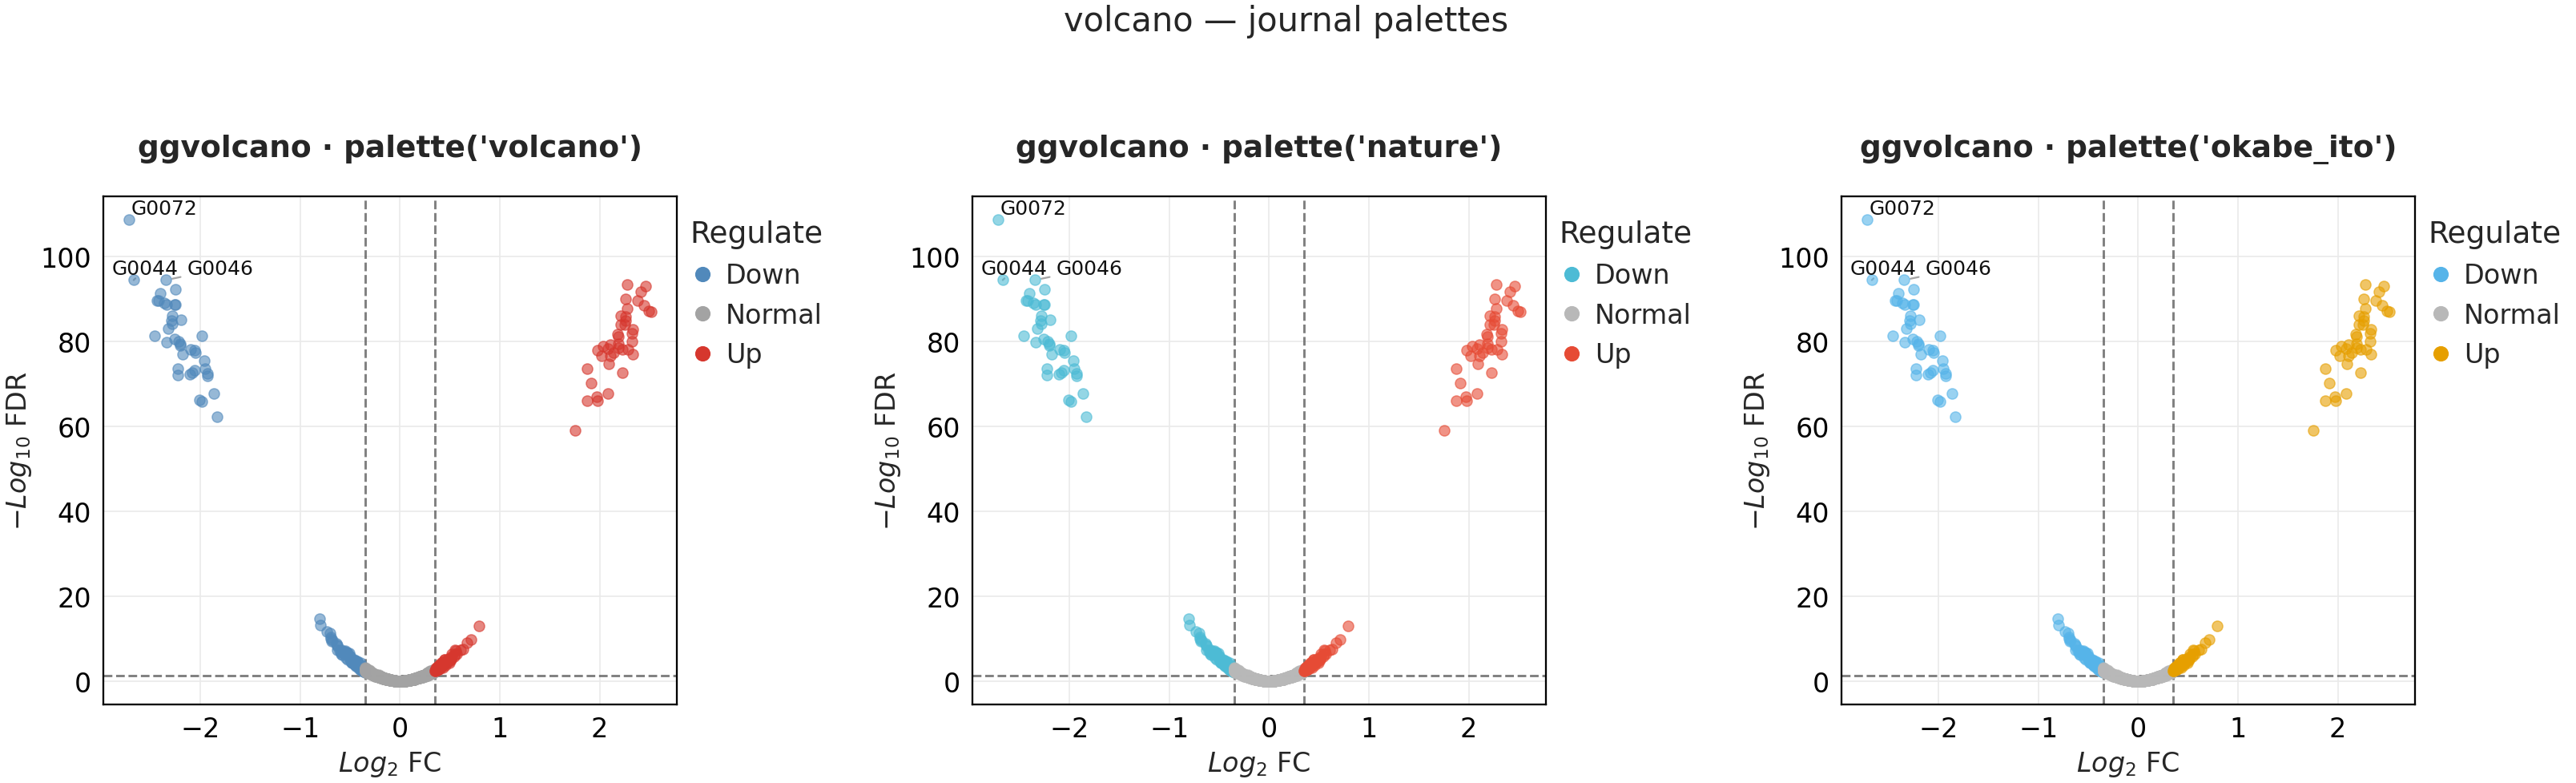

In [10]:
# Row 1: size controls (ggvolcano, same palette)
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), dpi=150)
size_specs = [
    {"s": 6, "alpha": 0.5, "title": "fixed s=6 (tiny)"},
    {"s": 18, "alpha": 0.55, "title": "fixed s=18 (larger)"},
    {
        "s": None,
        "point_scale": 1.2,
        "min_size": 4,
        "max_size": 80,
        "alpha": 0.55,
        "title": "variable size (no s)",
    },
]
for ax, kw in zip(axes, size_specs):
    scat.pl.volcano_plot(
        all_results,
        style="ggvolcano",
        top_n=3,
        logfc_cutoff=0.35,
        pval_cutoff=0.05,
        legend_position="UR",
        fontsize=8,
        label_fontsize=6,
        figsize=(5, 3.5),
        dpi=150,
        ax=ax,
        show=False,
        **kw,
    )
fig.suptitle("volcano — point size", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

# Row 2: color controls
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), dpi=150)
# continuous active_score
scat.pl.volcano_plot(
    all_results,
    style="auto",
    color_by="active_score",
    cmap="viridis",
    s=10,
    alpha=0.55,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    title="auto · color_by=active_score · cmap=viridis",
    fontsize=8,
    label_fontsize=6,
    ax=axes[0],
    show=False,
)
# continuous -log10 p via p_adj column still uses score path; color by logFC magnitude
scat.pl.volcano_plot(
    all_results,
    style="auto",
    color_by="logFC",
    cmap="RdBu_r",
    s=10,
    alpha=0.55,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    title="auto · color_by=logFC · cmap=RdBu_r",
    fontsize=8,
    label_fontsize=6,
    ax=axes[1],
    show=False,
)
# custom ggvolcano palette (Down, Normal, Up)
scat.pl.volcano_plot(
    all_results,
    style="ggvolcano",
    fills=("#4C72B0", "#B0B0B0", "#C44E52"),
    colors=("#2F4B7C", "#666666", "#8B1E1E"),
    s=10,
    alpha=0.6,
    top_n=3,
    logfc_cutoff=0.35,
    pval_cutoff=0.05,
    legend_position="UR",
    title="ggvolcano · custom fills/colors",
    fontsize=8,
    label_fontsize=6,
    ax=axes[2],
    show=False,
)
fig.suptitle("volcano — color mapping", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

# Row 3: journal palettes → Down / Normal / Up
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.3), dpi=150)
for ax, name in zip(axes, ("volcano", "nature", "okabe_ito")):
    pal = scat.pl.palette(name)
    fills = tuple(pal[:3]) if name == "volcano" else (pal[1], "#B8B8B8", pal[0])
    scat.pl.volcano_plot(
        all_results,
        style="ggvolcano",
        fills=fills,
        colors=fills,
        s=10,
        alpha=0.6,
        top_n=3,
        logfc_cutoff=0.35,
        pval_cutoff=0.05,
        legend_position="UR",
        title=f"ggvolcano · palette({name!r})",
        fontsize=8,
        label_fontsize=6,
        ax=ax,
        show=False,
    )
fig.suptitle("volcano — journal palettes", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

## 3. Rank plot and 3D volcano

**Functions**: `active_score_rankplot`, `volcano_3d`


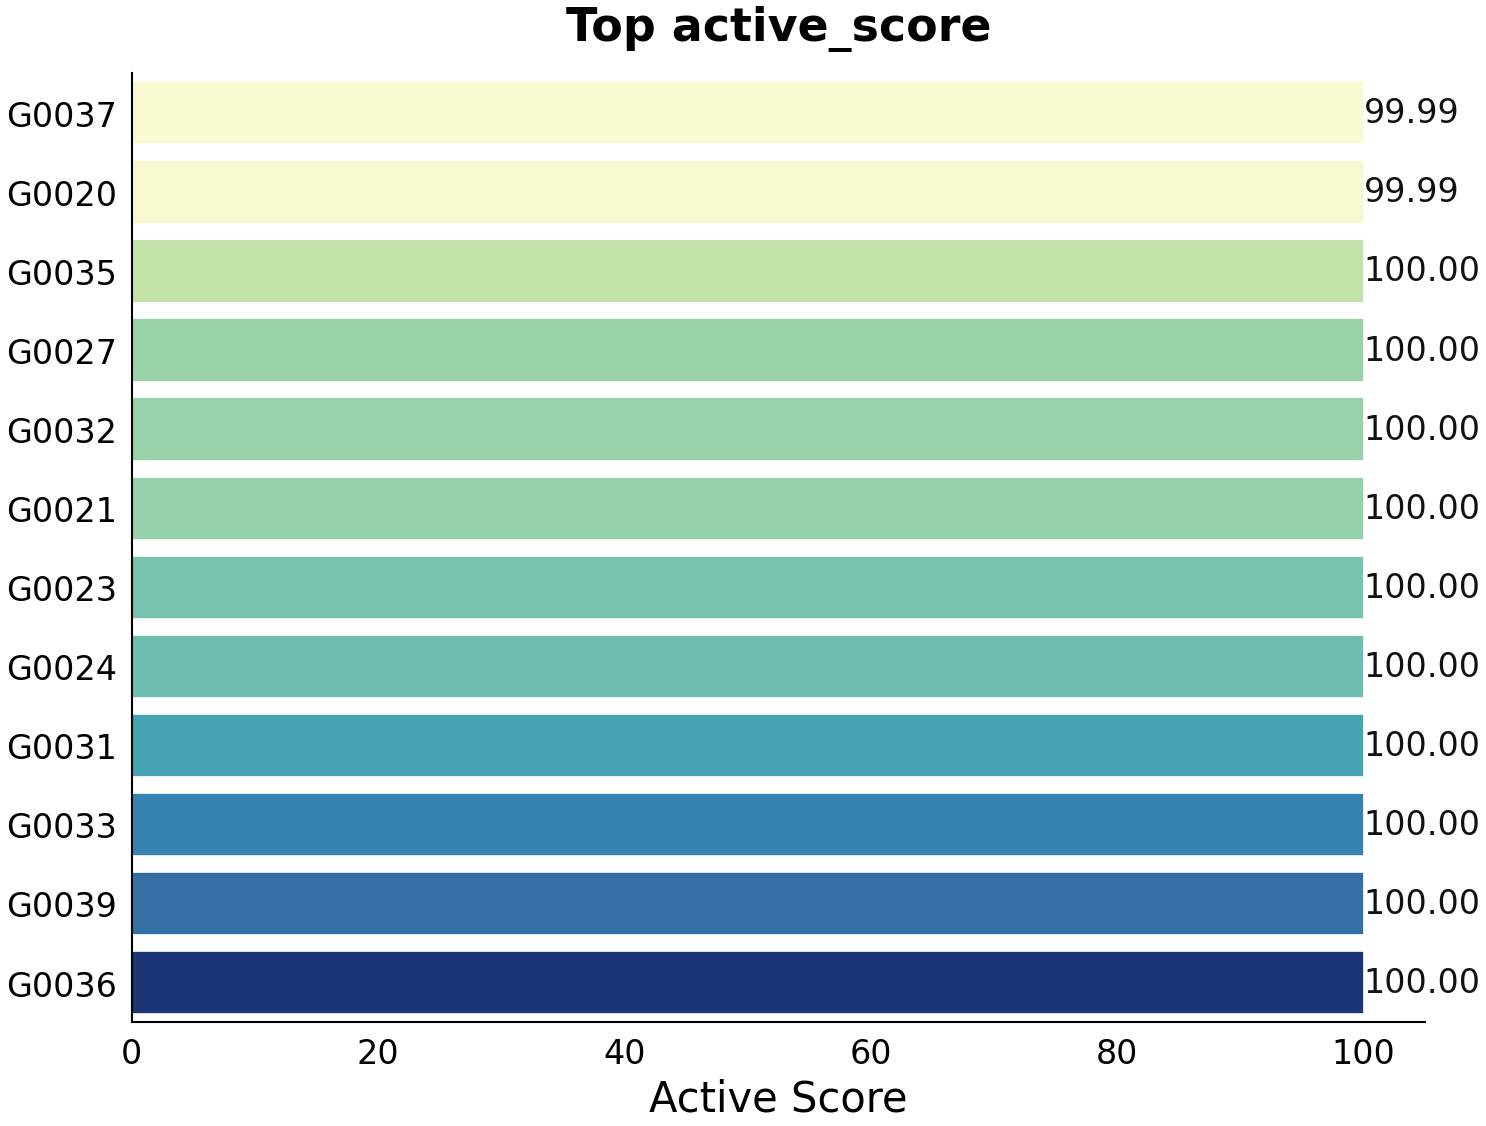

In [11]:
scat.pl.active_score_rankplot(
    all_results,
    top_n=12,
    title="Top active_score",
    figsize=(5.0, 3.8),
    dpi=150,
    show=True,
);

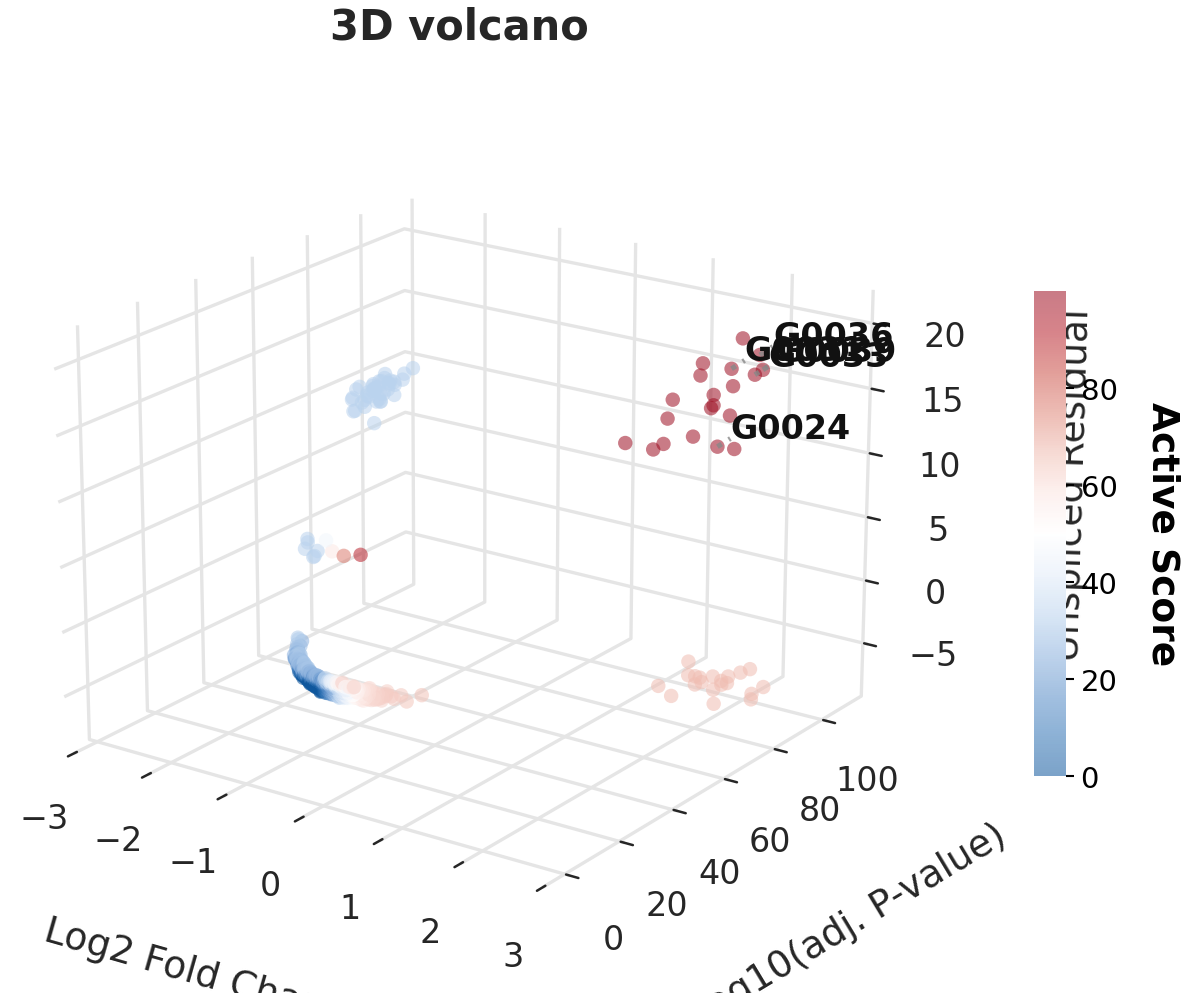

In [12]:
scat.pl.volcano_3d(
    all_results,
    top_n=5,
    s=12,
    alpha=0.55,
    cmap="scat_BuRd",
    title="3D volcano",
    figsize=(5.2, 4.2),
    dpi=150,
    fontsize=9,
    show=True,
);

## 4. Diagnostics

**Functions**: `bias_diagnostic_plot`, `gamma_shrinkage_plot`


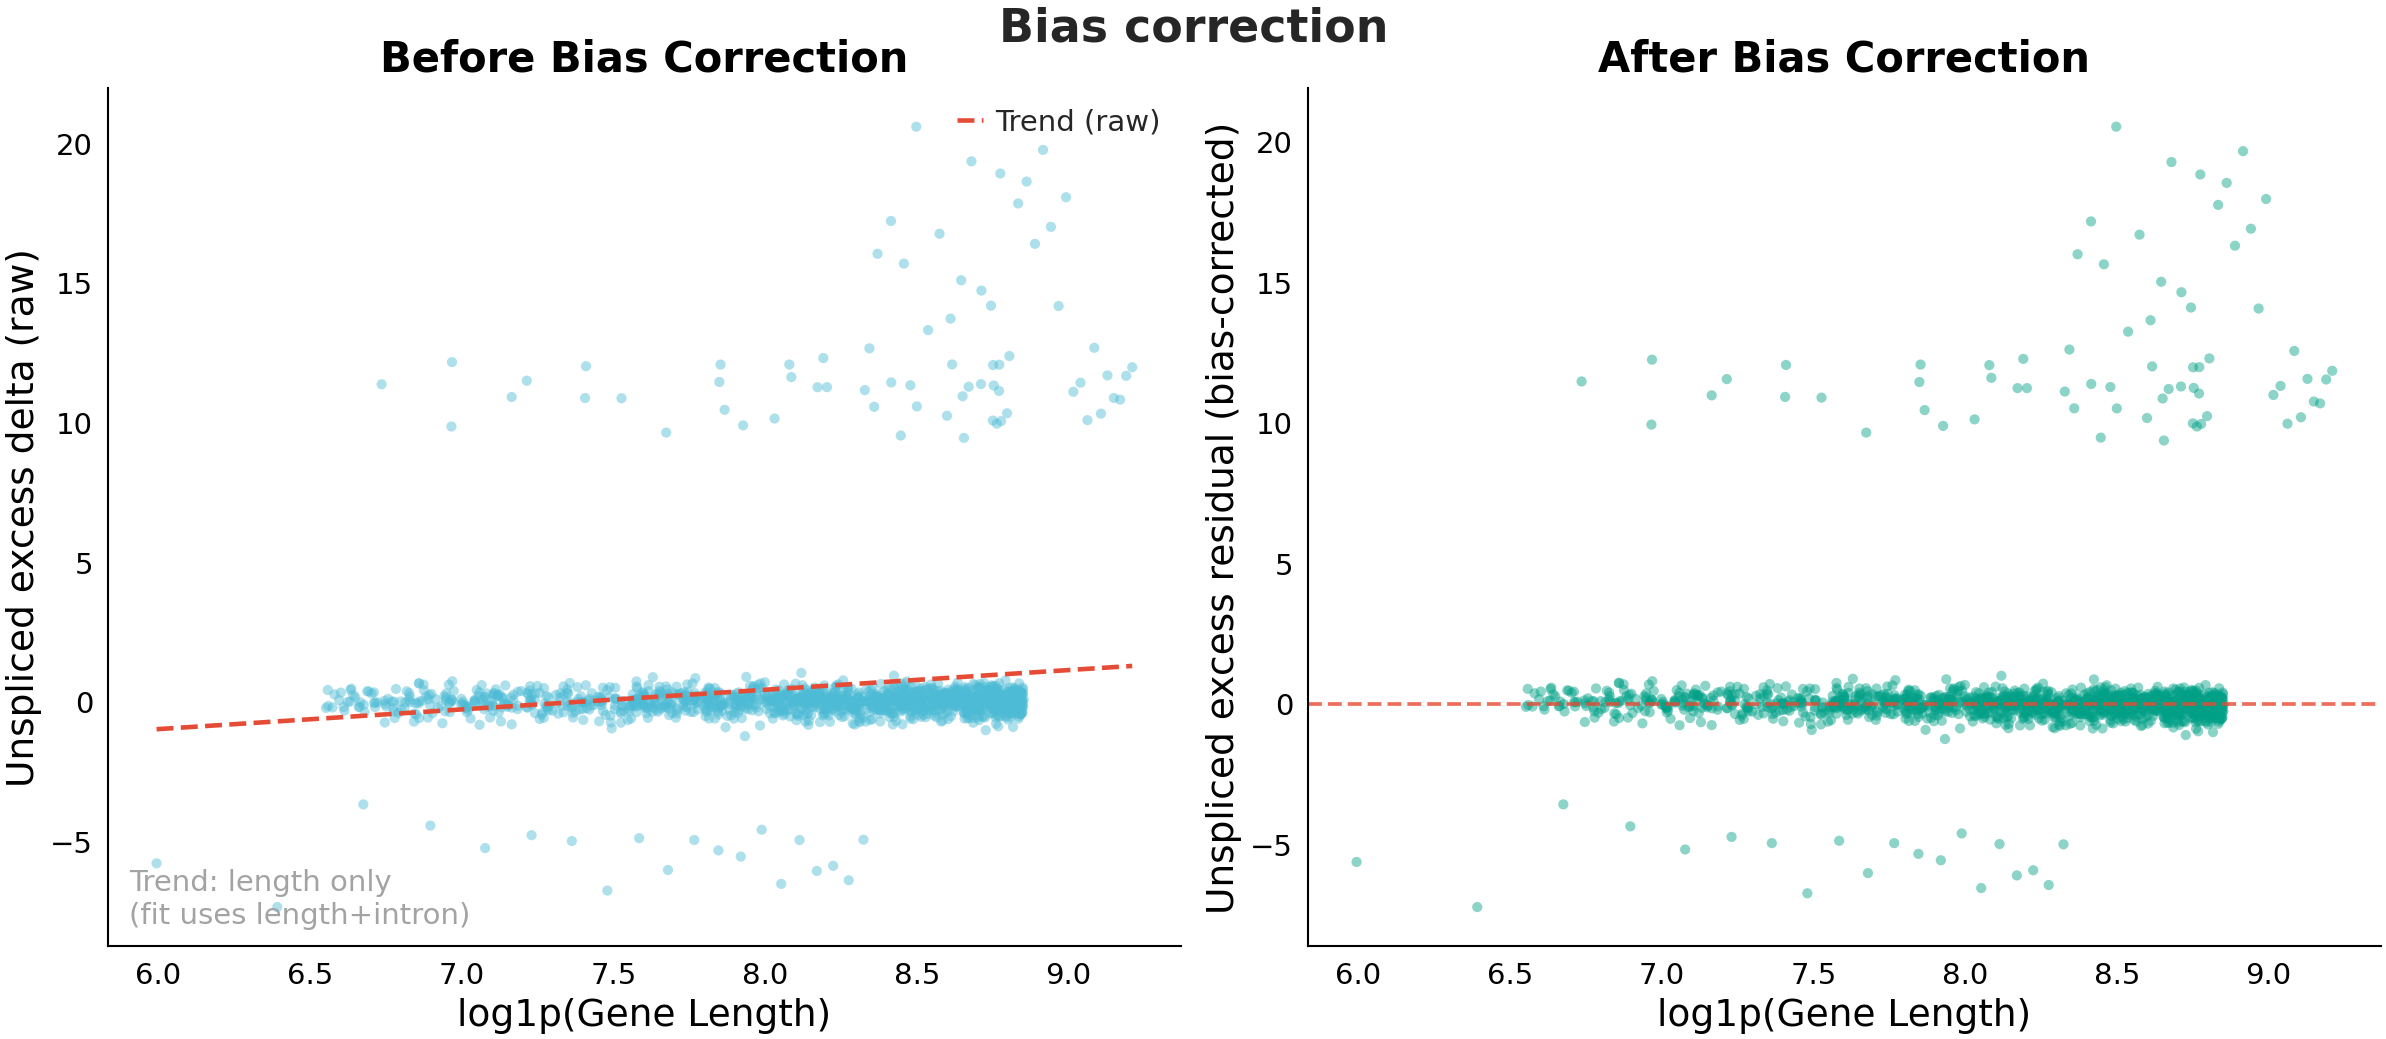

In [13]:
nat = scat.pl.palette("nature")
scat.pl.bias_diagnostic_plot(
    all_results,
    title="Bias correction",
    point_size=6,
    raw_color=nat[1],
    corrected_color=nat[2],
    trend_color=nat[0],
    figsize=(8.0, 3.4),
    dpi=150,
    fontsize=9,
    show=True,
);

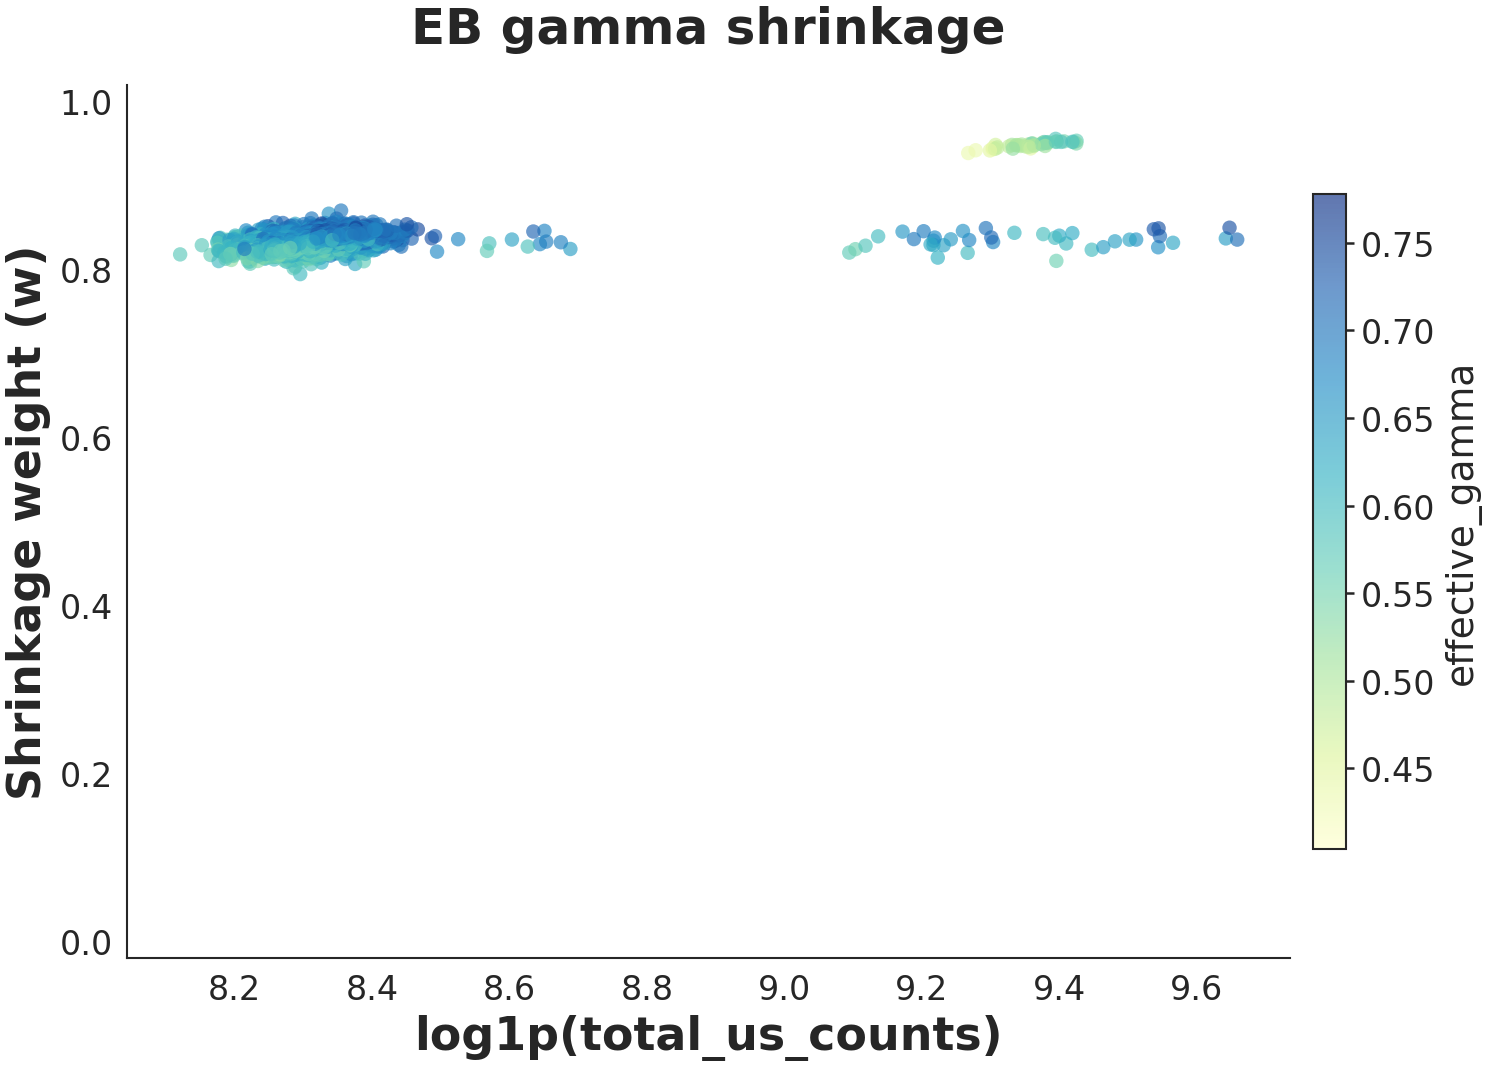

In [14]:
scat.pl.gamma_shrinkage_plot(
    all_results,
    cmap="scat_YlGnBu",
    title="EB gamma shrinkage",
    figsize=(5.0, 3.6),
    dpi=150,
    show=True,
);

## 5. Phase portraits and heatmap

**Functions**: `velocity_phase_portraits`, `active_genes_heatmap`


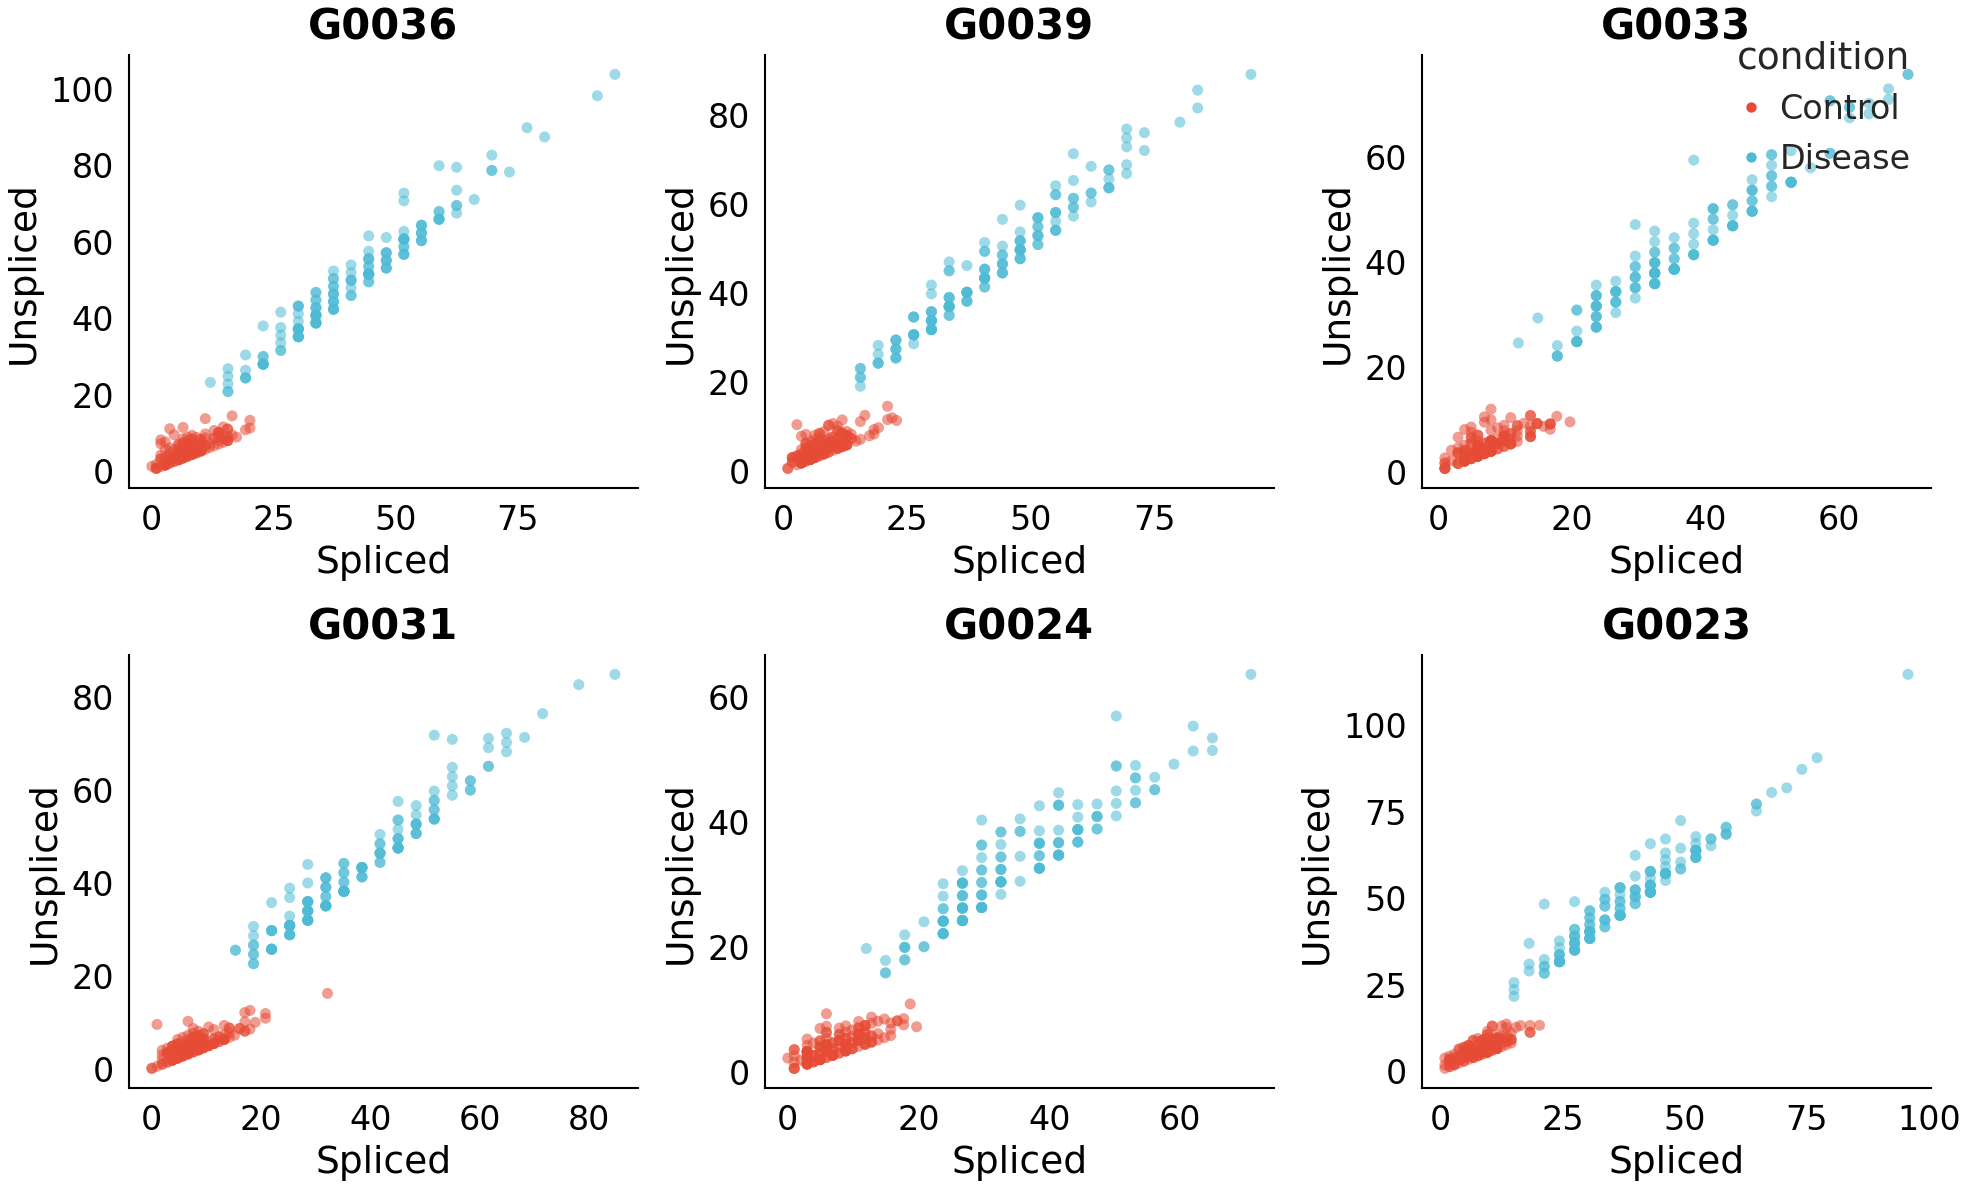

In [15]:
scat.pl.velocity_phase_portraits(
    adata_res,
    genes=top_genes,
    groupby="condition",
    max_genes=6,
    figsize_per_gene=(2.2, 2.0),
    dpi=150,
    show=True,
);

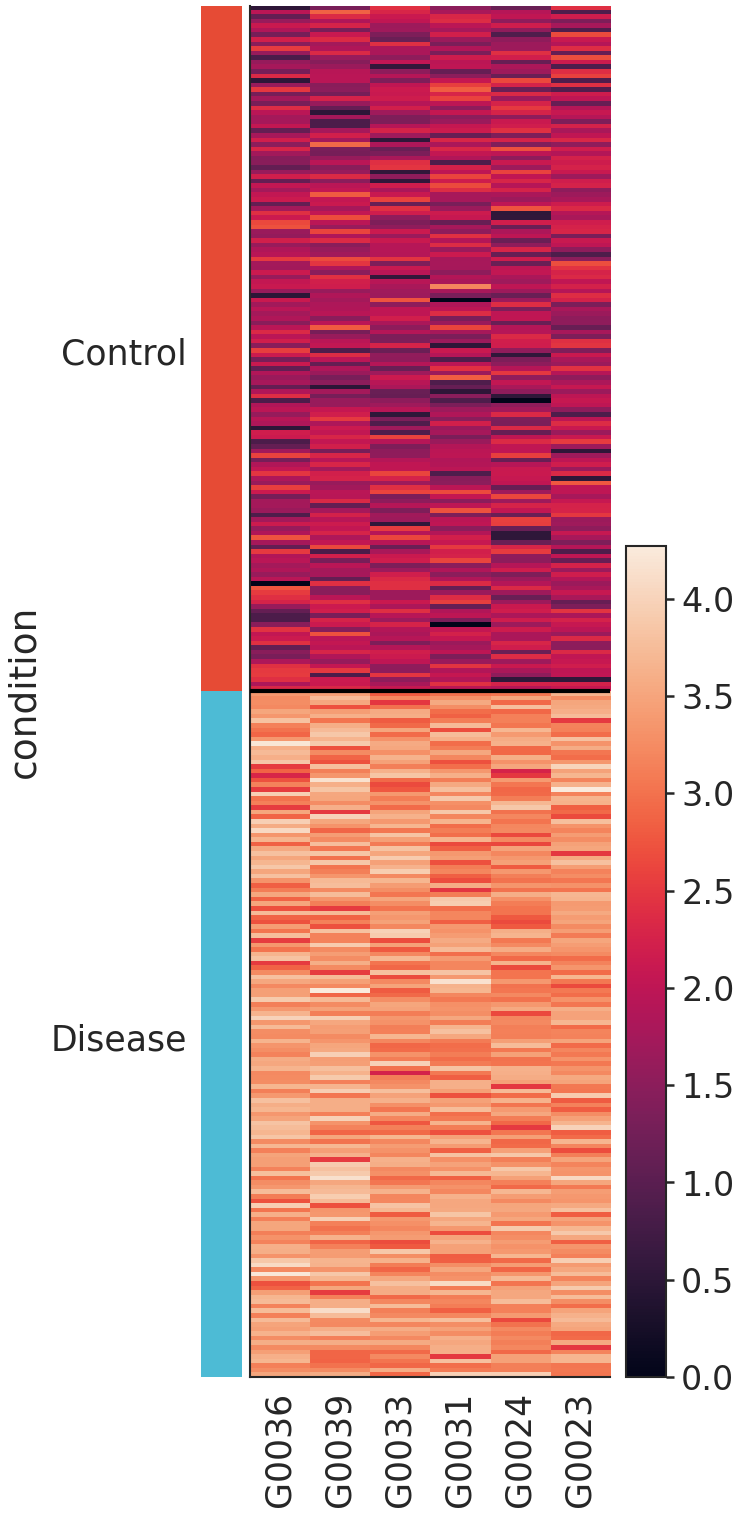

In [16]:
scat.pl.active_genes_heatmap(
    adata_res,
    genes=top_genes,
    groupby="condition",
    show=True,
);

**Variant — `gene_annotation`** (new in 0.10.16, lightweight SCP
`FeatureHeatmap`-inspired grouping). Reorders `genes` into contiguous blocks
by a categorical annotation and adds a labeled bracket above the heatmap —
no bundled TF/pathway database, just scanpy's own public
`var_group_positions`/`var_group_labels`. Here the annotation is
`mechanism_class` for the same `top_genes`.


{'G0036': 'transcription-driven', 'G0039': 'transcription-driven', 'G0033': 'transcription-driven', 'G0031': 'transcription-driven', 'G0024': 'transcription-driven', 'G0023': 'transcription-driven'}


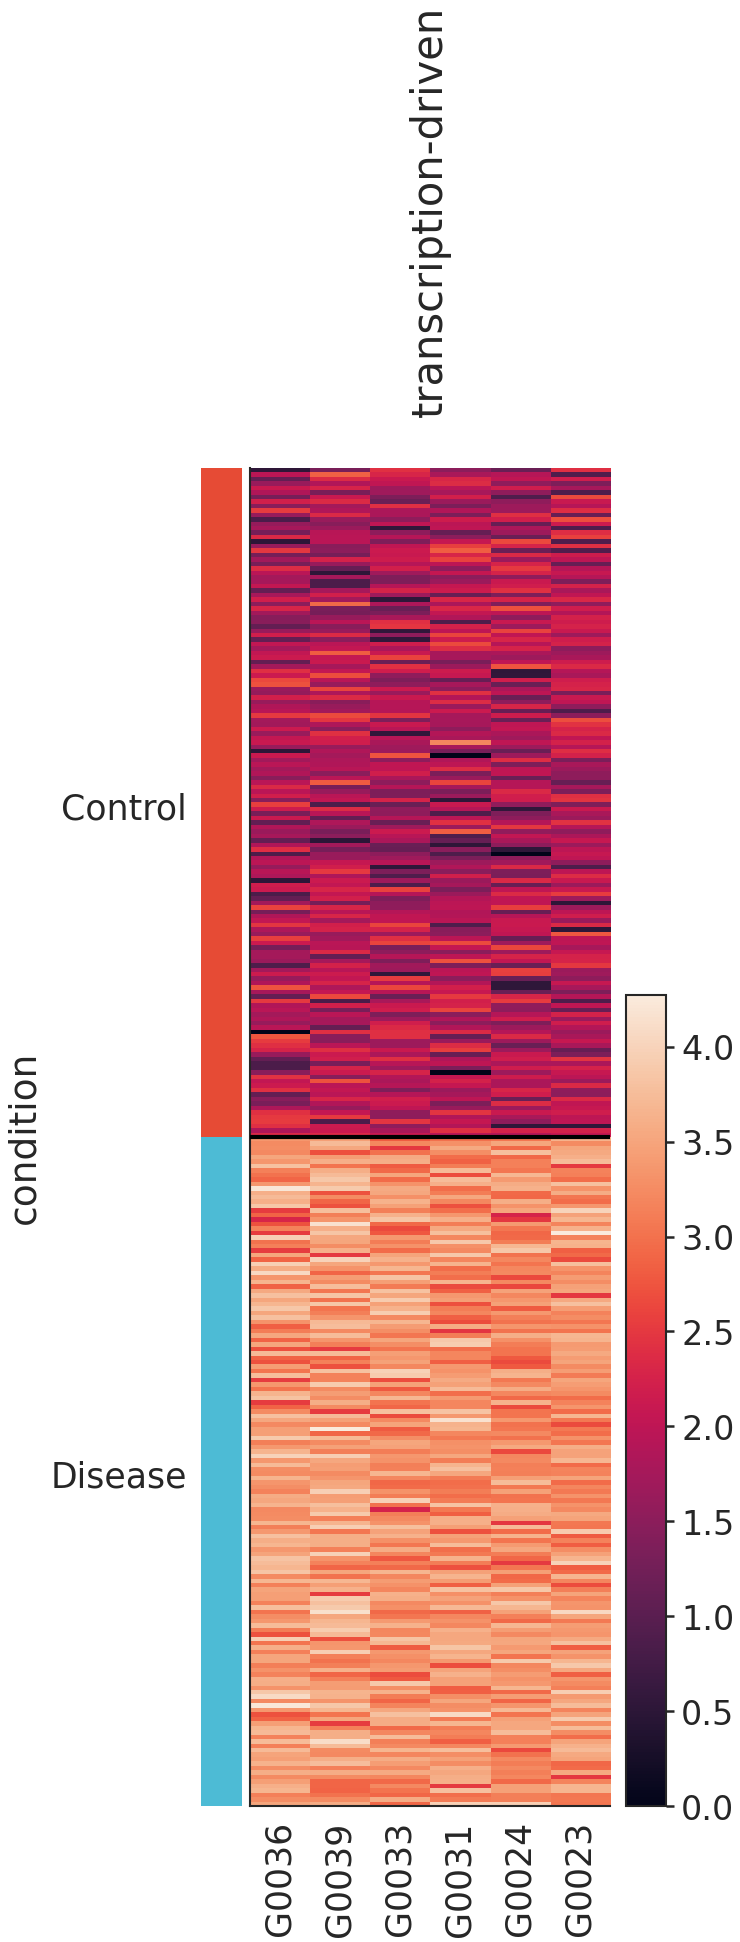

In [17]:
all_results_mech, _mech_meta = scat.annotate_mechanism_class(all_results)
gene_to_mech = all_results_mech.loc[top_genes, "mechanism_class"].to_dict()
print(gene_to_mech)

scat.pl.active_genes_heatmap(
    adata_res,
    genes=top_genes,
    groupby="condition",
    gene_annotation=gene_to_mech,
    show=True,
);

## 6. Enrichment and **multi-group comparison**

Mock ORA tables for three clusters (`up`, `down`, `shared`) so **UpSet** and
**Venn** show multi-set overlap (the usual “compare enrichment across gene
lists” view). Offline — no gene-set download.


In [18]:
def _mock_enrich(
    cluster: str, terms: list[str], sign: float = 1.0, padj0: float = 0.001
) -> pd.DataFrame:
    rows = []
    for i, t in enumerate(terms):
        rows.append(
            {
                "Term": t,
                "Description": t.replace("_", " "),
                "Cluster": cluster,
                "p.adjust": padj0 * (i + 1),
                "GeneRatio": f"{14 - i}/100",
                "BgRatio": "50/5000",
                "Count": int(14 - i),
                "FoldEnrichment": float(3.5 - 0.1 * i),
                "geneID": "/".join(genes[:5]),
                "NES": float(sign * (2.0 - 0.07 * i)),
            }
        )
    return pd.DataFrame(rows)


# Overlapping term sets → non-trivial UpSet / Venn
terms_up = [f"UP_path_{i}" for i in range(1, 8)] + [f"SHARED_{i}" for i in range(1, 5)]
terms_down = [f"DN_path_{i}" for i in range(1, 7)] + [f"SHARED_{i}" for i in range(2, 6)]
terms_shared = [f"SHARED_{i}" for i in range(1, 7)] + [f"MID_path_{i}" for i in range(1, 5)]

enrich_up = _mock_enrich("up", terms_up, sign=1.0)
enrich_down = _mock_enrich("down", terms_down, sign=-1.0)
enrich_mid = _mock_enrich("shared", terms_shared, sign=0.5, padj0=0.002)
enrich_cmp = pd.concat([enrich_up, enrich_down, enrich_mid], ignore_index=True)
print("clusters:", enrich_cmp.groupby("Cluster").size().to_dict())
print("unique terms:", enrich_cmp["Term"].nunique())

clusters: {'down': 10, 'shared': 10, 'up': 11}
unique terms: 23


### Single-list ORA: dot + bar

**Functions**: `enrich_dotplot`, `enrich_barplot`
Default sequential map: **`scat_YlGnBu`**. Override with `cmap=`
(`"scat_YlOrRd"`, `"viridis"`, …). GSEA dots use `color_by="NES"` and
the diverging map **`scat_BuRd`**.


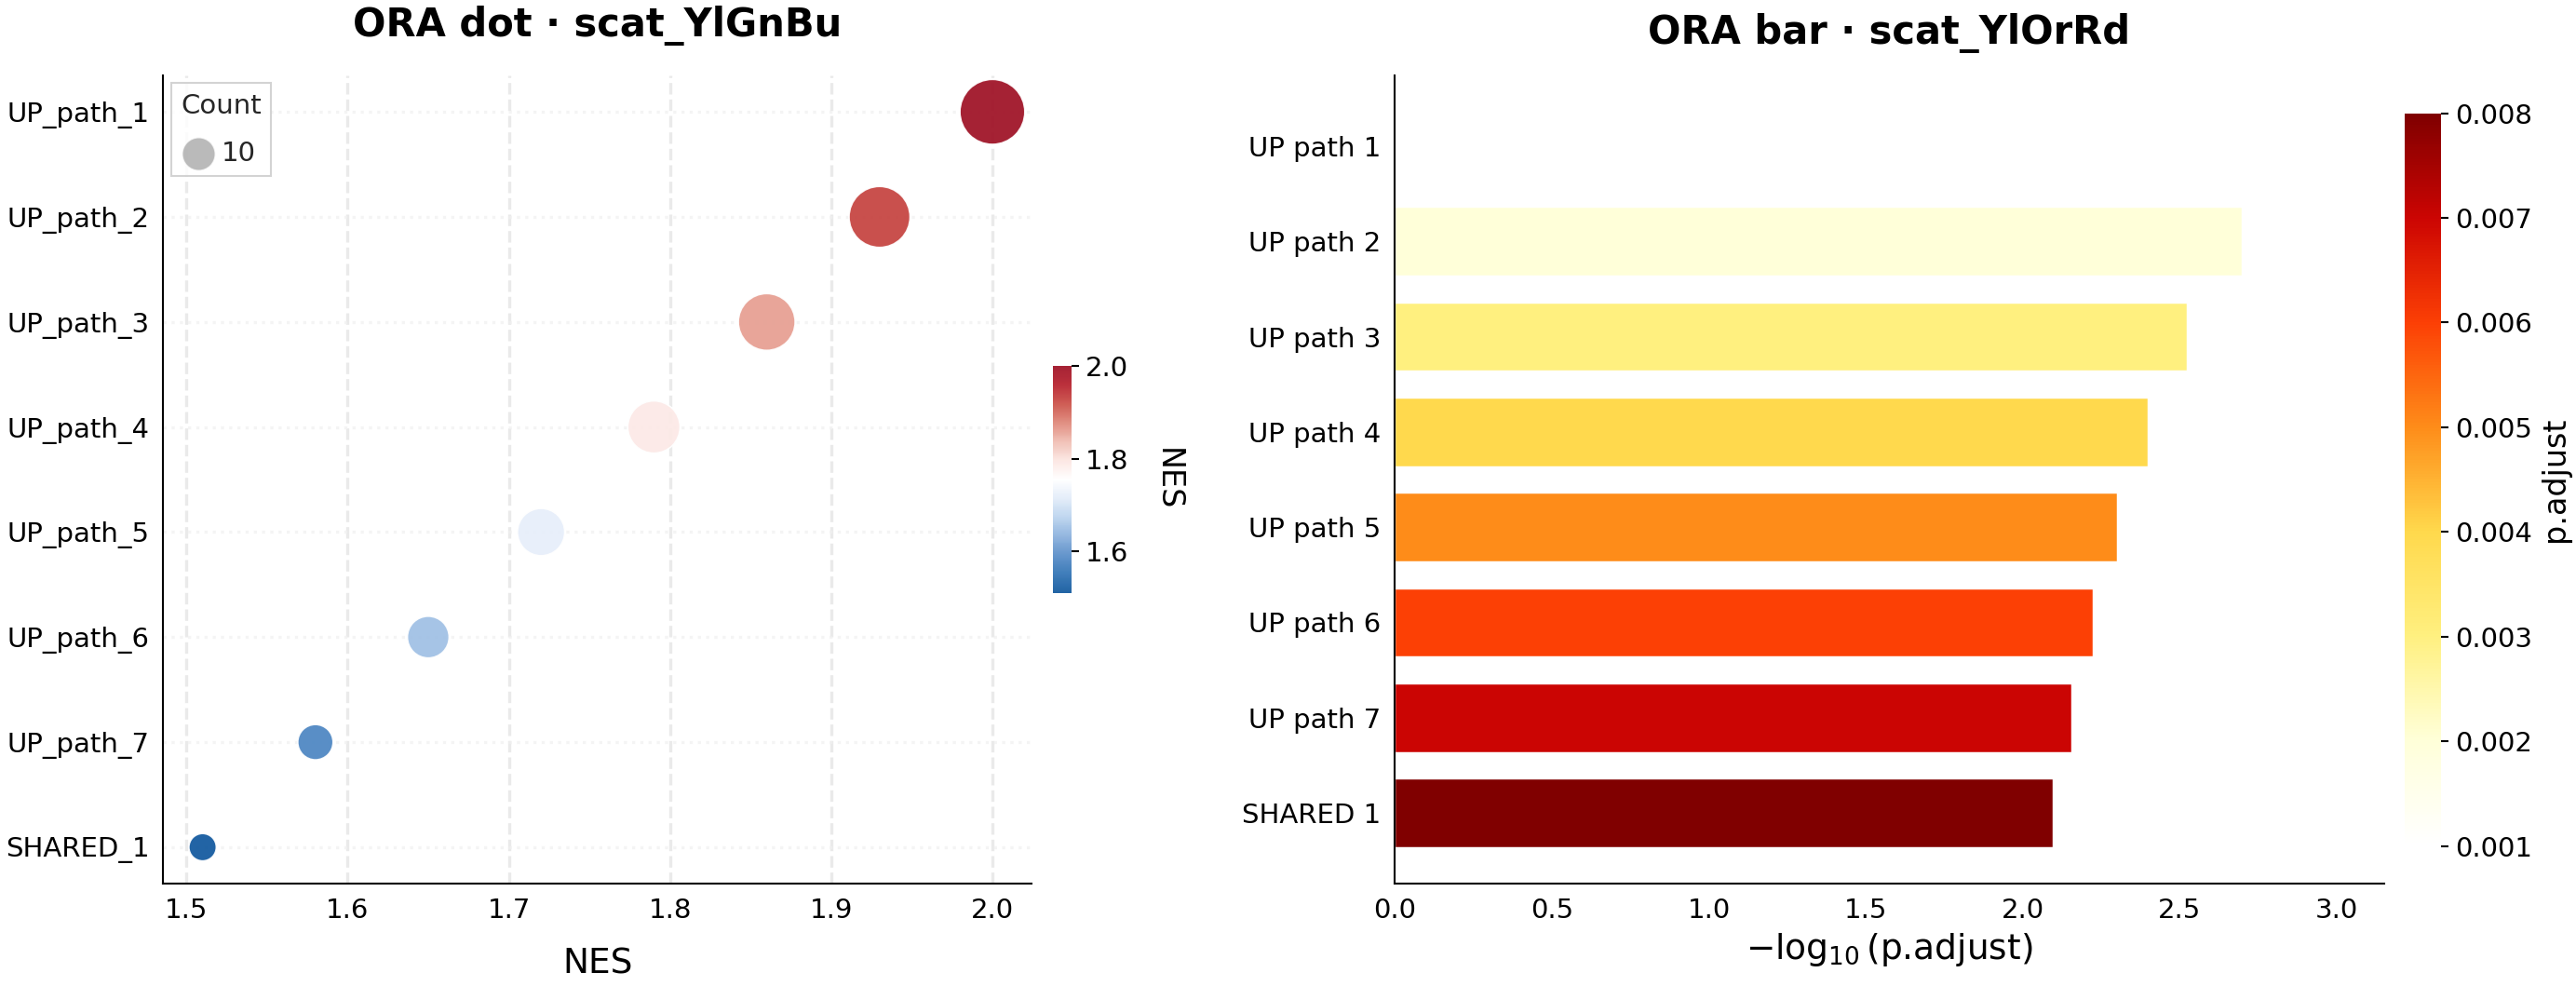

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), dpi=150)
scat.pl.enrich_dotplot(
    enrich_up,
    top_n=8,
    title="ORA dot · scat_YlGnBu",
    cmap="scat_YlGnBu",
    ax=axes[0],
    show=False,
    fontsize=9,
)
scat.pl.enrich_barplot(
    enrich_up,
    top_n=8,
    title="ORA bar · scat_YlOrRd",
    cmap="scat_YlOrRd",
    ax=axes[1],
    show=False,
    fontsize=9,
)
plt.tight_layout()
plt.show()

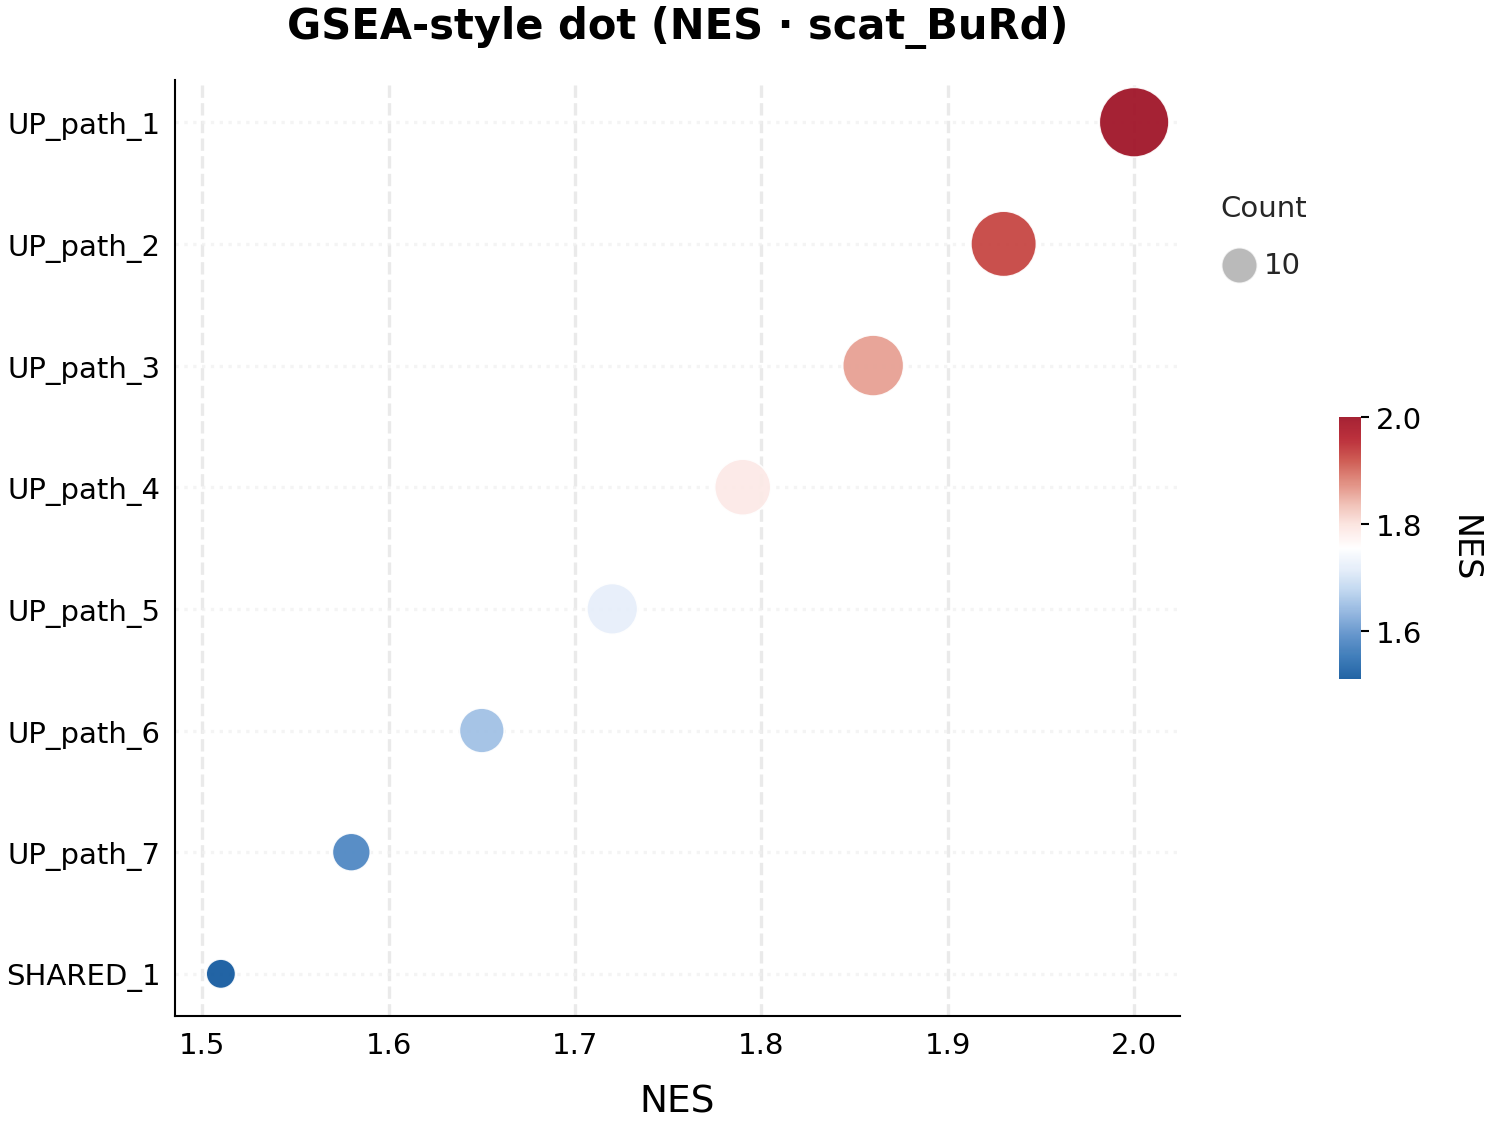

In [20]:
scat.pl.enrich_dotplot(
    enrich_up,
    top_n=8,
    x="NES",
    color_by="NES",
    cmap="scat_BuRd",
    title="GSEA-style dot (NES · scat_BuRd)",
    figsize=(5.0, 3.8),
    dpi=150,
    fontsize=9,
    show=True,
);

### Multi-group comparison dot plot (compareCluster)

**What it answers:** which enriched terms dominate *each* group, in the classic
clusterProfiler `compareCluster` grid — the third multi-group view alongside
UpSet and Venn.

**Function**: `compare_dotplot` — **groups are columns** (x-axis), **terms are
rows** (y-axis), a dot at each enriched (group, term) cell; size = `GeneRatio`,
color = `p.adjust`. Terms shared across groups (the `SHARED_*` set here) line up
on one row with a dot in each column. On real data this is exactly how you
compare **GO vs. KEGG** or up- vs. down-regulated enrichment (see
{doc}`t_gse96583_standalone_de_enrichment`).

`enrich_dotplot(..., facet_by_cluster=True)` is the same table as separate
panels instead of one compare grid.


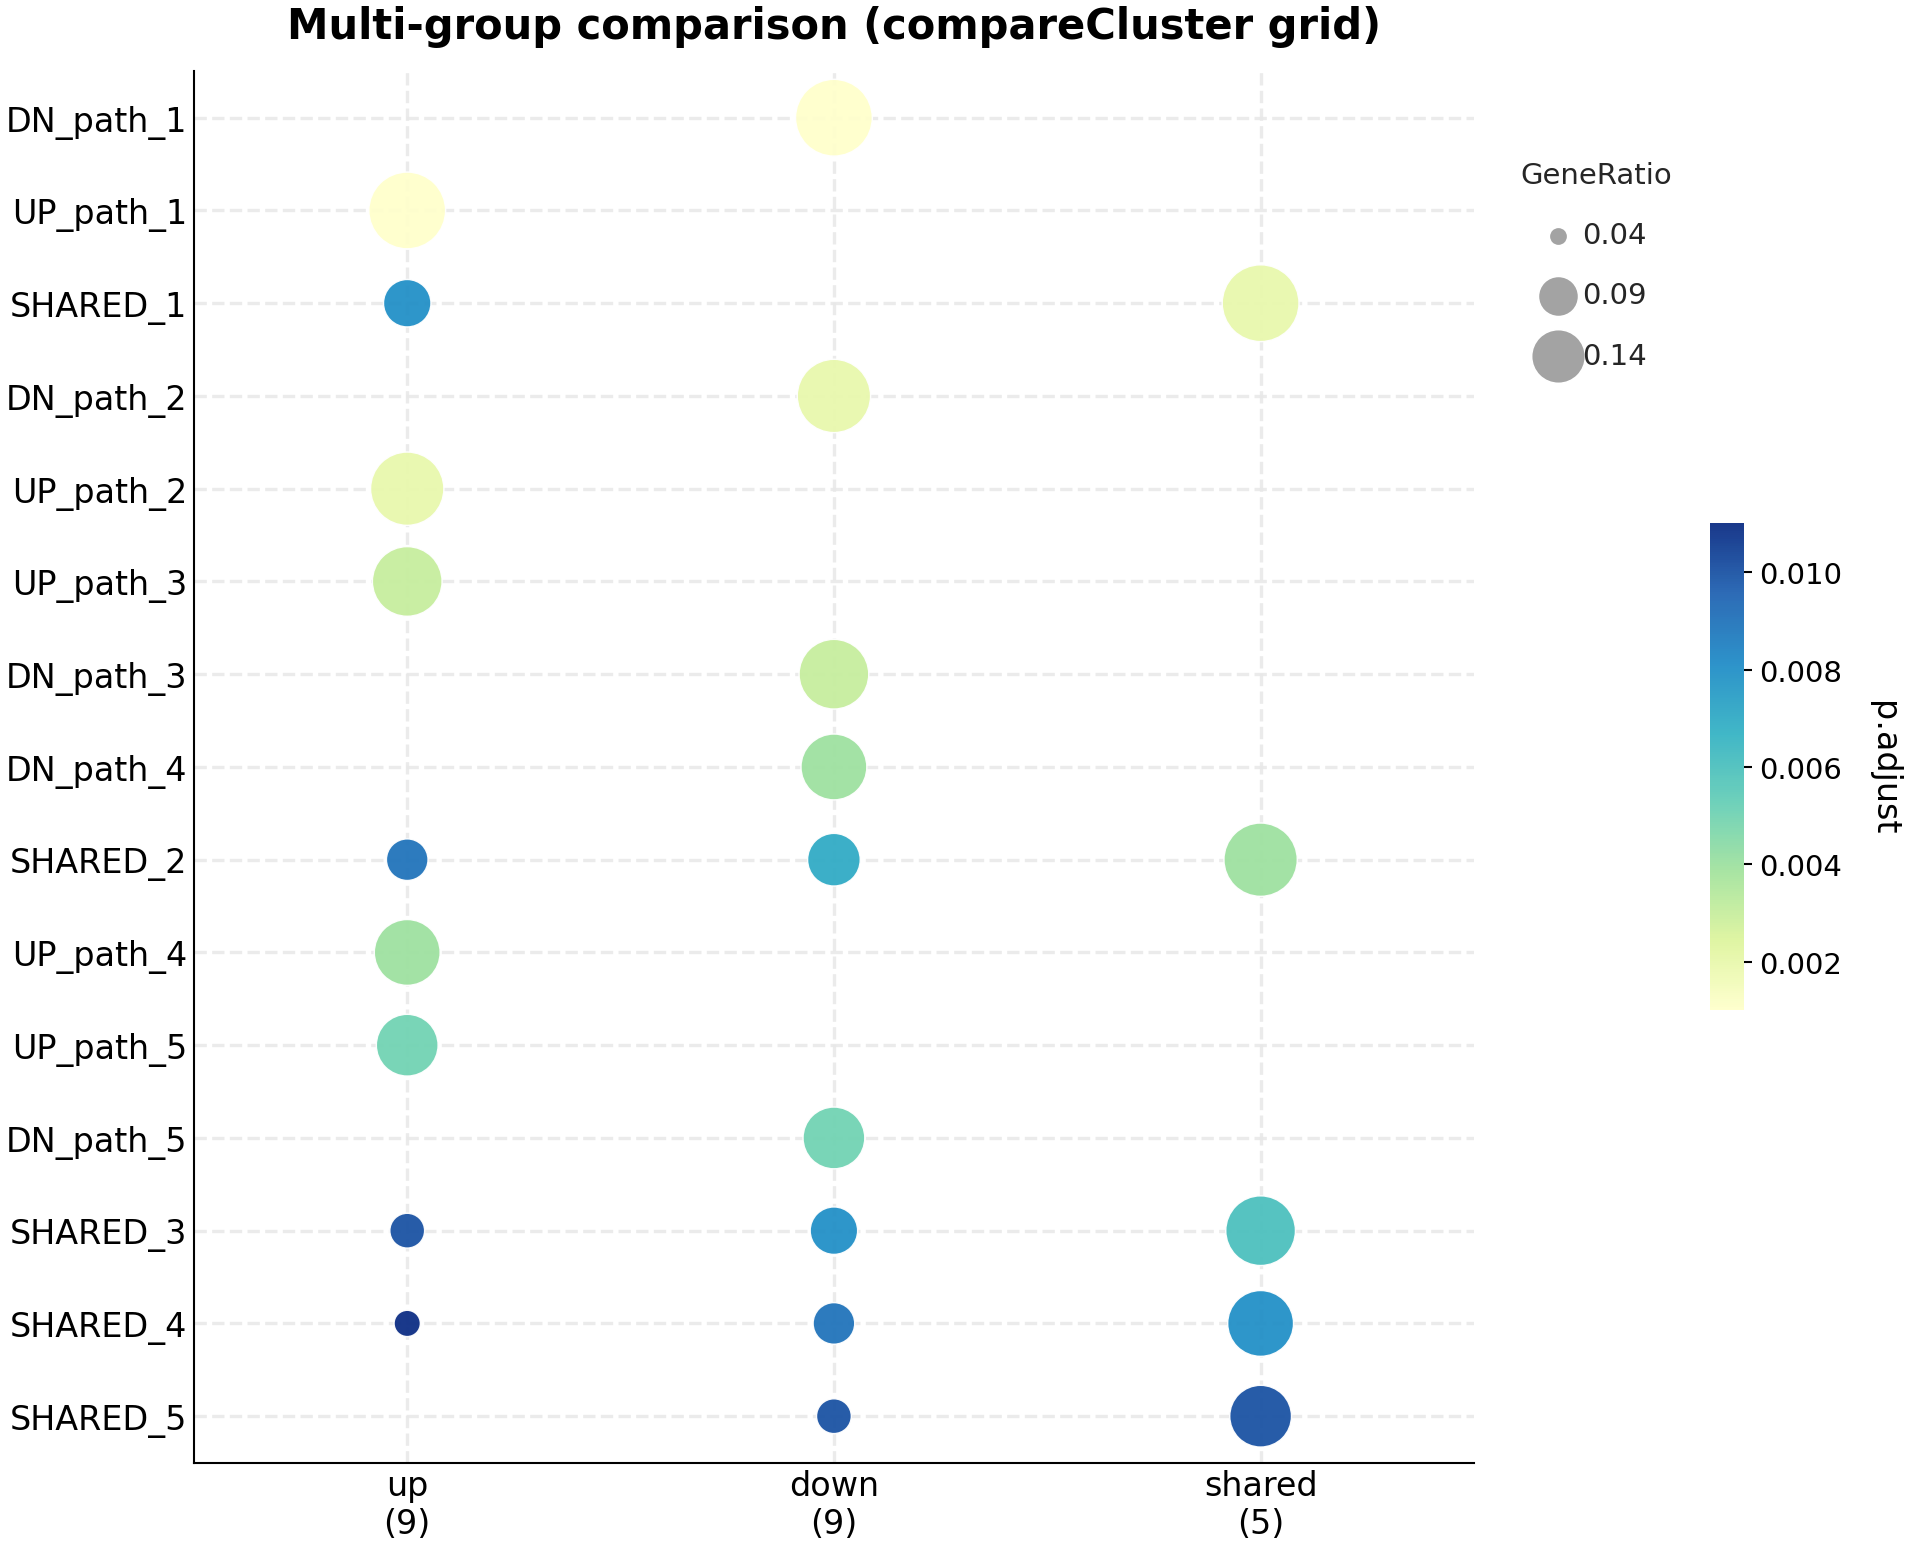

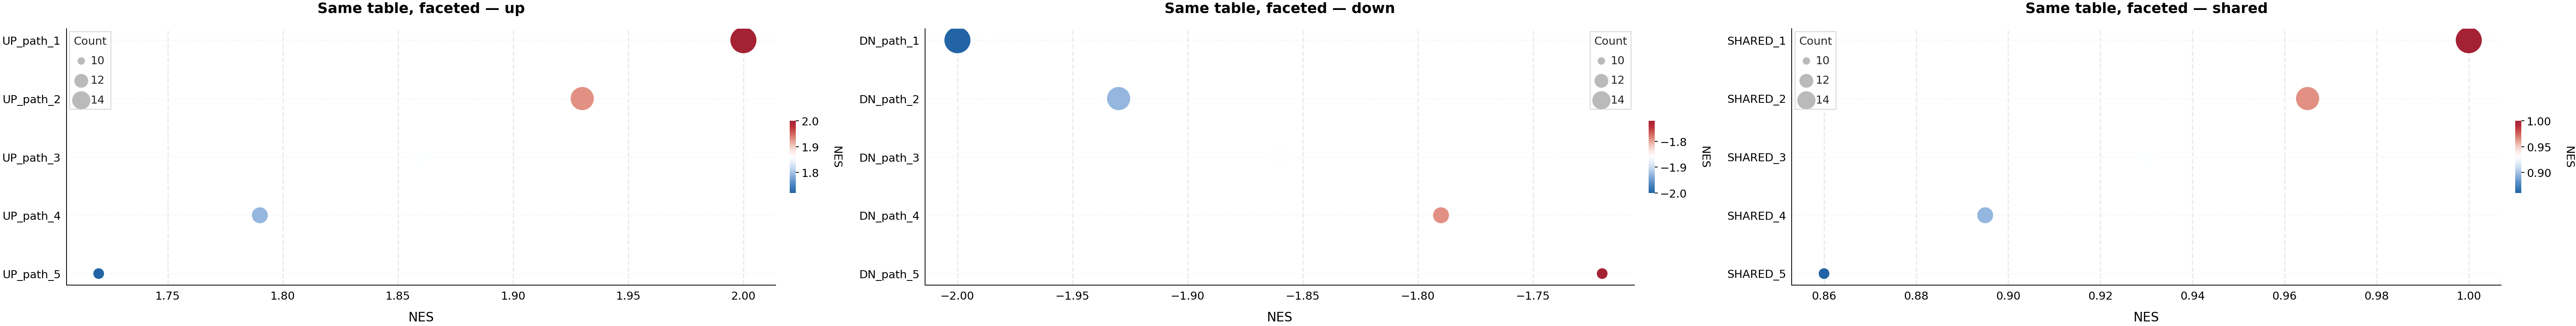

In [21]:
scat.pl.compare_dotplot(
    enrich_cmp,  # up / down / shared clusters (compare-style table)
    top_n=5,  # top terms per group
    cmap="scat_YlGnBu",
    title="Multi-group comparison (compareCluster grid)",
    figsize=(6.4, 5.2),
    dpi=150,
    fontsize=9,
)

scat.pl.enrich_dotplot(
    enrich_cmp,
    facet_by_cluster=True,
    top_n=5,
    title="Same table, faceted",
    fontsize=8,
    figsize=(9.0, 3.4),
    dpi=150,
    show=True,
);

### Multi-group term overlap (UpSet + Venn)

**What it answers:** Which enriched terms are unique vs shared across gene
lists / contrasts?

**Functions**: `enrich_upsetplot`, `enrich_vennplot`  
Input: compare-style table with a `Cluster` column (as from
`compare_enrichment` / `concat_compare_results`).

Recolor like `gene_upsetplot`: `set_color` / `intersection_color` /
`dot_color` on UpSet; `colors=` (one per group) on Venn.


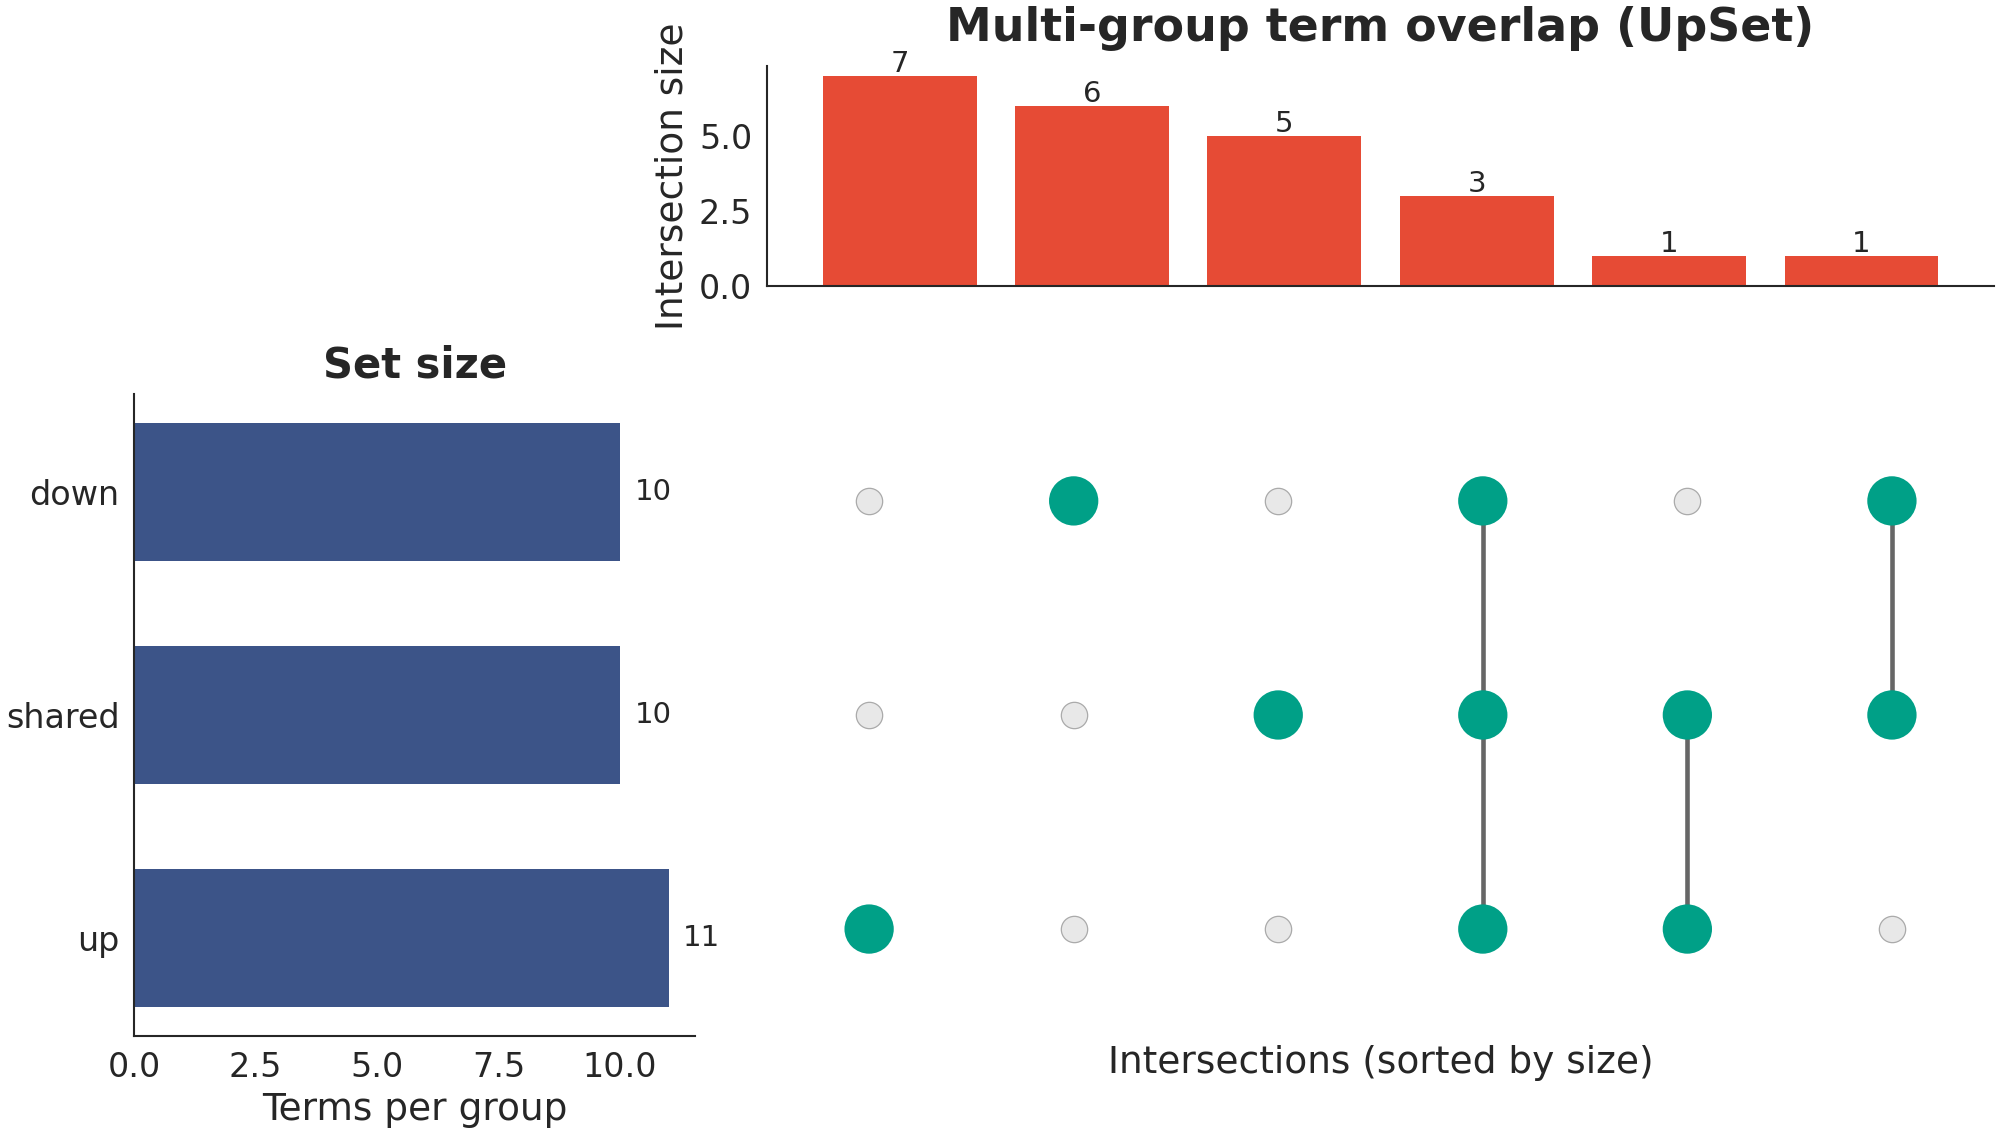

In [22]:
nat = scat.pl.palette("nature")
scat.pl.enrich_upsetplot(
    enrich_cmp,
    pval_cutoff=0.05,
    title="Multi-group term overlap (UpSet)",
    set_color=nat[3],
    intersection_color=nat[0],
    dot_color=nat[2],
    inactive_color="#E8E8E8",
    line_color="#666666",
    figsize=(8.0, 4.2),
    dpi=150,
    fontsize=9,
    show=True,
);

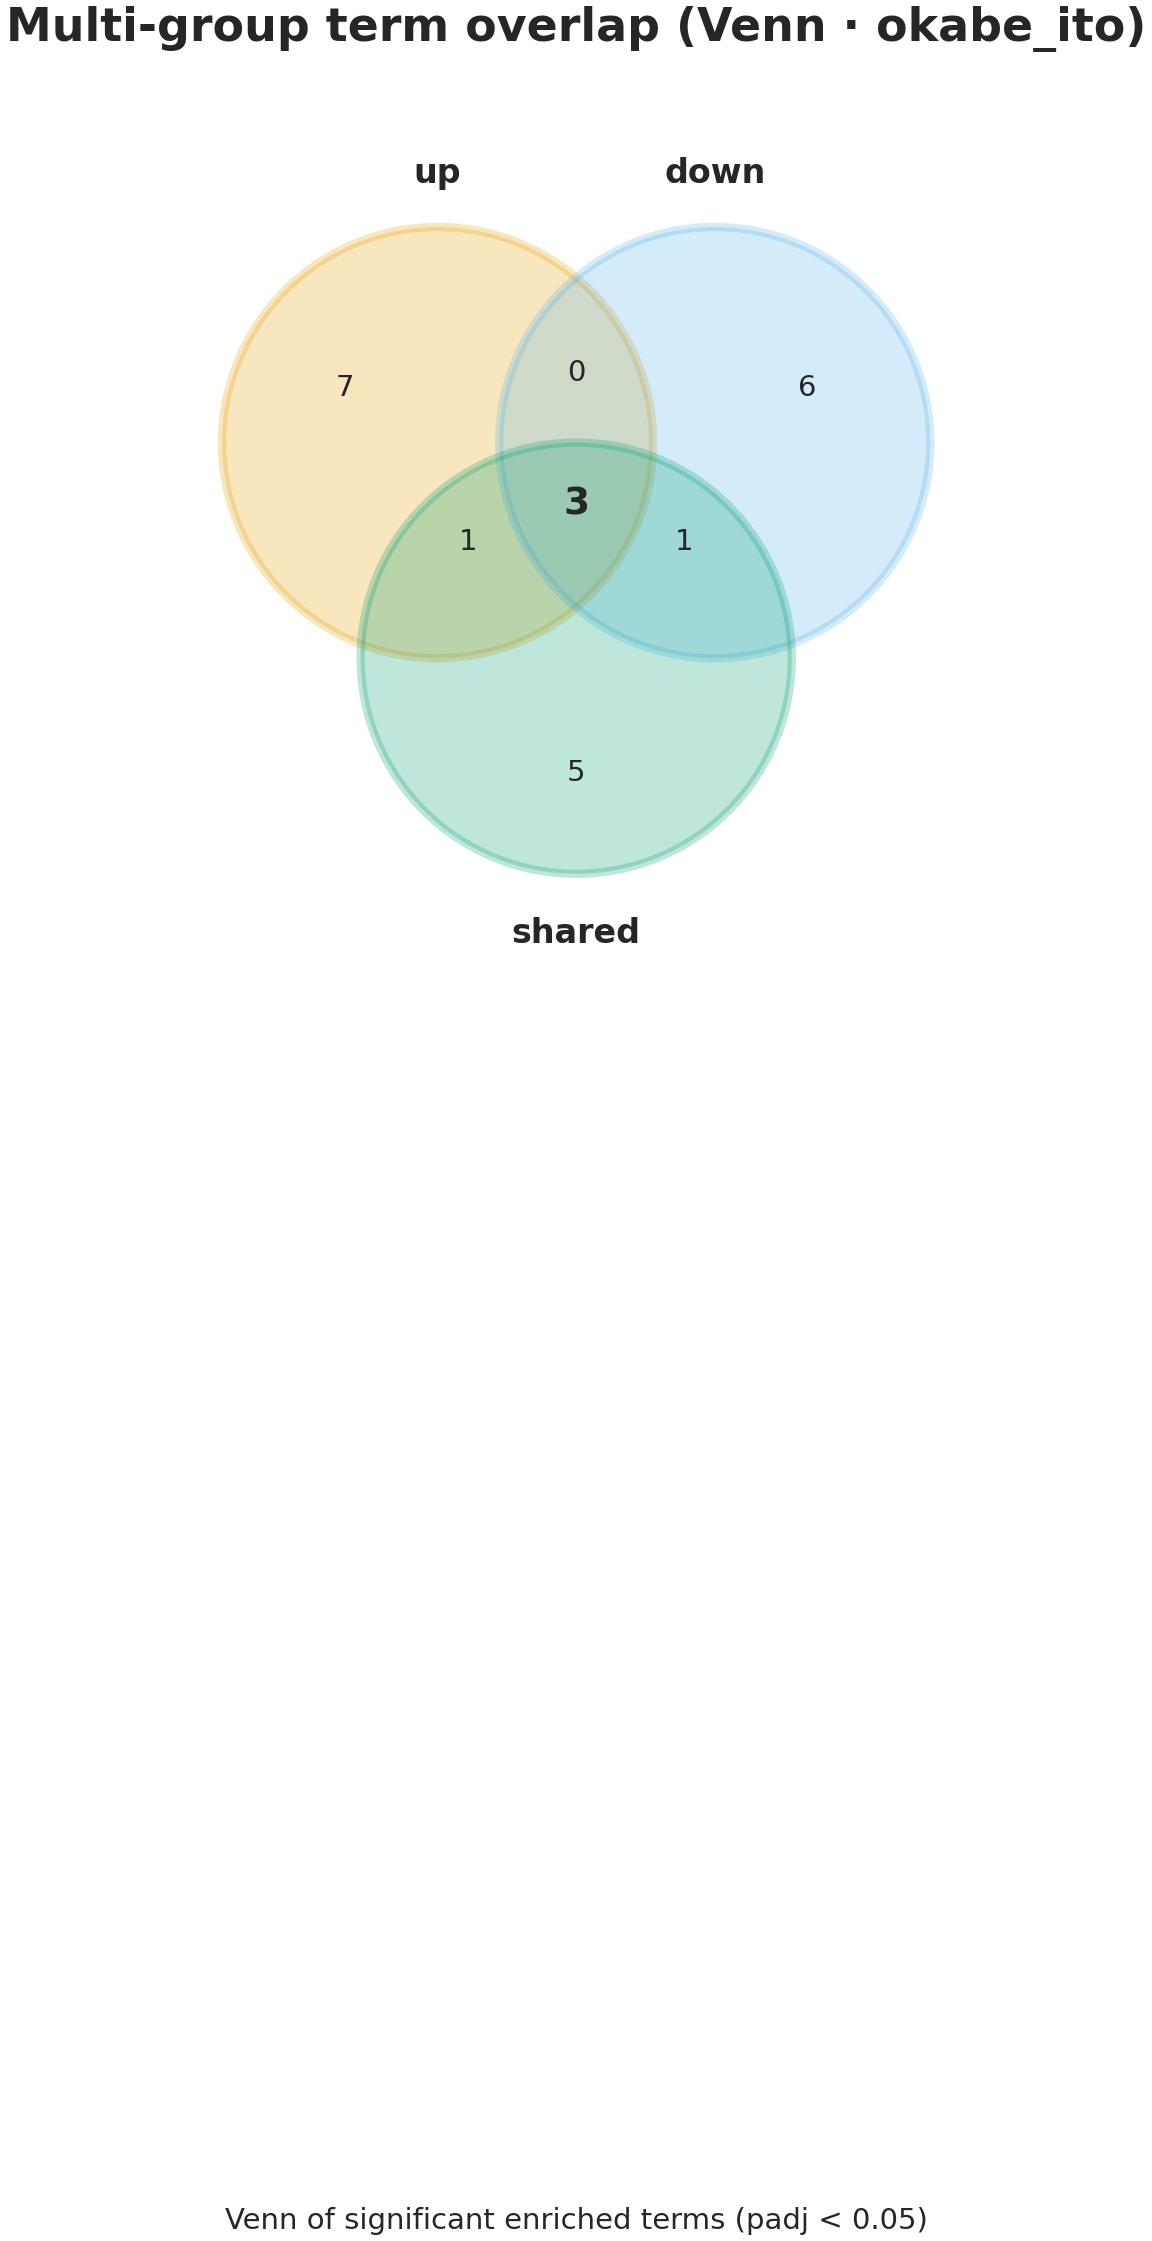

In [23]:
scat.pl.enrich_vennplot(
    enrich_cmp,
    pval_cutoff=0.05,
    colors=scat.pl.palette("okabe_ito", n=3),
    title="Multi-group term overlap (Venn · okabe_ito)",
    figsize=(5.0, 4.0),
    dpi=150,
    fontsize=9,
    show=True,
);

### Gene-level overlap (UpSet) + recoloring

**What it answers:** Which *genes* are called DE by several methods /
contrasts? Gene-level companion to the term-level `enrich_upsetplot` above.

**Functions**: `build_gene_membership`, `gene_upsetplot`, `common_genes`  
Input: a `{name: DataFrame}` dict where each table is indexed by gene with
`logFC` + `p_adj`/`p_val` — i.e. the `[1]` output of
`scat.differential_expression`, or any DE table you bring yourself
(see {doc}`t_ec_gene_upset` for the full gene-UpSet → enrichment walkthrough).

In [24]:
# Three DE-like tables over the same genes (mimic 3 methods/contrasts) by
# jittering logFC. In practice each is the [1] output of
# scat.differential_expression, or any gene-indexed DataFrame you already have.
rng = np.random.default_rng(0)


def _jitter(df, scale):
    out = df[["logFC", "p_adj"]].copy()
    out["logFC"] = out["logFC"] + rng.normal(0, scale, len(out))
    return out


de_tables = {
    "methodA": all_results[["logFC", "p_adj"]],
    "methodB": _jitter(all_results, 0.15),
    "methodC": _jitter(all_results, 0.30),
}
mem = scat.pl.build_gene_membership(
    de_tables,
    direction="separate",
    padj_cutoff=0.05,
    logfc_cutoff=0.35,
)
print("membership:", mem.shape, "| sets:", list(mem.columns))

membership: (437, 6) | sets: ['methodA::up', 'methodA::down', 'methodB::up', 'methodB::down', 'methodC::up', 'methodC::down']


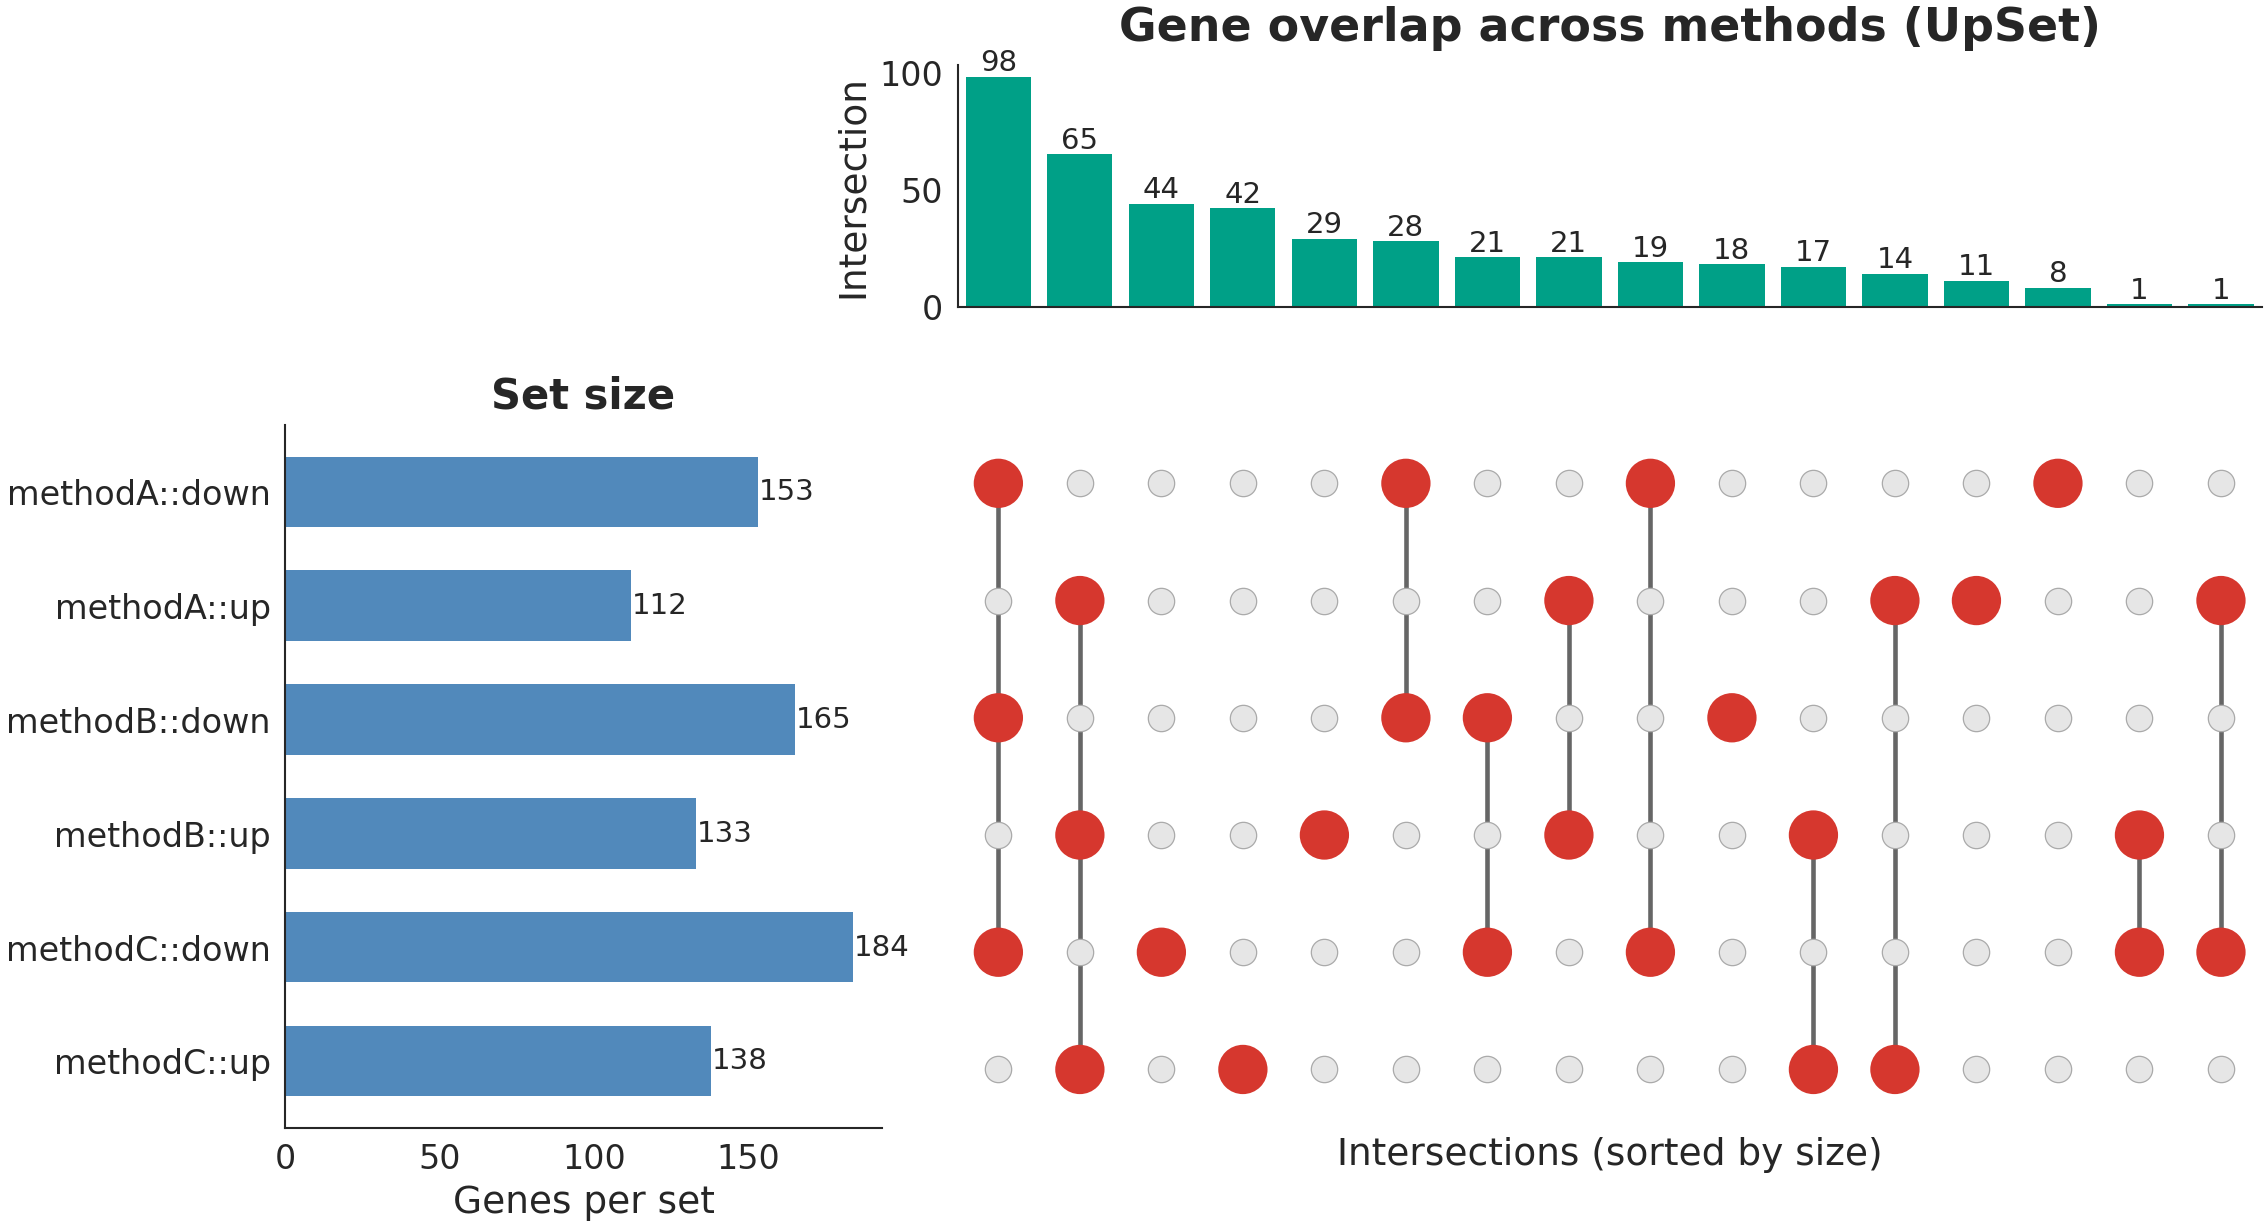

In [25]:
scat.pl.gene_upsetplot(
    membership=mem,
    title="Gene overlap across methods (UpSet)",
    figsize=(8.5, 4.6),
    dpi=150,
    fontsize=9,
    show=True,
);

**Variant — recolor every element.** `set_color`, `intersection_color`,
`dot_color`, `inactive_color` and `line_color` each take any matplotlib color;
`intersection_color` / `dot_color` also accept a **per-column list** to
highlight specific intersections. (These palette kwargs recur across the
`scat.pl` plots — e.g. `enrich_upsetplot` uses the same names.)

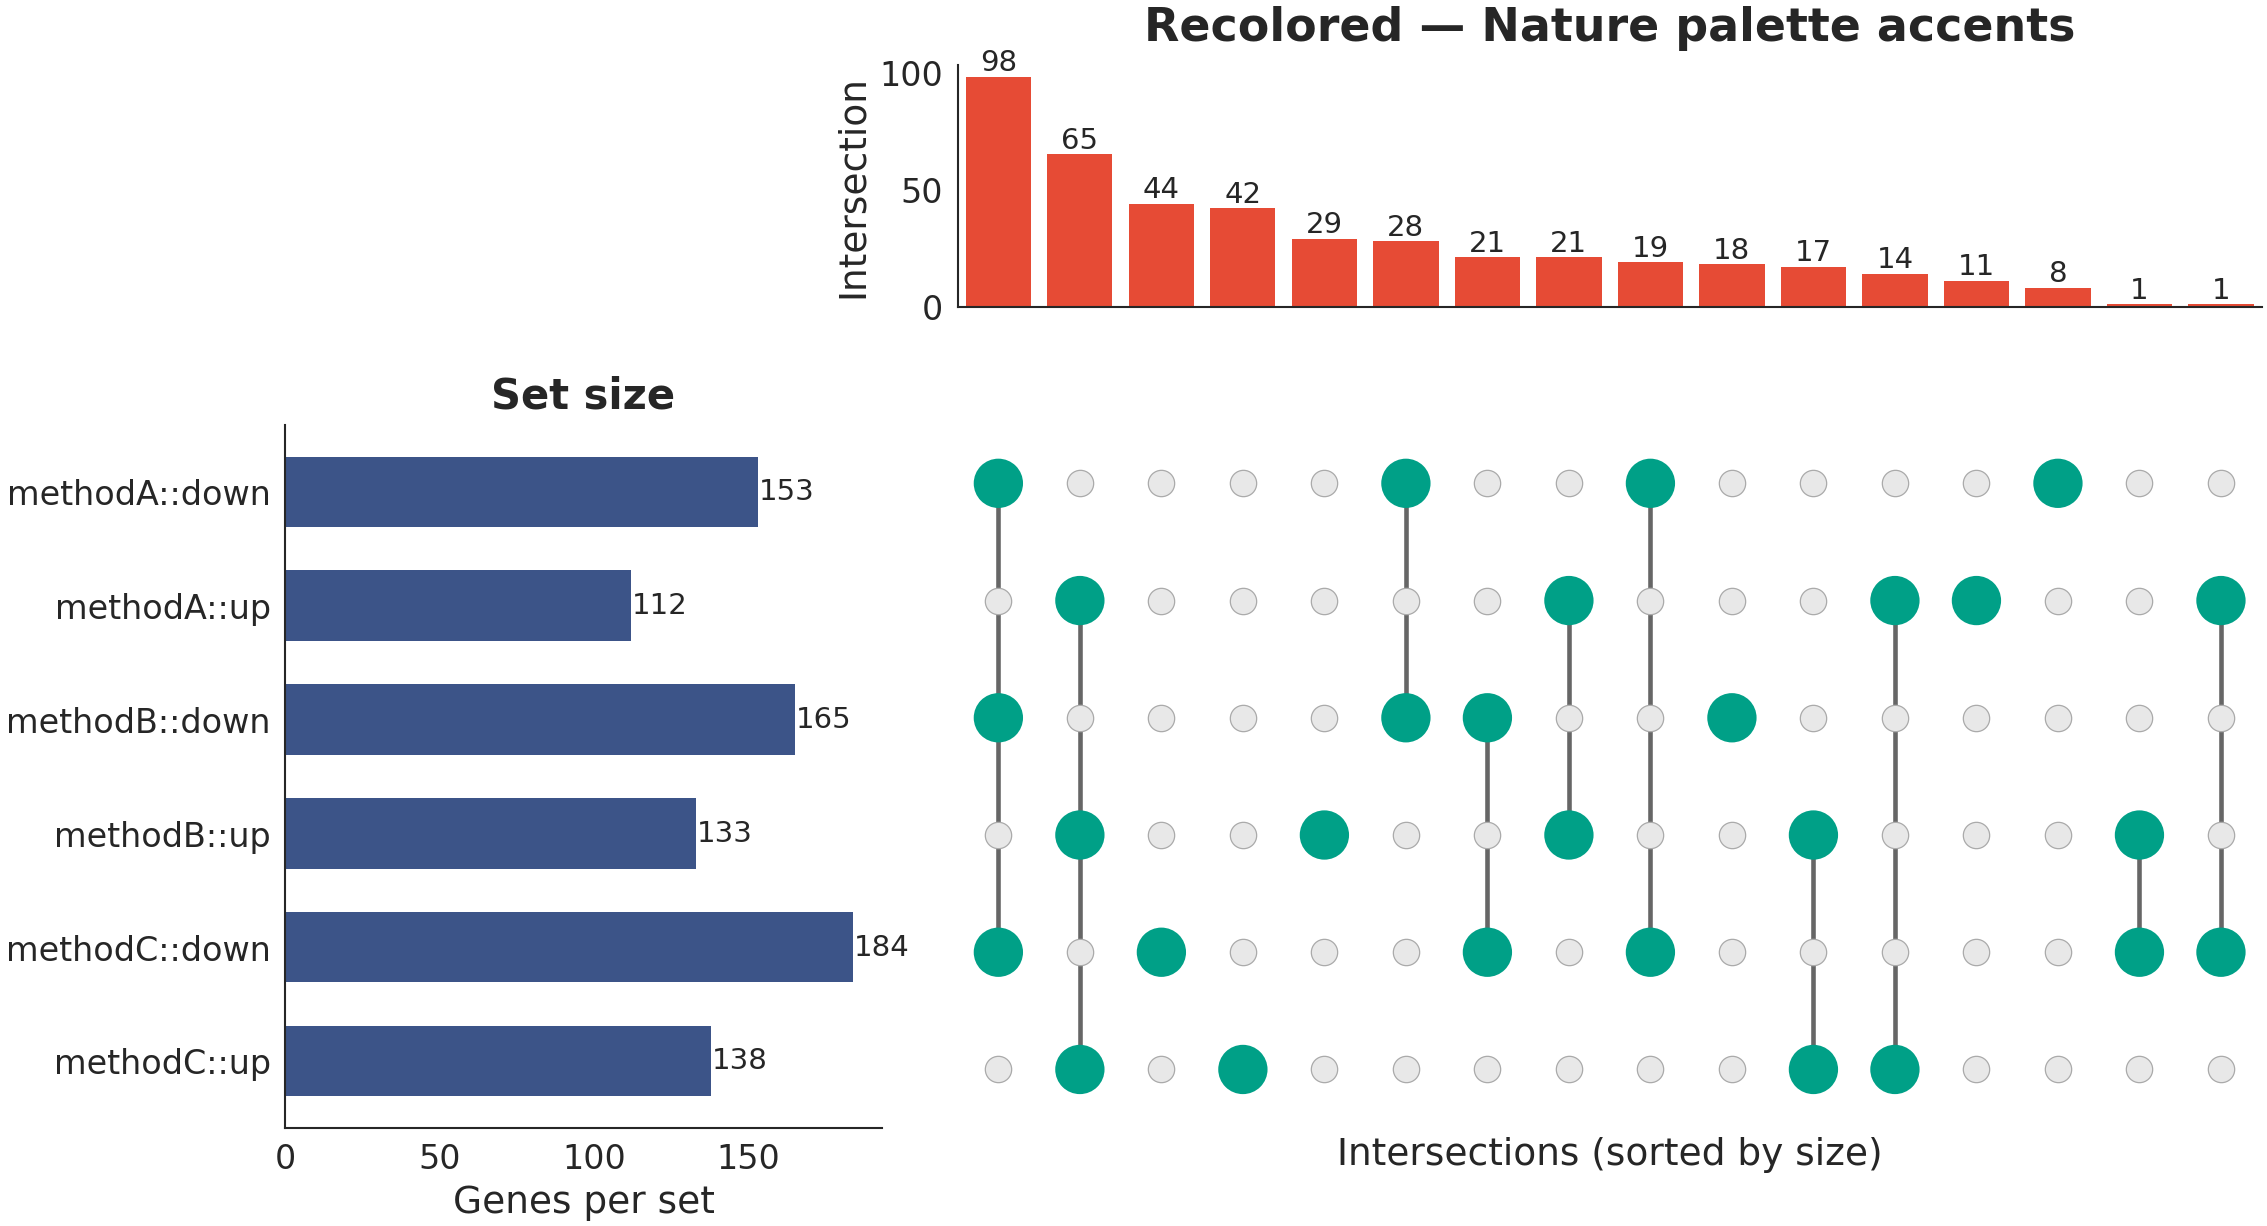

In [26]:
nat = scat.pl.palette("nature")
scat.pl.gene_upsetplot(
    membership=mem,
    title="Recolored — Nature palette accents",
    set_color=nat[3],  # deep blue-gray
    intersection_color=nat[0],  # red
    dot_color=nat[2],  # teal
    inactive_color="#E8E8E8",
    line_color="#666666",
    figsize=(8.5, 4.6),
    dpi=150,
    fontsize=9,
    show=True,
);

### GSEA running-sum

**Function**: `gseaplot` (+ in-memory `run_gsea`)
`color=` is the running-score curve; `cmap=` is the ranked-list bar
(default `scat_BuRd`).


In [27]:
ranked = all_results["logFC"].dropna().sort_values(ascending=False)
demo_set = {"Planted_up_set": list(ranked.index[:40])}
gsea_res = scat.run_gsea(
    ranked,
    gene_sets=demo_set,
    organism="mouse",
    nperm=100,
    min_size=10,
    max_size=80,
    verbose=False,
)
cols = [c for c in ("Term", "NES", "pvalue", "p.adjust") if c in gsea_res.columns]
print(gsea_res[cols].head() if len(gsea_res) else gsea_res)
if len(gsea_res) > 0:
    scat.pl.gseaplot(
        ranked,
        gsea_result=gsea_res,
        term=str(gsea_res.sort_values("p.adjust").iloc[0]["Term"]),
        color=scat.pl.TEAL,
        cmap="scat_BuRd",
        title="gseaplot · TEAL + scat_BuRd",
        figsize=(5.2, 4.2),
        dpi=150,
        show=True,
    )
else:
    print("GSEA empty; skip.")

Empty DataFrame
Columns: [Term, Description, ES, NES, pvalue, p.adjust, neg_log10_padj, leading_edge, Tag_percent, Gene_percent, TermSize]
Index: []
GSEA empty; skip.


/home/lieber/scATrans-main/src/scatrans/enrich/_data.py:417: UserWarning: Low mapping rate (2.7%) in run_gsea (40/1500 input genes found in gene sets / universe). Input examples: ['G0036', 'G0014', 'G0007', 'G0001', 'G0039']; gene-set/universe examples: ['G0036', 'G0039', 'G0038', 'G0000', 'G0006']. gene_case is None (literal match only). Check gene ID type, organism, and gene_case (Enrichr libraries are typically UPPERCASE symbols — try gene_case='upper' for mixed-case mouse/human symbols such as Tp53).
  _warn_user(
/tmp/ipykernel_1047758/487283562.py:3: RuntimeWarning: gseapy.prerank failed: prerank() got an unexpected keyword argument 'threads' (ranked=1500, overlap_with_gene_sets=40, mapping_rate=2.7%, gene_case=None). If overlap is low, check gene_case/organism (Enrichr uses UPPERCASE symbols).
  gsea_res = scat.run_gsea(


## 7. Group comparisons, mechanism plots, and enrichment network (new in 0.10.16)

**Functions**: `compare_de_across_groups` + `pl.de_summary_barplot`,
`pl.group_stat_plot`, `pl.composition_barplot`, `pl.enrich_network_plot`, and
the global `pl.set_vector_friendly` export toggle.

### Vector-friendly export (on by default)

Dense scatter clouds (volcano, comet, 3D volcano, bias/gamma diagnostics,
phase portraits, the network plot below) are rasterized to a high-resolution
bitmap layer when saved as PDF/SVG/EPS, while axes, legends, colorbars, and
every text label stay real editable vector content — same trick as scanpy's
`settings._vector_friendly`. This does not change on-screen `show=True`
rendering, only vector file export.

In [28]:
print("vector-friendly (default):", scat.pl.get_vector_friendly())

fig, ax = scat.pl.volcano_plot(all_results, style="ggvolcano", show=False, **VOLC)
print("scatter rasterized on export:", ax.collections[0].get_rasterized())
plt.close(fig)

with scat.pl.vector_friendly_context(False):
    fig, ax = scat.pl.volcano_plot(all_results, style="ggvolcano", show=False, **VOLC)
    print("inside vector_friendly_context(False):", ax.collections[0].get_rasterized())
    plt.close(fig)

print("back to default:", scat.pl.get_vector_friendly())

vector-friendly (default): True


scatter rasterized on export: True


inside vector_friendly_context(False): False
back to default: True


### `compare_de_across_groups` + `de_summary_barplot`

Run the same `condition` contrast independently within synthetic `cell_type`
groups (3 pretend clusters here) and compare up/down-regulated gene counts.

        up  down  total
group                  
Astro   85   109    194
Micro   99   119    218
Neuron  95   119    214
failed: {}


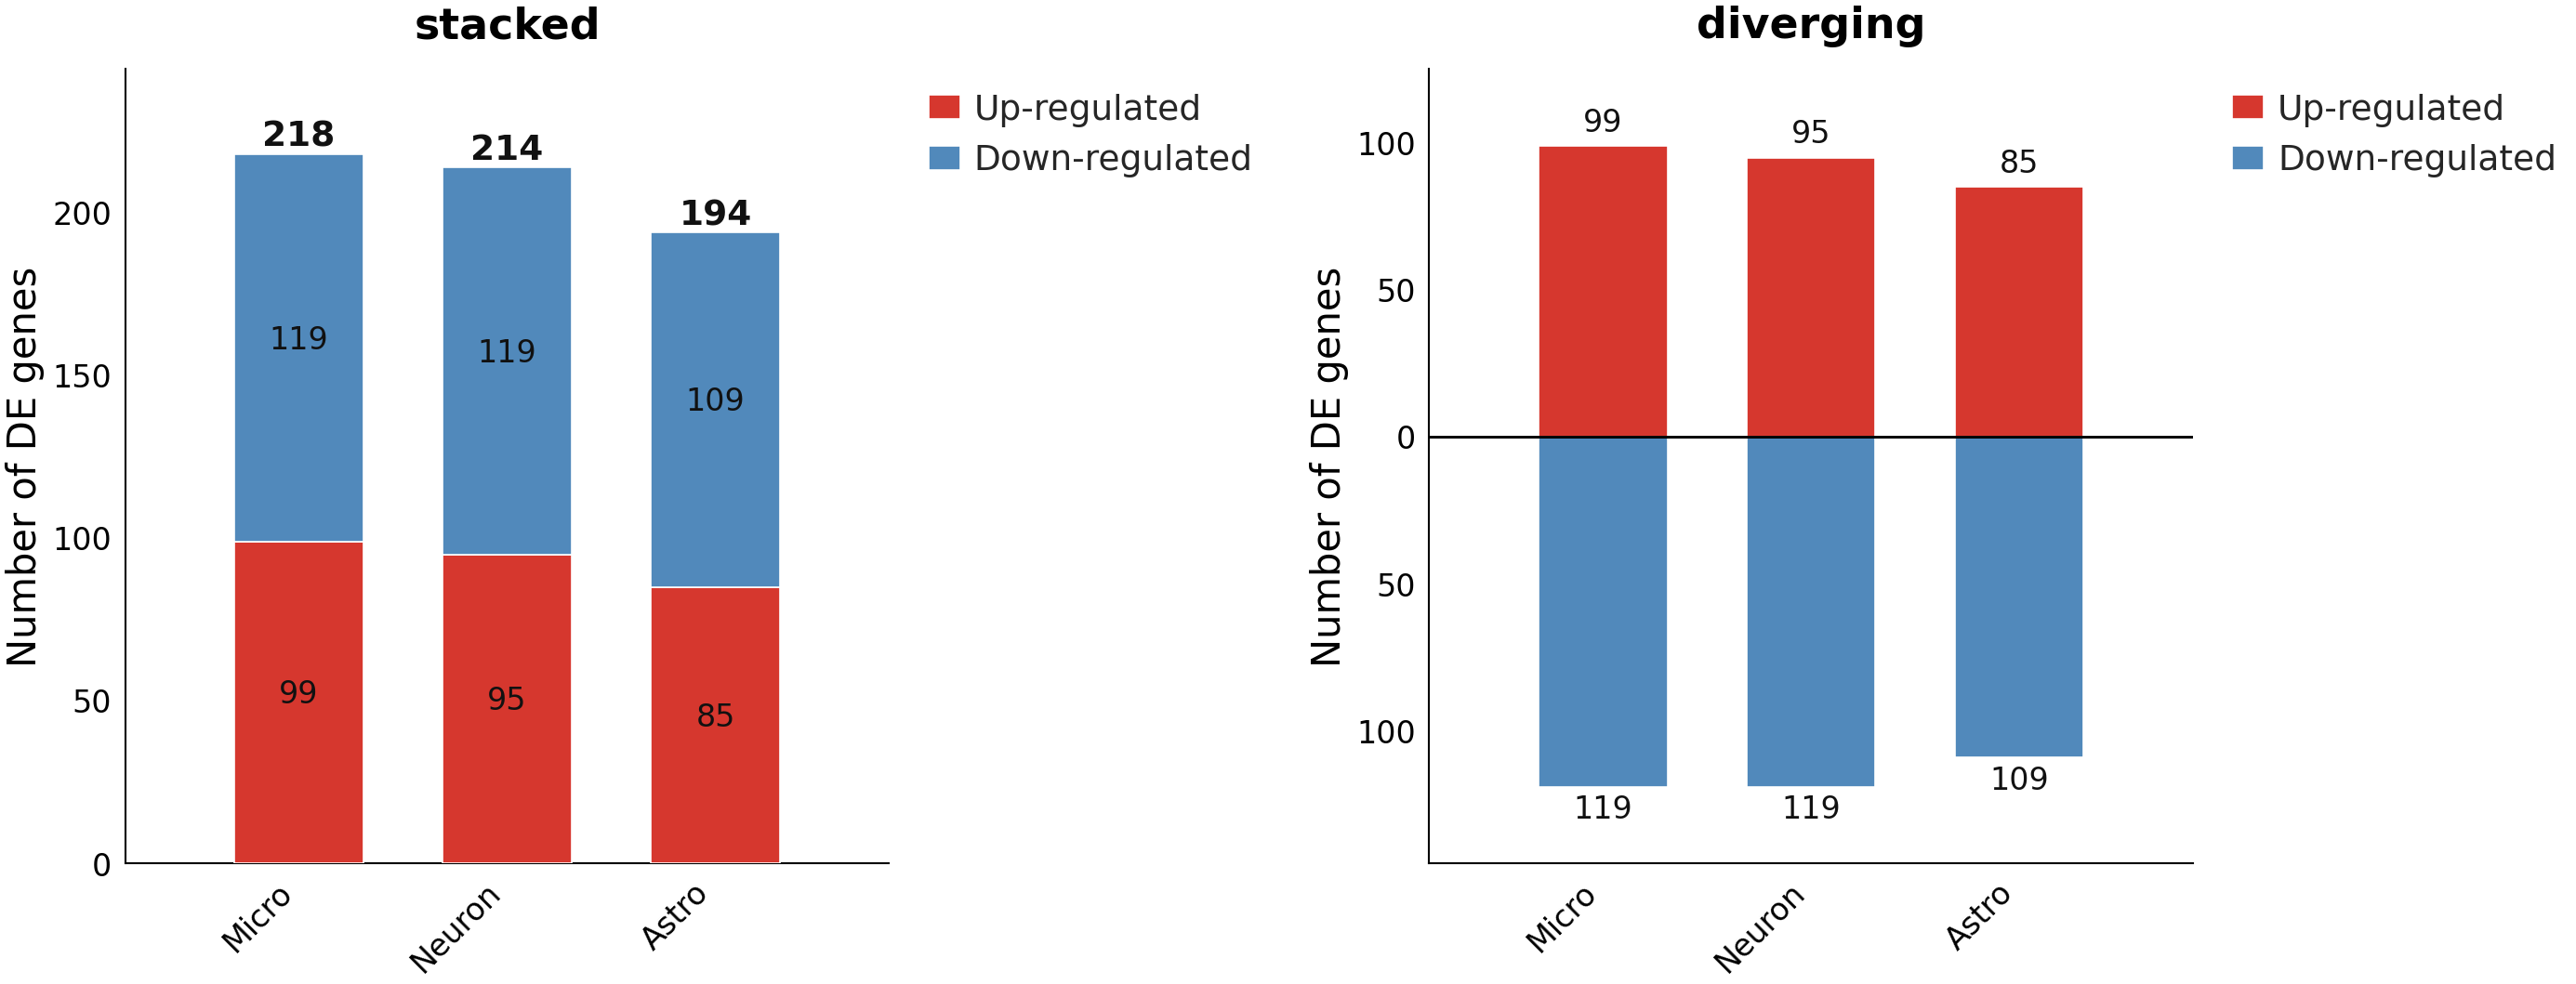

In [29]:
# Pretend cluster labels, independent of condition, so each cell_type keeps
# a roughly balanced Disease/Control split.
rng = np.random.default_rng(1)
adata_res.obs["cell_type"] = pd.Categorical(
    rng.choice(["Neuron", "Astro", "Micro"], size=adata_res.n_obs)
)

cmp = scat.compare_de_across_groups(
    adata_res,
    split_by="cell_type",
    groupby="condition",
    target_group="Disease",
    reference_group="Control",
    de_kwargs={"de_method": "wilcoxon"},
    padj_cutoff=0.05,
    logfc_cutoff=0.35,
)
print(cmp.summary)
print("failed:", cmp.failed)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), dpi=150)
scat.pl.de_summary_barplot(
    cmp, mode="stacked", sort_by="total", title="stacked", ax=axes[0], show=False
)
scat.pl.de_summary_barplot(
    cmp, mode="diverging", sort_by="total", title="diverging", ax=axes[1], show=False
)
plt.tight_layout()
plt.show()

### `group_stat_plot` — score by group, with significance brackets

Compare `unspliced_excess_residual` across `mechanism_class` labels (from
`annotate_mechanism_class` on the genome-wide `all_results` table, computed
above for the heatmap variant). Colors default to `pl.MECHANISM_CLASS_COLORS`
automatically. Mann-Whitney U by default; multiple comparisons get BH-FDR
correction.

mechanism_class
unclassified_down       748
stabilization-driven    417
ambiguous               274
transcription-driven     61
Name: count, dtype: int64


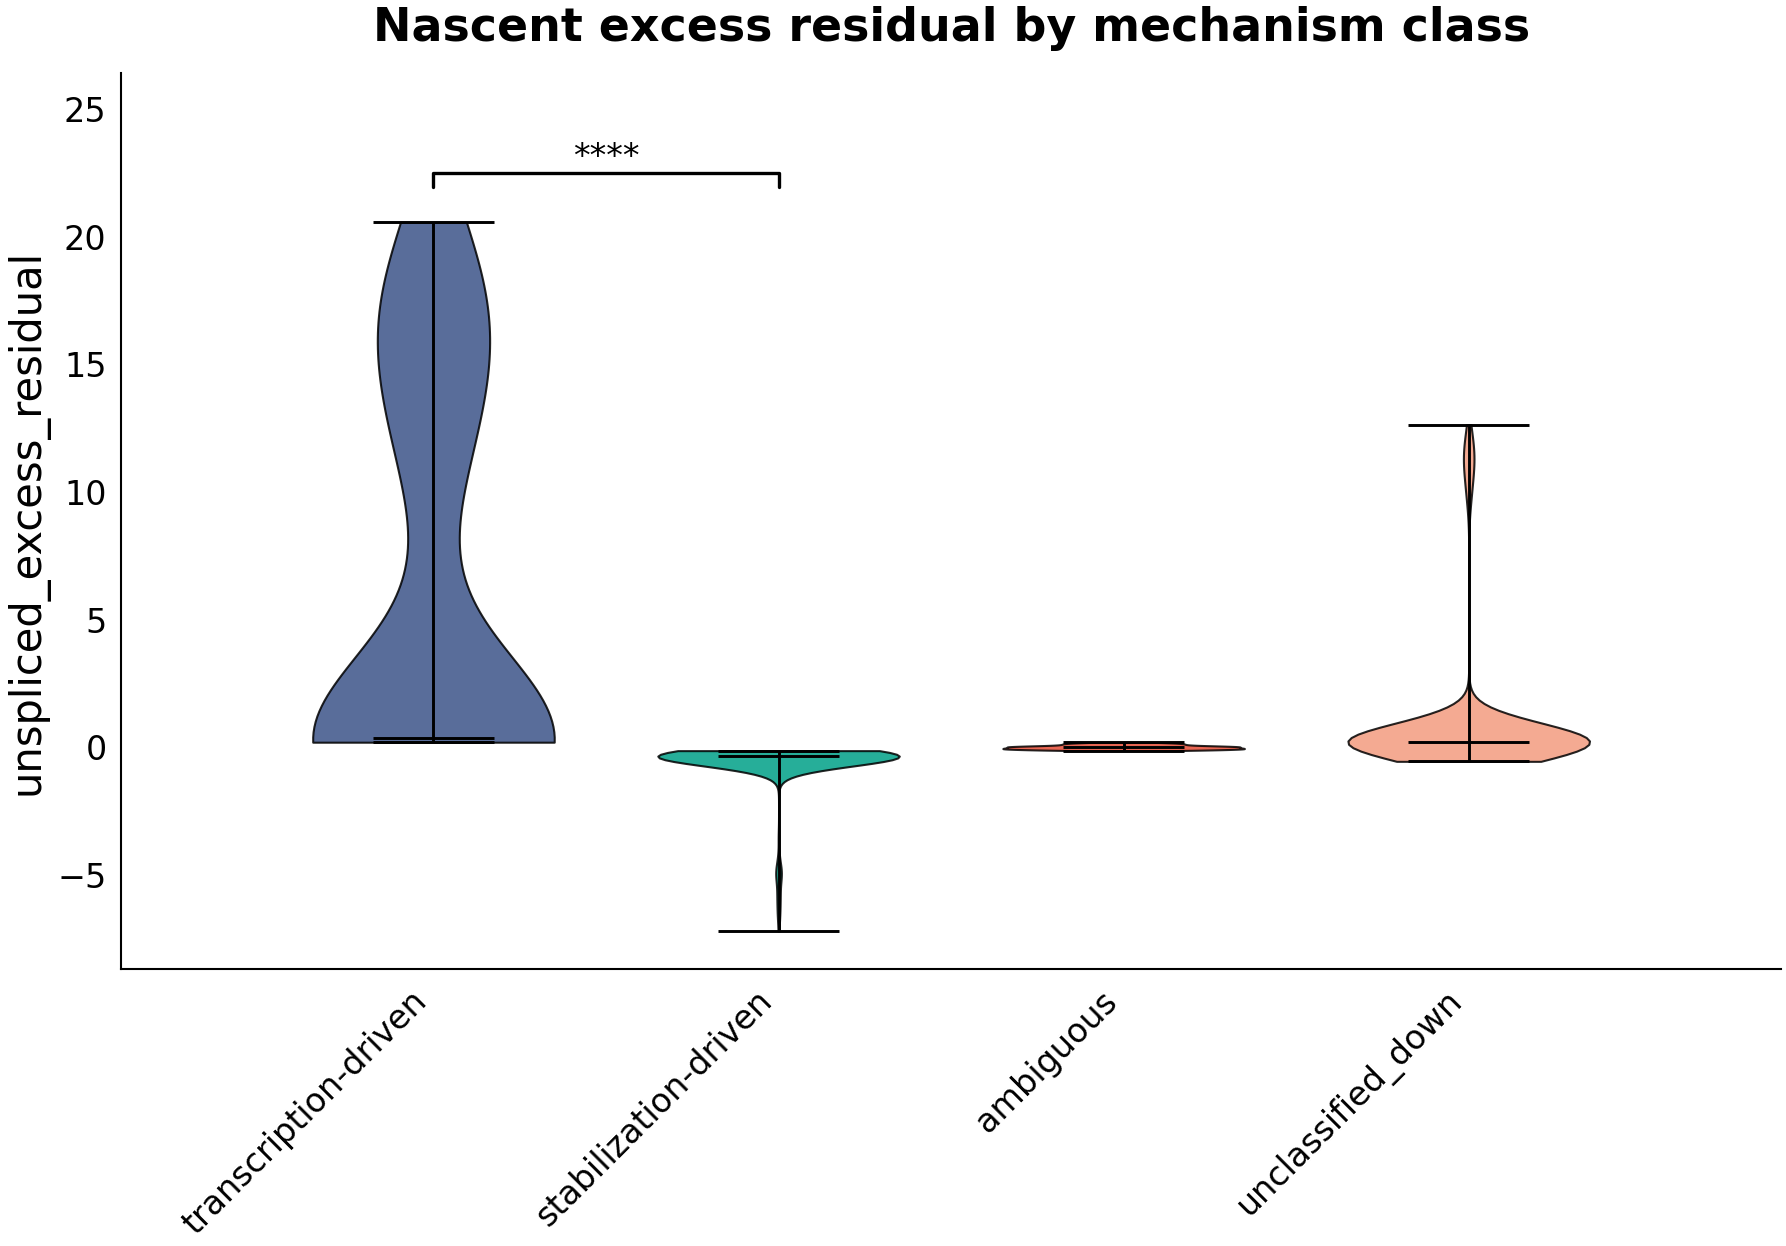

In [30]:
mech_counts = all_results_mech["mechanism_class"].value_counts()
print(mech_counts)

# Compare the two best-populated "up" mechanism classes, whichever they are.
candidates = [
    c for c in ("transcription-driven", "stabilization-driven", "ambiguous") if mech_counts.get(c, 0) >= 5
]
order = candidates + [c for c in mech_counts.index if c not in candidates]
comparisons = [(candidates[0], candidates[1])] if len(candidates) >= 2 else None

scat.pl.group_stat_plot(
    all_results_mech,
    value_col="unspliced_excess_residual",
    groupby="mechanism_class",
    order=order,
    kind="violin",
    comparisons=comparisons,
    title="Nascent excess residual by mechanism class",
    figsize=(6.0, 4.2),
    dpi=150,
    show=True,
);

### `composition_barplot` — mechanism composition by regulation direction

100%-stacked share of each `mechanism_class` among up- / down- / non-significant
genes (same `padj`/`logFC` cutoffs as the volcano panels above). Down genes
are expected to land mostly in `unclassified_down` — `annotate_mechanism_class`
only classifies transcription- vs. stabilization-driven for **up**-regulated
genes (the validated contrast direction).

regulation  mechanism_class     
down        unclassified_down       153
ns          ambiguous               270
            stabilization-driven    330
            transcription-driven     40
            unclassified_down       595
up          ambiguous                 4
            stabilization-driven     87
            transcription-driven     21
dtype: int64


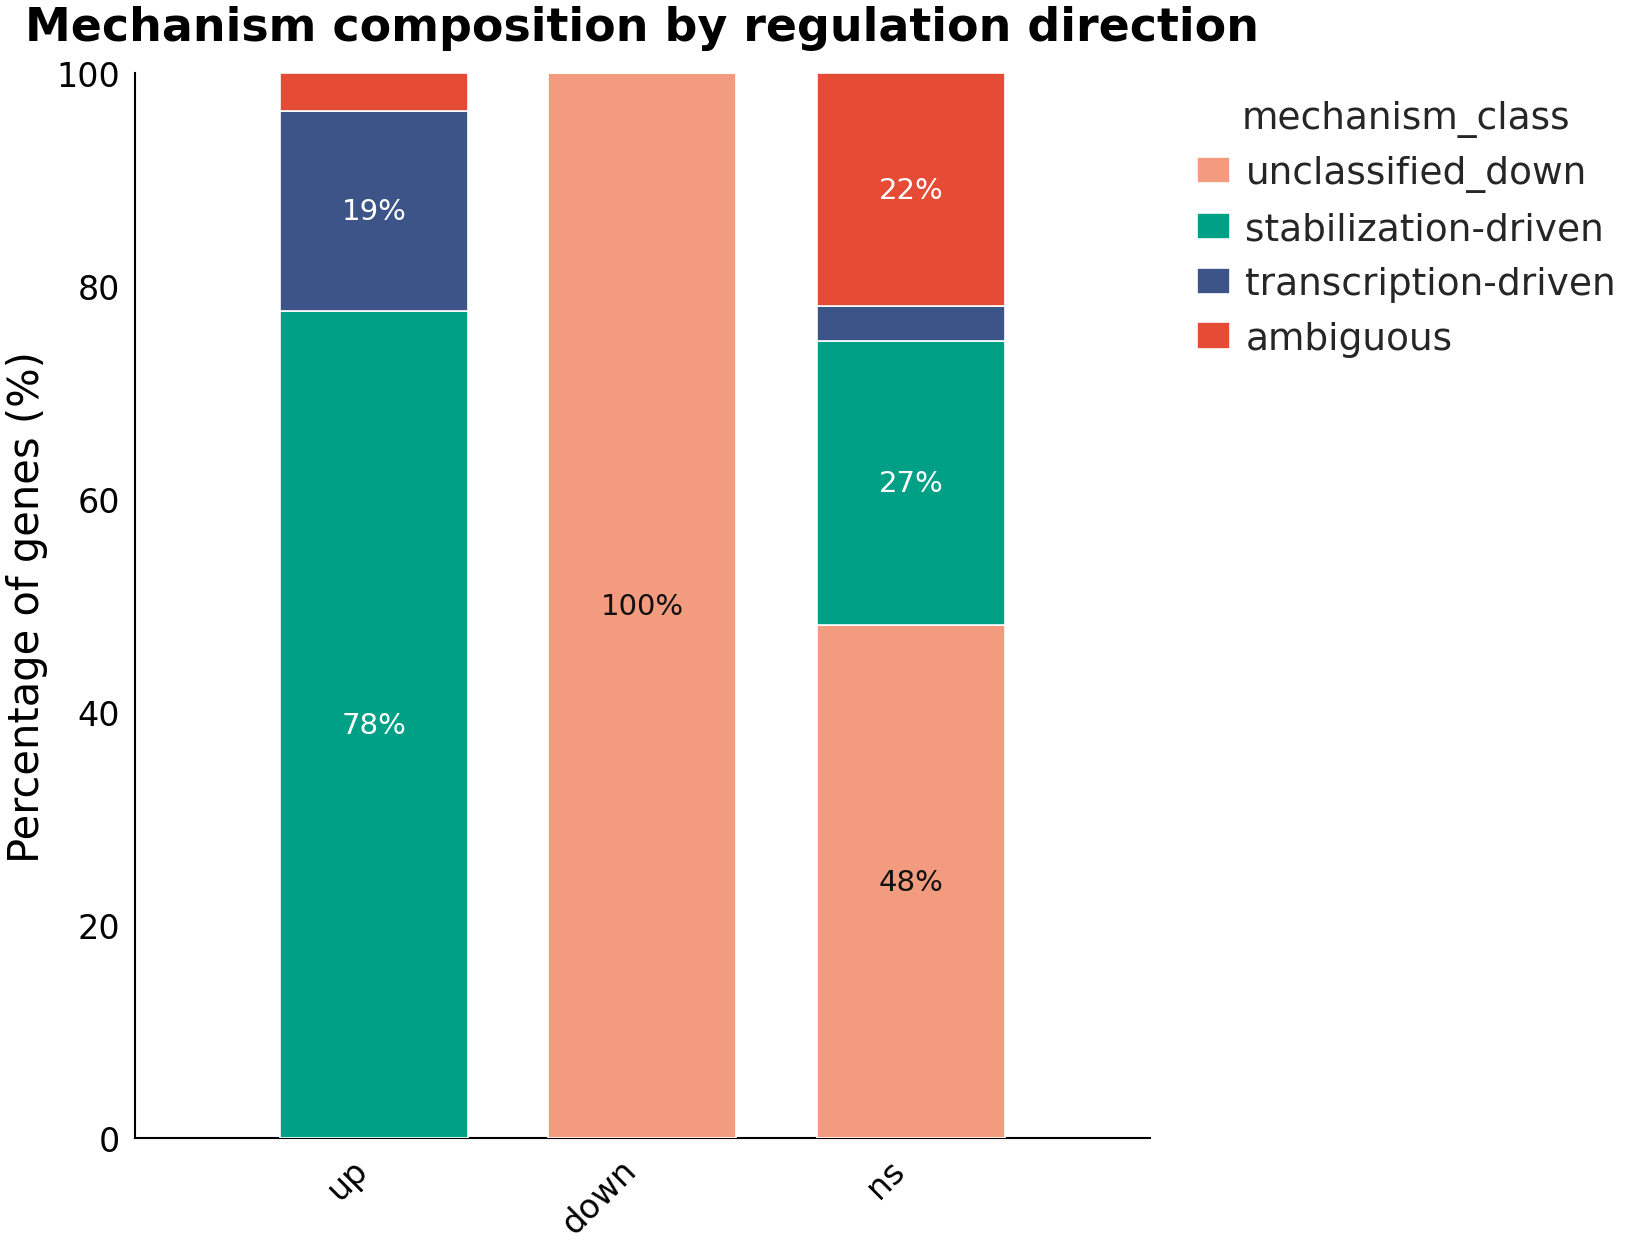

In [31]:
reg = pd.Series("ns", index=all_results_mech.index)
reg[(all_results_mech["logFC"] > 0.35) & (all_results_mech["p_adj"] < 0.05)] = "up"
reg[(all_results_mech["logFC"] < -0.35) & (all_results_mech["p_adj"] < 0.05)] = "down"
comp_df = all_results_mech.assign(regulation=reg)
print(comp_df.groupby(["regulation", "mechanism_class"], observed=True).size())

scat.pl.composition_barplot(
    comp_df,
    groupby="regulation",
    hue="mechanism_class",
    order=["up", "down", "ns"],
    show_values=True,
    title="Mechanism composition by regulation direction",
    figsize=(5.5, 4.2),
    dpi=150,
    show=True,
);

### `enrich_network_plot` — enrichment map

A dedicated mock table with **overlapping gene sets across a few term
"families"** (the `enrich_up`/`enrich_cmp` tables above all share one
5-gene list, which would make every edge weight 1.0 — not a useful network
demo). Terms sharing more genes cluster together; `min_similarity` controls
how sparse the graph is.

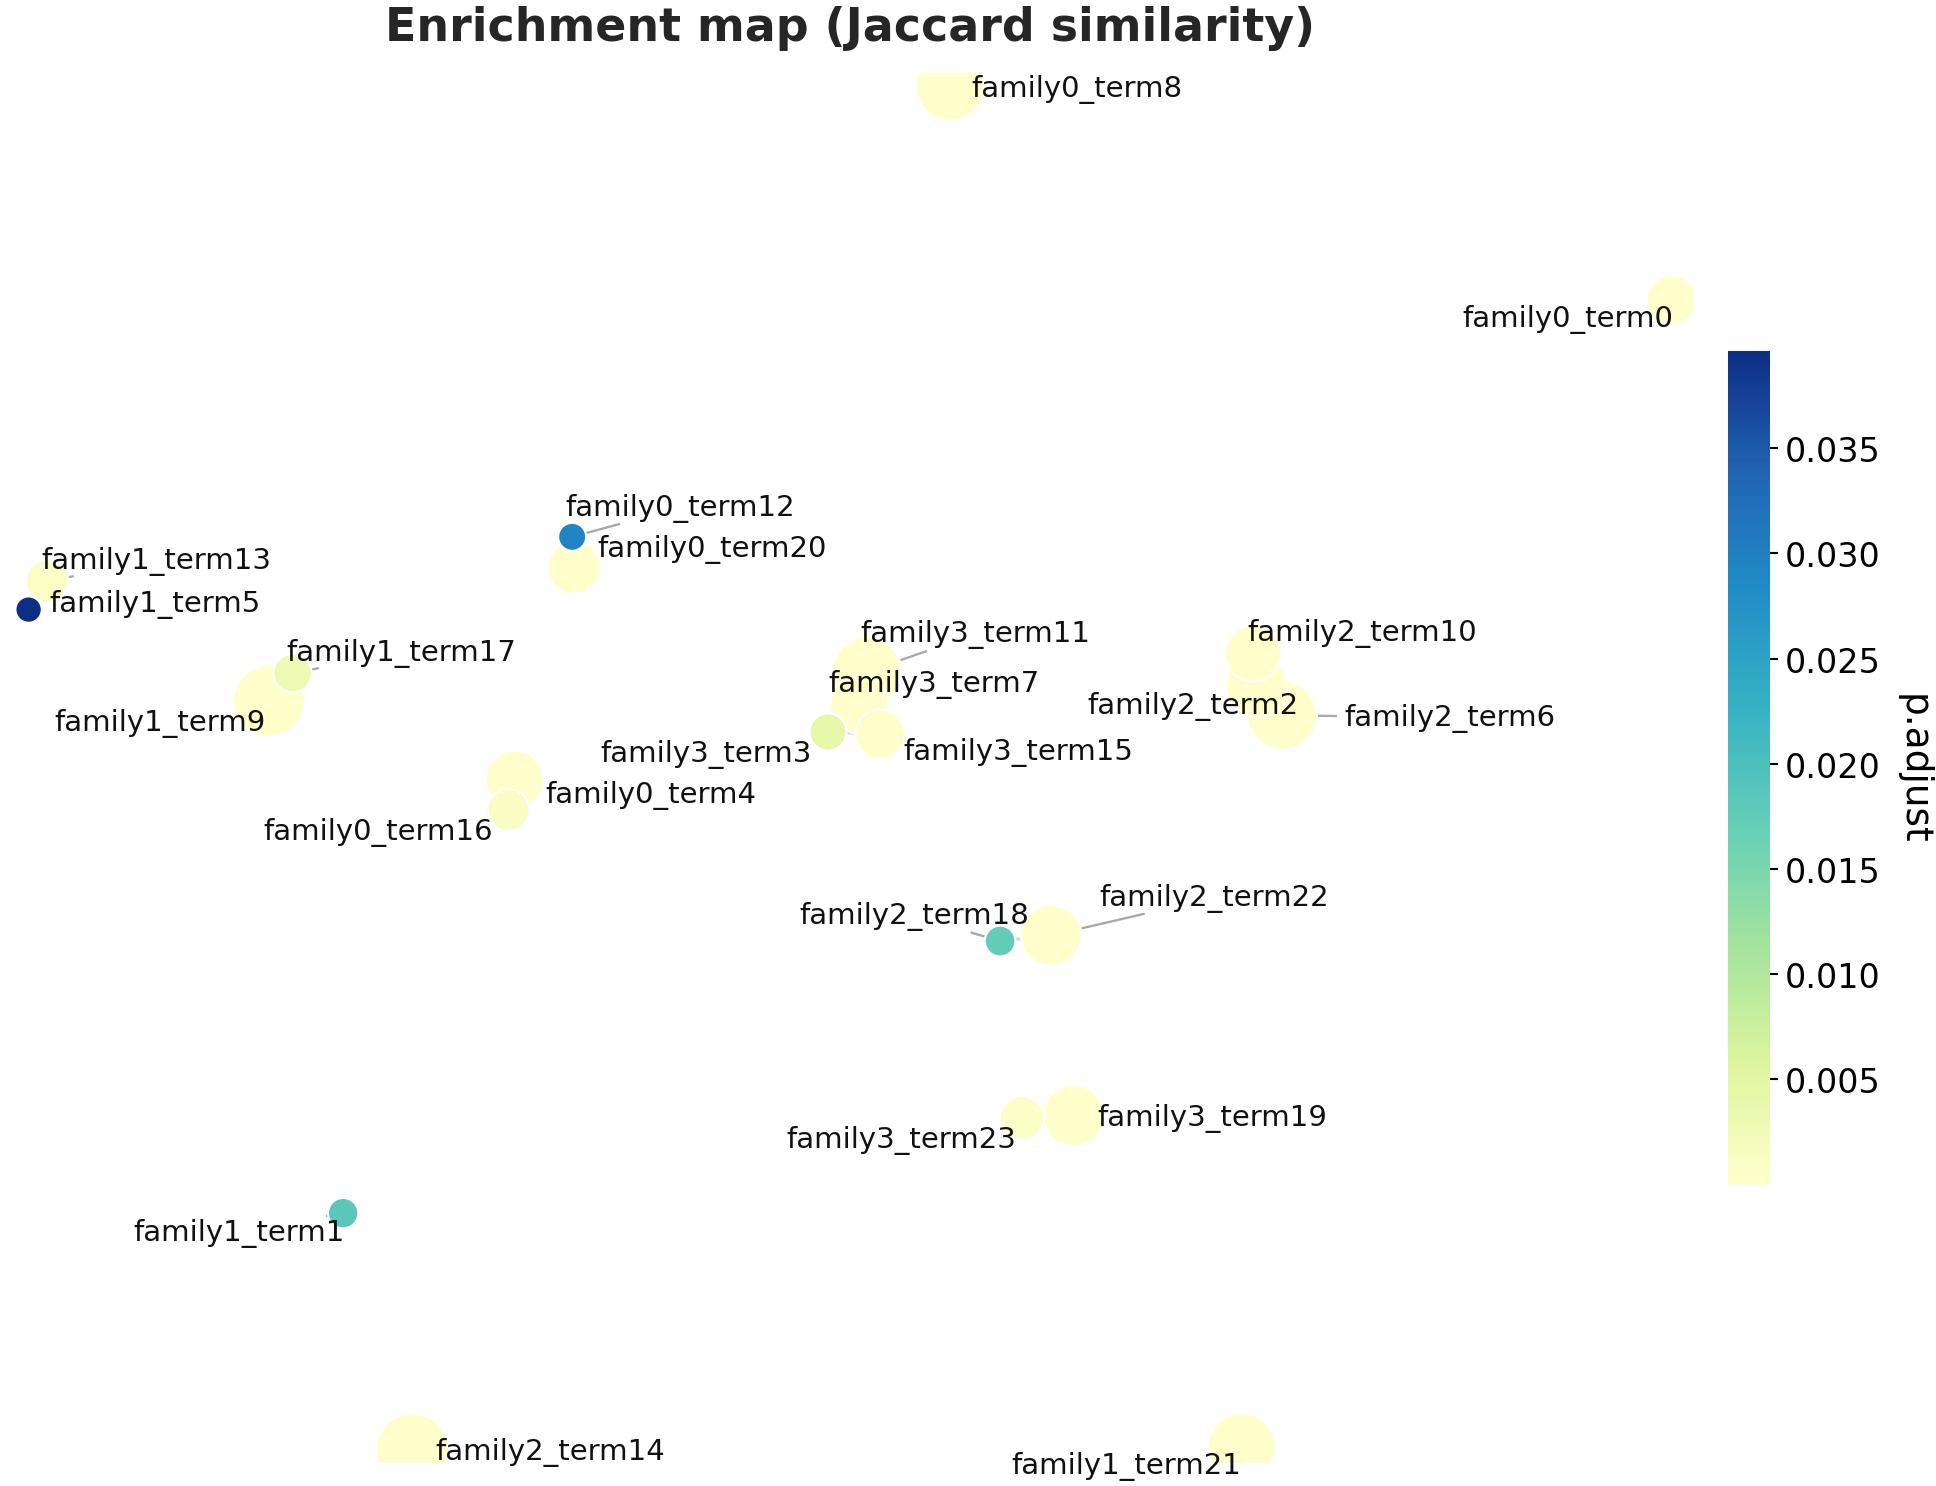

In [32]:
rng = np.random.default_rng(2)
net_terms = []
for i in range(24):
    family = i % 4  # 4 loosely related term families
    base = set(rng.choice(genes[family * 60 : (family + 1) * 60], size=12, replace=False))
    extra = set(rng.choice(genes, size=3, replace=False))
    gs = base | extra
    net_terms.append(
        {
            "Term": f"GO:{2000 + i}",
            "Description": f"family{family}_term{i}",
            "p.adjust": 10 ** (-rng.uniform(1, 8)),
            "Count": len(gs),
            "Genes": ";".join(sorted(gs)),
        }
    )
net_df = pd.DataFrame(net_terms)

scat.pl.enrich_network_plot(
    net_df,
    top_n=24,
    min_similarity=0.15,
    title="Enrichment map (Jaccard similarity)",
    figsize=(6.5, 5.0),
    dpi=150,
    show=True,
);

## 8. Multi-panel layout and export

Compact 2×2 with small labels; panel letters via `add_panel_label`.
Legends use `legend_position="UR"` where applicable. Style is scoped with
`style_context(palette_name=...)` so rcParams restore after the block.

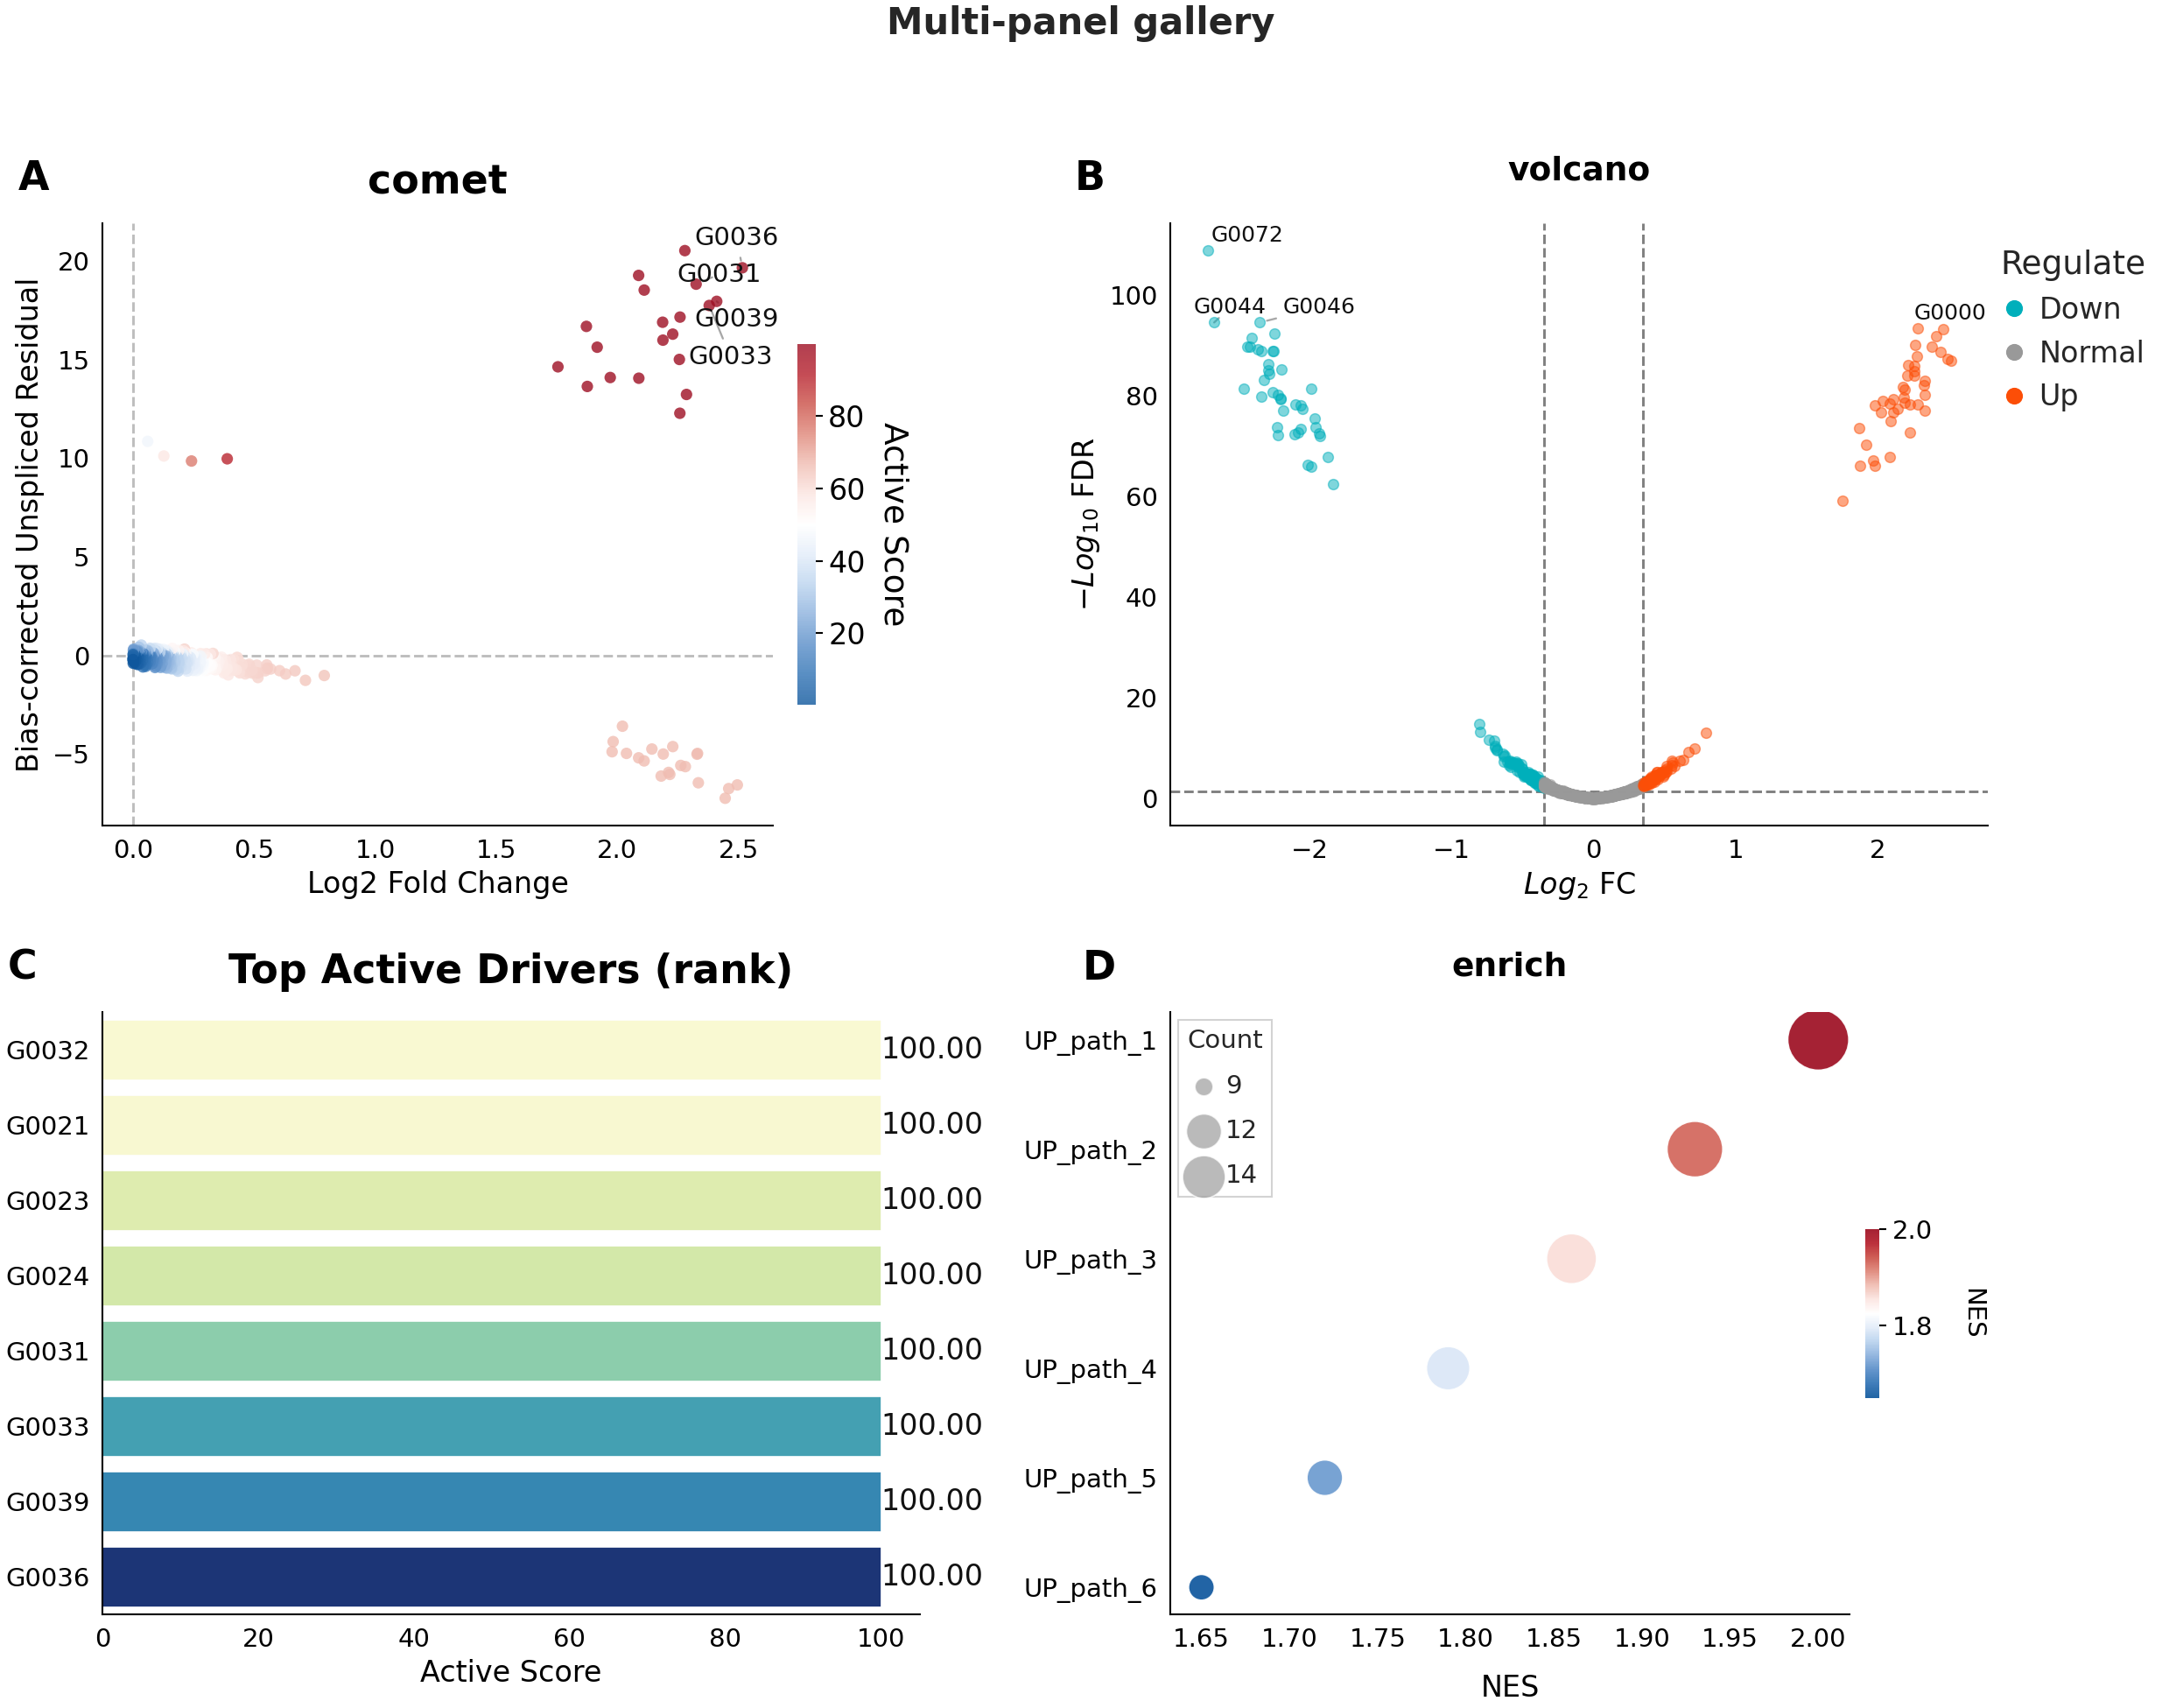

In [33]:
with scat.pl.style_context(
    palette_name="nature",
    linewidth=0.5,
    labelsize=8,
    titlesize=9,
    legendsize=7,
):
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.5), dpi=150)
    scat.pl.comet_plot(all_results, top_n=4, s=10, title="comet", ax=axes[0, 0], show=False, **FS)
    scat.pl.volcano_plot(
        all_results,
        style="ggvolcano",
        title="volcano",
        legend_position="UR",
        ax=axes[0, 1],
        show=False,
        top_n=4,
        s=8,
        alpha=0.5,
        fontsize=8,
        label_fontsize=6,
        logfc_cutoff=0.35,
        pval_cutoff=0.05,
    )
    scat.pl.active_score_rankplot(all_results, top_n=8, ax=axes[1, 0], show=False)
    scat.pl.enrich_dotplot(
        enrich_up, top_n=6, title="enrich", ax=axes[1, 1], show=False, fontsize=8
    )
    for lab, ax in zip("ABCD", axes.ravel()):
        scat.pl.add_panel_label(ax, lab, fontsize=11, x=-0.08, y=1.04)
        # Default: flush spines (no lower-left gap). Use outward=4 for floating axes.
        scat.pl.setup_ax(ax, labelsize=8, ticksize=7)
    fig.suptitle("Multi-panel gallery", y=1.02, fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

save_all_figures: ['01_comet.png', '02_volcano.png', '03_comet_paper.png']


figure_export_context wrote under /tmp/scatrans_pl_gallery_auiqffmx/one_by_one
accents: #D6372E #5189BB #00A087
default diverging cmap: scat_BuRd


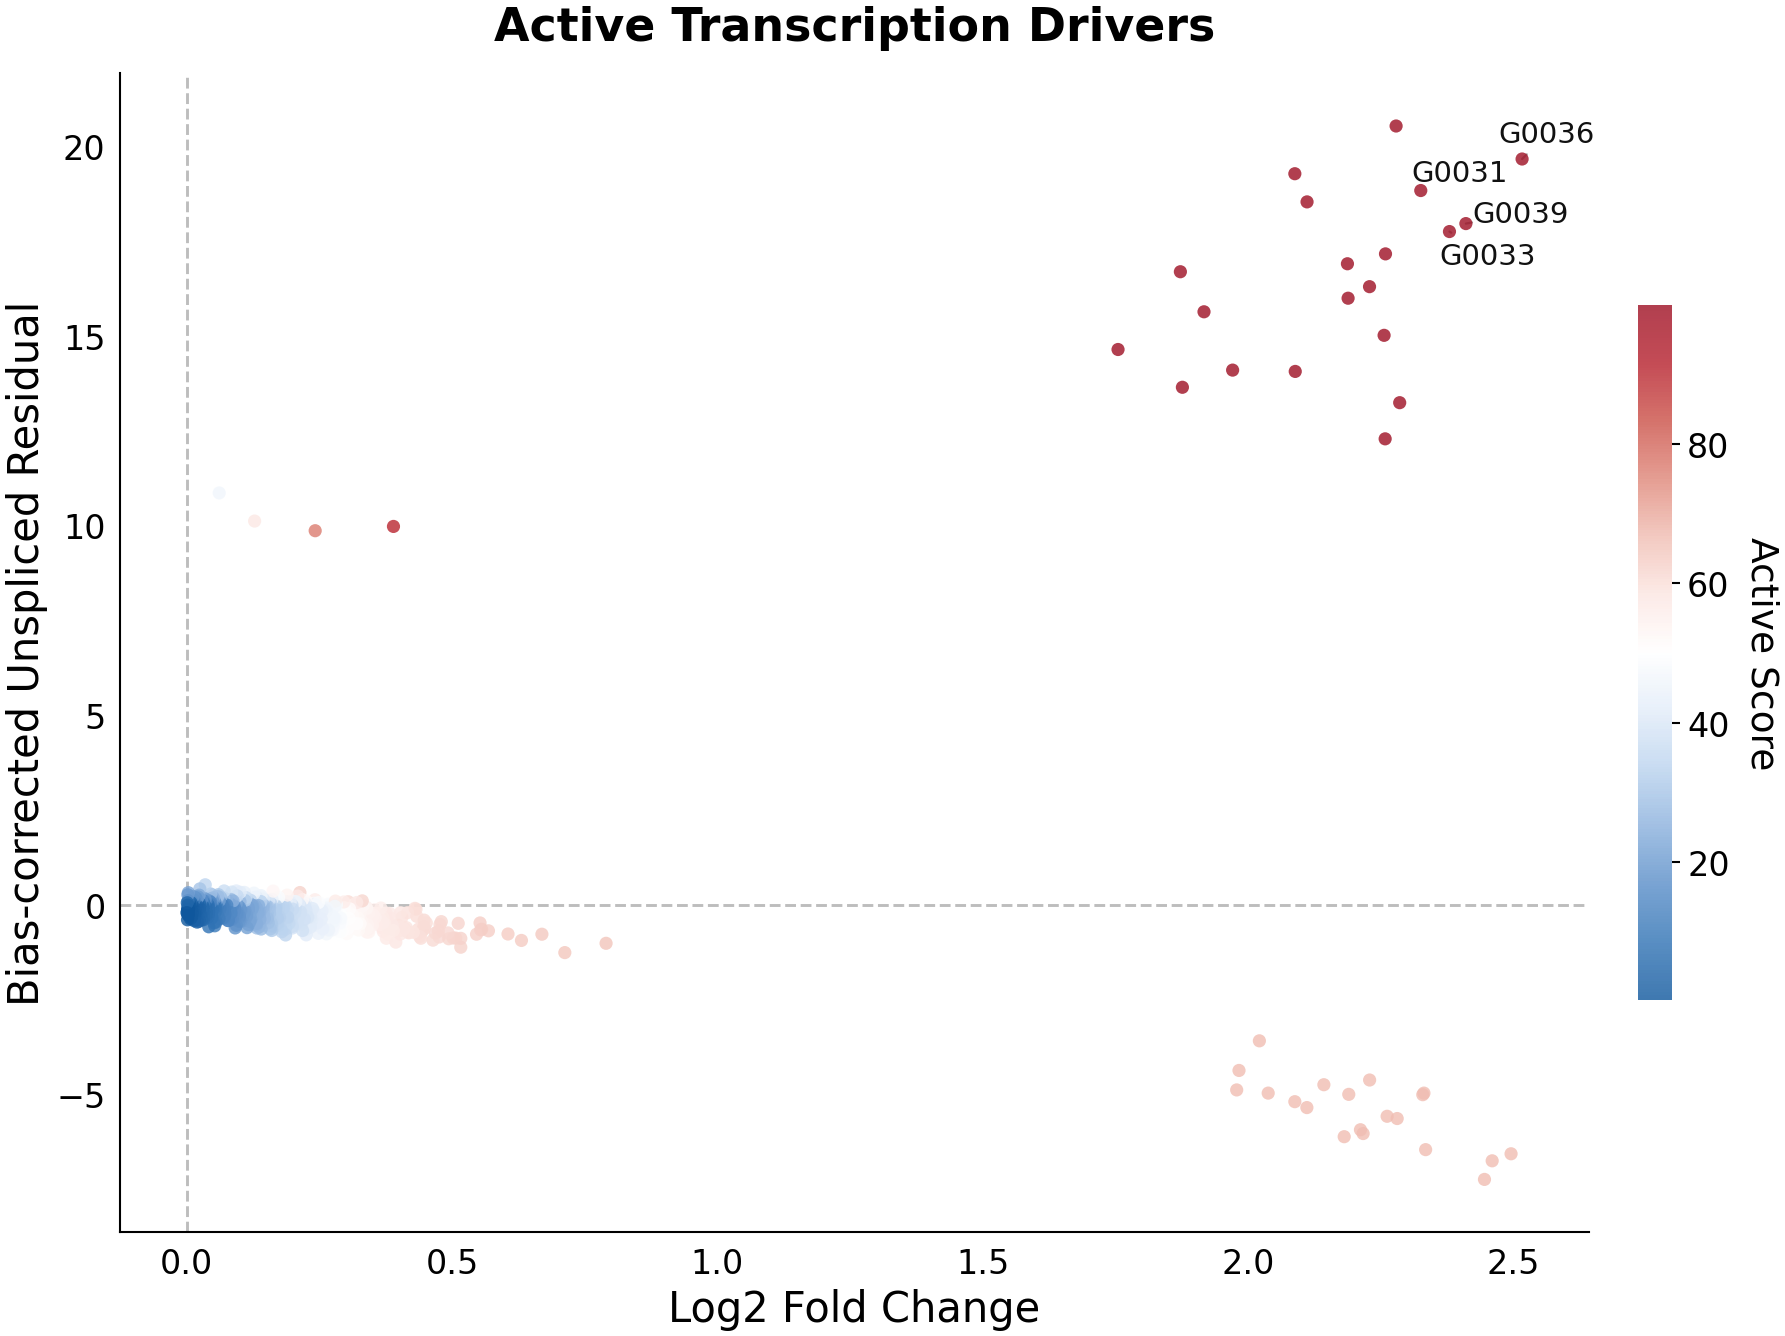

In [34]:
import tempfile
from pathlib import Path

export_dir = Path(tempfile.mkdtemp(prefix="scatrans_pl_gallery_"))
# Notebook display dpi is 150; exports use ≥300 dpi via save helpers when set.
fig1, _ = scat.pl.comet_plot(all_results, top_n=4, s=10, show=False, **FS, **FIG)
fig2, _ = scat.pl.volcano_plot(all_results, style="ggvolcano", show=False, **VOLC)
# Optional journal-sized comet (context pack)
fig3, _ = scat.pl.comet_plot(all_results, top_n=4, s=10, show=False, context="paper", **FS)
scat.pl.save_all_figures(
    {"01_comet": fig1, "02_volcano": fig2, "03_comet_paper": fig3},
    directory=str(export_dir),
    dpi=150,
    fmt="png",
    close=True,
)
print("save_all_figures:", sorted(p.name for p in export_dir.glob("*")))

# Same idea, one figure at a time:
with scat.pl.figure_export_context(str(export_dir / "one_by_one"), fmt="png", dpi=150) as export:
    fig, _ = scat.pl.comet_plot(all_results, top_n=4, s=10, show=False, **FS)
    export.save(fig, "comet")
print("figure_export_context wrote under", export_dir / "one_by_one")
print("accents:", scat.pl.RED, scat.pl.BLUE, scat.pl.TEAL)
print("default diverging cmap:", scat.pl.get_cmap().name)

## 9. Quick map

| Question | Function | Input |
|----------|----------|--------|
| DE × residual drivers | `comet_plot` | full `all_results` |
| Two-sided volcano | `volcano_plot(style="ggvolcano")` | full `all_results` |
| Top scores | `active_score_rankplot` | `all_results` |
| Bias / γ QC | `bias_diagnostic_plot`, `gamma_shrinkage_plot` | `all_results` |
| U/S check | `velocity_phase_portraits` | `adata` + genes |
| ORA dots/bars | `enrich_dotplot`, `enrich_barplot` | enrich table |
| **Multi-list overlap** | `enrich_upsetplot`, `enrich_vennplot` | table with `Cluster` |
| Gene overlap | `gene_upsetplot` / `build_gene_membership` | DE tables or membership |
| GSEA curve | `gseaplot` | ranks + `run_gsea` |
| **DE across groups** | `compare_de_across_groups` + `pl.de_summary_barplot` | `adata` + `split_by=` |
| **Score by group + significance** | `pl.group_stat_plot` | table with a value + groupby column |
| **Category composition** | `pl.composition_barplot` | table with groupby + hue columns |
| **Enrichment map (network)** | `pl.enrich_network_plot` | enrich table |
| **Vector-friendly export toggle** | `pl.set_vector_friendly` / `vector_friendly_context` | — |
| Journal style | `set_style` / `style_context` / `palette` | — |
| Faceted ORA | `enrich_dotplot(..., facet_by_cluster=True)` | compare table |
| Export one-by-one | `figure_export_context` | directory |
| Color sets / cmaps | `palette`, `get_cmap`, `RED`/`BLUE`/`TEAL` | hex list or cmap name |
| Recolor a plot | `cmap=`, `fills=`/`colors=`, UpSet `set_color` | any `scat.pl.*` |
| Axis polish / panel letters | `setup_ax` / `add_panel_label` | matplotlib axes |
| Floating spines (optional) | `setup_ax(ax, outward=4)` | after any plot |

Default spines are **flush** (no lower-left gap). Pass `outward=` only when you want floating axes.

**Next:** {doc}`../user_guide/plotting` · {doc}`t_ec_active_transcription` ·
{doc}`t_gse96583_standalone_de_enrichment` · {doc}`../statistical_guidance`